# Unified CKII Place-Cell Pipeline

Single entrypoint notebook to:
1. Validate/rebuild per-animal cached analysis artifacts.
2. Run pooled CKII figures with unchanged style (using `PooledFigure_CKII_Stats_V2.ipynb` execution).

# Unified CKII Pipeline - Refined Manual Spike Data

This copy builds caches from `manual_spike_detection_results.pkl`. Before cache building, it hydrates the manual sidecars with `refined_analysis_data` using `merged_aligned_data.pkl` as a one-time export source. After hydration, the refined analysis cache loads only the manual sidecar.


In [31]:
%load_ext autoreload
%autoreload 2


force_recompute = True  # Set to True to force recomputation of all results, even if cached results are available
cache_source_filename = 'manual_spike_detection_results.pkl'  # Refined analysis source: self-contained manual sidecar

import os
import sys
import json
from pathlib import Path

current_dir = Path(os.getcwd()).resolve()
parent_dir = current_dir.parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "ytick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

from utils.placecell_pipeline import (
    AnalysisParams,
    PlaceCellParams,
    PFTraversalParams,
    PFDistanceCenteredParams,
    PooledParams,
    CachePolicy,
    PipelineConfig,
    ensure_cache_for_all_animals,
    summarize_statuses,
    summarize_snr_removed_frames,
    summarize_snr_effective_max_time,
    plot_missing_frame_seconds_by_animal,
    summarize_first_last_minute_snr_change,
    plot_animal_movement_summary_boxplots,
    plot_animal_movement_first_last_window_comparison,
    plot_state_dependent_firing_rates_with_plateau_count,
    generate_trial_by_trial_plc_plots,
    generate_distance_defined_trial_by_trial_plc_plots,
    generate_distance_defined_trials_and_dataset,
    generate_time_defined_trials_and_dataset,
    build_pf_centered_component_dataset,
    build_pf_distance_centered_component_dataset,
    generate_pf_centered_component_heatmaps,
    generate_pf_distance_centered_component_heatmaps,
    generate_pf_distance_centered_component_heatmaps_2sessions,
    generate_pf_distance_centered_component_heatmaps_2directions,
    generate_pf_time_centered_component_heatmaps,
    generate_pf_time_centered_component_heatmaps_2sessions,
    generate_pf_time_centered_component_heatmaps_2directions,
    plot_pf_centered_category_primary_secondary_from_dataset,
    plot_pf_distance_centered_category_primary_secondary_from_dataset,
    plot_pf_distance_centered_category_primary_secondary_from_dataset_2sessions,
    plot_pf_distance_centered_category_primary_secondary_from_dataset_2directions,
    plot_pf_time_centered_category_primary_secondary_from_dataset,
    plot_pf_time_centered_category_primary_secondary_from_dataset_2sessions,
    plot_pf_time_centered_category_primary_secondary_from_dataset_2directions,
    compute_pf_distance_centered_pref_nonpref_stats,
    plot_pf_distance_centered_pref_nonpref_stats,
    plot_pf_distance_centered_pf1_pf2_fwhm_all_spikes_slow_vm,
    compute_pf_centered_selectivity_summary,
    plot_pf_centered_selectivity_summary,
    compute_csplus_two_pf_session_delta,
    plot_csplus_two_pf_session_delta,
    compute_csplus_vs_csminus_primary_pf_session_delta,
    plot_csplus_vs_csminus_primary_pf_session_delta,
    compute_pf_distance_centered_session_stability,
    plot_pf_distance_centered_session_stability,
    compute_pf_time_centered_session_stability,
    plot_pf_time_centered_session_stability,
    compute_pf_time_centered_pref_nonpref_stats,
    plot_pf_time_centered_pref_nonpref_stats,
    GLMParams,
    run_pooled_placecell_glm_analysis,
    LNModelParams,
    run_pooled_placecell_ln_model_analysis,
    generate_bin_by_bin_directionality_plots,
    EgocentricTuningParams,
    EgocentricSummaryPlotParams,
    run_pooled_egocentric_tuning_analysis,
    generate_egocentric_valid_spatial_bin_diagnostic_plots,
    generate_egocentric_per_cell_summary_plots,
)

from utils.spatial_heatmaps import (
    classify_spatial_cells,
    compute_global_theta_slow_vlims,
    plot_celltype_distribution_pie,
    plot_complex_burst_event_heatmaps,
    plot_multiple_pf_percentage_by_group,
    plot_selected_cells_figure,
    plot_selected_cells_transposed_figure,
    render_spatial_heatmap_chunks,
)

from utils.pooled_figures_core import (
    prepare_pooled_stats_tables,
    plot_moving_epoch_cs_cb_metrics_allcells_placecells,
    plot_combined_cs_plus_minus_4panels,
    plot_combined_cs_plus_minus_4panels_2sessions,
    plot_combined_cs_plus_minus_session_pair_metrics_14cols,
    plot_all_cells_session_state_rate_comparison_4cols,
    plot_cs_plus_plc_correlations_overlay_cs_ss,
    plot_in_pf_fr_vs_all_pf_size_by_cs_group,
    plot_map_pair_similarity_by_cell_type,
    plot_complex_burst_metrics_allbursts_csplus,
    plot_complex_burst_metric_distributions_csplus,
    plot_complex_burst_metric_distributions_quiet_vs_moving_allcells,
    plot_complex_burst_metrics_csplus,
    plot_cbrate_correlations_csplus_inout_alt,
    plot_theta_inout_loco_csplus_vs_csminus,
    plot_slow_vm_inout_loco_csplus_vs_csminus,
)

from utils.session_compare_heatmaps import (
    SessionCompareParams,
    build_session_compare_payloads,
    assemble_session_compare_groups,
    build_session_compare_analysis,
    build_session_split_4panel_tables,
    summarize_session_split_plc_classification,
    render_session_compare_heatmaps,
    plot_session_compare_correlation_stats,
    plot_session_compare_complex_burst_metrics,
    run_session_compare_heatmaps,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameter Blocks

In [32]:
# Ensure latest pipeline dataclasses are bound in this kernel
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)
AnalysisParams = _pcp.AnalysisParams
PlaceCellParams = _pcp.PlaceCellParams
PFTraversalParams = _pcp.PFTraversalParams
PFDistanceCenteredParams = _pcp.PFDistanceCenteredParams
PooledParams = _pcp.PooledParams
CachePolicy = _pcp.CachePolicy
PipelineConfig = _pcp.PipelineConfig
summarize_first_last_minute_snr_change = _pcp.summarize_first_last_minute_snr_change
plot_missing_frame_seconds_by_animal = _pcp.plot_missing_frame_seconds_by_animal
plot_pf_distance_centered_pf1_pf2_fwhm_all_spikes_slow_vm = _pcp.plot_pf_distance_centered_pf1_pf2_fwhm_all_spikes_slow_vm
print(f"Using placecell_pipeline: {_pcp.__file__}")

import utils.session_compare_heatmaps as _sch
importlib.reload(_sch)
SessionCompareParams = _sch.SessionCompareParams
build_session_compare_payloads = _sch.build_session_compare_payloads
assemble_session_compare_groups = _sch.assemble_session_compare_groups
build_session_compare_analysis = _sch.build_session_compare_analysis
build_session_split_4panel_tables = _sch.build_session_split_4panel_tables
summarize_session_split_plc_classification = _sch.summarize_session_split_plc_classification
render_session_compare_heatmaps = _sch.render_session_compare_heatmaps
plot_session_compare_correlation_stats = _sch.plot_session_compare_correlation_stats
plot_session_compare_complex_burst_metrics = _sch.plot_session_compare_complex_burst_metrics
run_session_compare_heatmaps = _sch.run_session_compare_heatmaps
print(f"Using session_compare_heatmaps: {_sch.__file__}")

import utils.pooled_figures_core as _pfc
importlib.reload(_pfc)
plot_combined_cs_plus_minus_session_pair_metrics_14cols = _pfc.plot_combined_cs_plus_minus_session_pair_metrics_14cols
plot_all_cells_session_state_rate_comparison_4cols = _pfc.plot_all_cells_session_state_rate_comparison_4cols
plot_map_pair_similarity_by_cell_type = _pfc.plot_map_pair_similarity_by_cell_type
plot_in_pf_fr_vs_all_pf_size_by_cs_group = _pfc.plot_in_pf_fr_vs_all_pf_size_by_cs_group
print(f"Using pooled_figures_core: {_pfc.__file__}")

import utils.spatial_heatmaps as _sh
importlib.reload(_sh)
plot_multiple_pf_percentage_by_group = _sh.plot_multiple_pf_percentage_by_group
print(f"Using spatial_heatmaps: {_sh.__file__}")

# Block 1: Dataset and paths
project_root = parent_dir

data_root = project_root / 'data'
figures_root = project_root / 'figures'
notebooks_root = project_root / 'notebooks_PCs_refined'

animals = [
    'CKII_pAce21_PR_20250806',
    'CKII_pAce38_PX_20251126',
    'CKII_pAce45_PX_20260118',
    'CKII_pAce47_PX_20260128',
    'CKII_pAce46_PR_20260222',
    'CKII_pAce50_PRL_20260317',
    'CKII_pAce54_PR_20260506',
    'CKII_pAce54_PX_20260514'
]

# Block 2: Core analysis parameters
analysis_params = AnalysisParams(
    speed_threshold=2.5,
    speed_threshold_quiet=0.5,
    behavior_speed_outlier_threshold_cm_s=100.0,
    behavior_speed_outlier_cleaning=True,
    min_duration_s=0.2, # minimum duration of a moving epoch (in seconds), default 0.25s
    merge_gap_s=0.0, 
    kernel_size=51,
    snr_threshold=5,
    min_good_minutes=5.0, # only include cells with 
    theta_freqs=(4.0, 10.0),
    slow_freqs=2.0,
    refined_apply_cb_baseline_removal=True,  # Applies the analysis Vm/theta/slow-Vm CB baseline window below.
    refined_cb_baseline_window_s=5.0,  # Analysis Vm/theta/slow-Vm baseline window when refined_apply_cb_baseline_removal=True.
    refined_snr_cb_baseline_window_s=1.0,  # SNR-only CB baseline window for step4-style SNR interpolation.
)

# Block 3: Place cell + traversal parameters
place_cell_params = PlaceCellParams(
    bin_size=1.5, # default 1.5 cm
    place_field_threshold=0.25, # Threshold for place field detection relative to maximum peak rate, default 0.4
    min_component_peak_ratio=0.3, # each PF component peak must be at least this fraction of the map max peak
    split_multi_peak_fields=False, # enable peak-based PF splitting using the criteria below
    split_secondary_peak_ratio=0.6, # split a PF if a secondary local peak is at least this fraction of the primary peak
    split_secondary_peak_min_separation_cm=6.0, # split only if primary and secondary peaks are at least this far apart
    min_peak_rate=0.8, # Minimum peak firing rate (in Hz) for a valid place field, default 0.4
    max_field_area_ratio=0.66, 
    min_field_bins=10, # Minimum number of contiguous bins for a valid place field, default 10
    min_pf_firing_traversals=4, # Minimum number of traversals with spike firing in the PF, default 5
    pf_firing_traversal_distance_window_cm=15.0,
    pf_firing_traversal_detection_window_cm=8.0,
    pf_firing_traversal_distance_bin_cm=1.5,
    pf_firing_traversal_distance_mode='euclidean_to_peak',
    pf_firing_traversal_center_vicinity_min_cm=1,
    pf_firing_traversal_center_vicinity_max_cm=5,
    pf_firing_traversal_resting_speed_threshold=0.5,
    pf_firing_traversal_merge_gap_s=2.0,
    pf_firing_traversal_exclude_trials_with_bad_frames=True,
    pf_reliability_dilation_bins=3, # Dilation size in bins for firing-traversal calculation, default 3 (to prevent small PF being rejected)
    pf_reliability_dilation_shape='disk',
    smooth_sigma=1.5, # for smoothing spatial firing rate maps (in bins), default 2.0
    min_occupancy_s=0.1,
    occ_smooth_sigma=1.5, # for smoothing occupancy maps (in bins), default 2.0
    num_shuffles=1000,
    random_seed=42,
    ss_shape_min_separation_ms=14.0,
    trim_sparse_top_row_for_analysis=True, 
    trim_sparse_top_row_for_plotting=True,
    sparse_top_row_nonocc_frac_threshold=0.8,
)

traversal_params = PFTraversalParams(
    center_by_pf_position=True,
    pf_component_selection='peak_rate',
    min_duration_ms=100.0,
    min_distance_cm=5.0,
    traversal_merge_gap_s=2.0, # merge nearby PF traversals separated by brief rest
    clear_traversal=False,
    session_indices=(0, 1),
    pf_center_window_sec=10.0, # seconds before and after PF entry and exit to include in PF-centered traversal analysis
    min_traversals=10,
    firing_rate_bin_ms=100.0,
    firing_rate_smooth_ms=50.0,
    subtract_pre_traversal_baseline=False, # subtract pre-traversal baseline from theta amp and slow Vm
    mask_non_traversal_pf=True, 
    max_pf_distance_cm=8.0, # maximum allowed distance between a traversal and the PF peak
    plateau_min_duration_ms=100.0,
)

# Block 4: Pooled classification + PSD parameters
pooled_params = PooledParams(
    cb_num_threshold=5, # legacy CS+ criterion: minimum number of complex bursts in PF
    cs_peak_rate_threshold=0.5, # legacy CS+ criterion: CS spatial-map peak firing rate threshold (Hz)
    cs_plc_definition_mode='cs_place_field', # {'legacy', 'cs_place_field'}; CS+ requires a CS-only place field
    run_psd_sections=True,
    cs_plc_only=True,
    psd_speed_threshold=3,
    psd_chunk_s=2.0,
    psd_nperseg_s=1.0,
    psd_noverlap_frac=0.5,
    simple_event_window_ms=80.0,
    simple_event_min_gap_ms=50.0,
    min_chunk_valid_fraction=1.0,
    max_freq=100.0,
    normalize_psd=True,
    norm_freq_range=(20.0, 100.0),
)

# Block 5: Figure style
# (Style remains the same because pooled figure generation executes
#  PooledFigure_CKII_Stats_V2.ipynb with patched parameters only.)

# Block 6: Cache policy controls
cache_policy = CachePolicy(
    force_recompute=force_recompute,
    validate_only=False,
    save_executed_notebooks=False,
)

config = PipelineConfig(
    project_root=project_root,
    data_root=data_root,
    figures_root=figures_root,
    notebooks_root=notebooks_root,
    animals=animals,
    merged_data_filename=cache_source_filename,
    analysis=analysis_params,
    place_cell=place_cell_params,
    traversal=traversal_params,
    pooled=pooled_params,
    cache=cache_policy,
)

print('Pipeline Config:')
print(json.dumps({
    'project_root': str(config.project_root),
    'data_root': str(config.data_root),
    'figures_root': str(config.figures_root),
    'notebooks_root': str(config.notebooks_root),
    'animals': config.animals,
    'merged_data_filename': config.merged_data_filename,
    'analysis': config.analysis.__dict__,
    'place_cell': config.place_cell.__dict__,
    'traversal': config.traversal.__dict__,
    'pooled': config.pooled.__dict__,
    'cache': config.cache.__dict__,
}, indent=2))


Using placecell_pipeline: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py
Defined plot_selected_cells_figure() function for session comparison
Using session_compare_heatmaps: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/session_compare_heatmaps.py
Using pooled_figures_core: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/pooled_figures_core.py
Using spatial_heatmaps: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/spatial_heatmaps.py
Pipeline Config:
{
  "project_root": "/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4",
  "data_root": "/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data",
  "figures_root": "/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures",
  "n

In [3]:
# Hydrate manual sidecars with self-contained refined analysis data
# This one-time export may read merged_aligned_data.pkl; cache building below reads only manual_spike_detection_results.pkl.
if config.merged_data_filename == 'manual_spike_detection_results.pkl':
    hydration_statuses = _pcp.hydrate_manual_spike_sidecars_for_animals(
        config,
        animals=config.animals,
        merged_data_filename='merged_aligned_data_new.pkl',
        sidecar_filename='manual_spike_detection_results.pkl',
        apply_cb_baseline_removal=config.analysis.refined_apply_cb_baseline_removal,
        cb_baseline_window_s=config.analysis.refined_cb_baseline_window_s,
        snr_cb_baseline_window_s=config.analysis.refined_snr_cb_baseline_window_s,
        force=config.cache.force_recompute,
    )
    for hs in hydration_statuses:
        print(f"[{hs['action']}] {hs['animal_id']}: cells={hs['n_cells']}, frames={hs['n_frames']}")
else:
    print('Hydration skipped: cache source is not manual_spike_detection_results.pkl.')


[hydrated] CKII_pAce21_PR_20250806: cells=9, frames=299500
[hydrated] CKII_pAce38_PX_20251126: cells=9, frames=597670
[hydrated] CKII_pAce45_PX_20260118: cells=16, frames=598609
[hydrated] CKII_pAce47_PX_20260128: cells=5, frames=598461
[hydrated] CKII_pAce46_PR_20260222: cells=9, frames=598579
[hydrated] CKII_pAce50_PRL_20260317: cells=9, frames=599087
[hydrated] CKII_pAce54_PR_20260506: cells=16, frames=599137
[hydrated] CKII_pAce54_PX_20260514: cells=16, frames=599130


In [4]:
# Ensure/rebuild per-animal cache artifacts
print(f"Cache source file: {config.merged_data_filename}")
statuses = ensure_cache_for_all_animals(config, force=config.cache.force_recompute)

for st in statuses:
    print(f"[{st.action}] {st.animal_id}")
    if st.reasons:
        print(f"  reasons: {st.reasons}")
    if st.missing_artifacts:
        print(f"  missing: {st.missing_artifacts}")

print('Summary:', summarize_statuses(statuses))


Cache source file: manual_spike_detection_results.pkl
CKII_pAce21_PR_20250806: purged 11 cached artifact files (force_recompute=True).
CKII_pAce21_PR_20250806: behavior speed outlier cleaning threshold=100.0 cm/s, frames=0/299500 (0.000%), max_raw_speed=53.21 cm/s
CKII_pAce21_PR_20250806: SNR filter kept 7/9 cells (threshold=5, min_good_minutes=5.0).
Found 19 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 59 bins, peak rate: 9.56 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7338: RuntimeWarning: invalid value encountered in divide
  ss_pct_trial[write_start:write_end] = np.where(valid_denom, 100.0 * ss_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7339: RuntimeWarning: invalid value encountered in divide
  cs_pct_trial[write_start:write_end] = np.where(valid_denom, 100.0 * cs_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7421: RuntimeWarning: Mean of empty slice
  'ss_pct_mean': np.nanmean(ss_pct_arr, axis=0) if ss_pct_arr.size > 0 else np.full(avg_len, np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7422: RuntimeWarning: Mean of empty slice
  'cs_pct_mean': np.nanmean(cs_pct_arr, axis=0) if

Found 31 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 96 bins, peak rate: 4.22 Hz
Found 27 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 83 bins, peak rate: 6.70 Hz
Found 8 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 78 bins, peak rate: 1.34 Hz
CKII_pAce38_PX_20251126: purged 11 cached artifact files (force_recompute=True).
CKII_pAce38_PX_20251126: behavior speed outlier cleaning threshold=100.0 cm/s, frames=0/597670 (0.000%), max_raw_speed=40.97 cm/s
CKII_pAce38_PX_20251126: SNR filter kept 7/9 cells (threshold=5, min_good_minutes=5.0).
Found 34 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 35 bins, peak rate: 8.97 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7338: RuntimeWarning: invalid value encountered in divide
  ss_pct_trial[write_start:write_end] = np.where(valid_denom, 100.0 * ss_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7339: RuntimeWarning: invalid value encountered in divide
  cs_pct_trial[write_start:write_end] = np.where(valid_denom, 100.0 * cs_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7421: RuntimeWarning: Mean of empty slice
  'ss_pct_mean': np.nanmean(ss_pct_arr, axis=0) if ss_pct_arr.size > 0 else np.full(avg_len, np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7422: RuntimeWarning: Mean of empty slice
  'cs_pct_mean': np.nanmean(cs_pct_arr, axis=0) if

Found 63 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 71 bins, peak rate: 2.36 Hz
Found 52 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 95 bins, peak rate: 8.14 Hz
Found 50 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 58 bins, peak rate: 9.21 Hz
CKII_pAce45_PX_20260118: purged 11 cached artifact files (force_recompute=True).
CKII_pAce45_PX_20260118: behavior speed outlier cleaning threshold=100.0 cm/s, frames=0/598609 (0.000%), max_raw_speed=95.28 cm/s
CKII_pAce45_PX_20260118: SNR filter kept 9/16 cells (threshold=5, min_good_minutes=5.0).
Found 78 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 76 bins, peak rate: 9.77 Hz


...

Found 8 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 13 bins, peak rate: 5.42 Hz
Found 42 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 106 bins, peak rate: 7.69 Hz
Found 22 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 57 bins, peak rate: 7.15 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7416: RuntimeWarning: Mean of empty slice
  'theta_mean': np.nanmean(theta_arr, axis=0) if theta_arr.size > 0 else np.full(avg_len, np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7417: RuntimeWarning: Mean of empty slice
  'slow_mean': np.nanmean(slow_arr, axis=0) if slow_arr.size > 0 else np.full(avg_len, np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7418: RuntimeWarning: Mean of empty slice
  'rate_mean': np.nanmean(rate_arr, axis=0) if rate_arr.size > 0 else np.full(avg_len, np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7419: RuntimeWarning: Mean of empty slice
  'ss_rate_mean': np.nanmean(ss_rate_arr, axis=0) if ss_rate_arr.size > 0 else np

Found 47 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 102 bins, peak rate: 1.07 Hz
CKII_pAce54_PX_20260514: purged 11 cached artifact files (force_recompute=True).
CKII_pAce54_PX_20260514: behavior speed outlier cleaning threshold=100.0 cm/s, frames=0/599130 (0.000%), max_raw_speed=44.83 cm/s
CKII_pAce54_PX_20260514: SNR filter kept 6/16 cells (threshold=5, min_good_minutes=5.0).
Found 44 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 176 bins, peak rate: 6.24 Hz
Found 87 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 106 bins, peak rate: 8.95 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7338: RuntimeWarning: invalid value encountered in divide
  ss_pct_trial[write_start:write_end] = np.where(valid_denom, 100.0 * ss_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7339: RuntimeWarning: invalid value encountered in divide
  cs_pct_trial[write_start:write_end] = np.where(valid_denom, 100.0 * cs_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7421: RuntimeWarning: Mean of empty slice
  'ss_pct_mean': np.nanmean(ss_pct_arr, axis=0) if ss_pct_arr.size > 0 else np.full(avg_len, np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:7422: RuntimeWarning: Mean of empty slice
  'cs_pct_mean': np.nanmean(cs_pct_arr, axis=0) if

[recomputed] CKII_pAce21_PR_20250806
  reasons: ['missing_artifacts', 'fingerprint_mismatch', 'force_recompute']
  missing: ['animal_movement_summary', 'burst_metrics_pf', 'pf_centered_trial_data', 'pooled_stats', 'psd_burst_type_state', 'spatial_analysis', 'spike_burst_rates_pf', 'spike_shapes_pf', 'theta_amp_state']
[recomputed] CKII_pAce38_PX_20251126
  reasons: ['missing_artifacts', 'fingerprint_mismatch', 'force_recompute']
  missing: ['animal_movement_summary', 'burst_metrics_pf', 'pf_centered_trial_data', 'pooled_stats', 'psd_burst_type_state', 'spatial_analysis', 'spike_burst_rates_pf', 'spike_shapes_pf', 'theta_amp_state']
[recomputed] CKII_pAce45_PX_20260118
  reasons: ['missing_artifacts', 'fingerprint_mismatch', 'force_recompute']
  missing: ['animal_movement_summary', 'burst_metrics_pf', 'pf_centered_trial_data', 'pooled_stats', 'psd_burst_type_state', 'spatial_analysis', 'spike_burst_rates_pf', 'spike_shapes_pf', 'theta_amp_state']
[recomputed] CKII_pAce47_PX_20260128
  r

## Pooled Figures (Run Individually)

### SNR Frame-Removal Distribution

SNR removed-frame summary (all cells): n_cells=89, removed(<5.0 min good)=24, mean_total=42.15%, median_total=28.67%, source_bad=1.73%, snr_only=40.71%
SNR removed-frame figure saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SNR_RemovedFrameDistribution_all_cells.svg


,scope,n_cells,n_kept_cells,n_removed_min_good_minutes,n_frames_total_cellwise,n_removed_frames_total,n_removed_frames_snr_only,n_removed_frames_snr_threshold_only,n_removed_frames_manual_snr_cutoff,n_removed_frames_source_trace_bad,...,mean_pct_removed_source_trace_bad,median_pct_removed_source_trace_bad,std_pct_removed_source_trace_bad,min_pct_removed_source_trace_bad,max_pct_removed_source_trace_bad,mean_pct_removed_pos_nan,median_pct_removed_pos_nan,std_pct_removed_pos_nan,min_pct_removed_pos_nan,max_pct_removed_pos_nan
0,all_cells_including_removed,89,65,24,50595845,21643225,20598337,9907645,10155862,876003,...,1.899587,1.031777,2.901103,0.165309,12.448764,0.328417,0.028232,0.650003,0.0,1.714319


,animal_id,n_cells,n_kept_cells,n_removed_min_good_minutes,n_frames_total_cellwise,n_removed_frames_total,n_removed_frames_snr_only,n_removed_frames_snr_threshold_only,n_removed_frames_manual_snr_cutoff,n_removed_frames_source_trace_bad,...,mean_pct_removed_source_trace_bad,median_pct_removed_source_trace_bad,std_pct_removed_source_trace_bad,min_pct_removed_source_trace_bad,max_pct_removed_source_trace_bad,mean_pct_removed_pos_nan,median_pct_removed_pos_nan,std_pct_removed_pos_nan,min_pct_removed_pos_nan,max_pct_removed_pos_nan
0,CKII_pAce21_PR_20250806,9.0,7.0,2.0,2695500.0,820073.0,683143.0,683143.0,0.0,136325.0,...,5.057503,5.366945,1.148110,3.314524,6.886811,0.040401,0.040401,0.0,0.040401,0.040401
1,CKII_pAce38_PX_20251126,9.0,7.0,2.0,5379030.0,1660265.0,1650707.0,1204030.0,406832.0,9558.0,...,0.177690,0.165309,0.026964,0.165309,0.250305,0.000000,0.000000,0.0,0.000000,0.000000
2,CKII_pAce45_PX_20260118,16.0,9.0,7.0,9577744.0,5116502.0,5084401.0,4717646.0,318488.0,29397.0,...,0.306930,0.299027,0.016569,0.299027,0.345969,0.028232,0.028232,0.0,0.028232,0.028232
3,CKII_pAce46_PR_20260222,9.0,7.0,2.0,5387211.0,1817059.0,1748087.0,1569716.0,108219.0,68279.0,...,1.267428,1.031777,0.581991,1.031777,2.899200,0.012864,0.012864,0.0,0.012864,0.012864
4,CKII_pAce47_PX_20260128,5.0,4.0,1.0,2992305.0,1013676.0,642603.0,421367.0,118424.0,366398.0,...,12.244674,12.172890,0.106994,12.172890,12.448764,0.173779,0.173779,0.0,0.173779,0.173779
5,CKII_pAce50_PRL_20260317,9.0,9.0,0.0,5391783.0,696079.0,679411.0,365931.0,313480.0,16668.0,...,0.309137,0.304296,0.013692,0.304296,0.347863,0.000000,0.000000,0.0,0.000000,0.000000
6,CKII_pAce54_PR_20260506,16.0,16.0,0.0,9586192.0,3104594.0,3003344.0,554038.0,2449306.0,101250.0,...,1.056207,1.032652,0.145122,0.902298,1.326575,0.000000,0.000000,0.0,0.000000,0.000000
7,CKII_pAce54_PX_20260514,16.0,6.0,10.0,9586080.0,7414977.0,7106641.0,391774.0,6441113.0,148128.0,...,1.545241,1.390516,0.341266,1.390516,2.728289,1.714319,1.714319,0.0,1.714319,1.714319


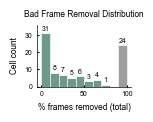

In [5]:
snr_dist_scope_place_cells_only = False

snr_dist = summarize_snr_removed_frames(
    config=config,
    by_place_cells_only=snr_dist_scope_place_cells_only,
    show_plot=True,
    bins=10,
)

snr_dist_figure_name = (
    "SNR_RemovedFrameDistribution_place_cells_only.svg"
    if snr_dist_scope_place_cells_only
    else "SNR_RemovedFrameDistribution_all_cells.svg"
)
_snr_dist_figure_folder = globals().get('figure_save_folder')
if _snr_dist_figure_folder is None:
    _snr_dist_figure_folder = Path(config.figures_root) / globals().get('FIRST10_FIGURE_FOLDER', 'CKII_pooled')
snr_dist_figure_path = Path(_snr_dist_figure_folder) / snr_dist_figure_name
snr_dist_figure = snr_dist.get("figure")
if snr_dist_figure is not None:
    snr_dist_figure_path.parent.mkdir(parents=True, exist_ok=True)
    snr_dist_figure.savefig(snr_dist_figure_path, dpi=300)
    snr_dist["figure_path"] = str(snr_dist_figure_path)
    print(f"SNR removed-frame figure saved: {snr_dist_figure_path}")
else:
    snr_dist["figure_path"] = None
    print("SNR removed-frame figure was not generated.")

display(snr_dist["overall"])
display(snr_dist["per_animal"])


SNR effective max-time summary (all cells): n_cells=89, excluded(<5.0 min good)=24, mean=11.04 min, median=12.51 min
SNR effective max-time figure saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SNR_EffectiveMaxTimeDistribution_all_cells.svg


,scope,n_cells,n_kept_cells,n_excluded_min_good_minutes,mean_effective_max_minutes,median_effective_max_minutes,min_effective_max_minutes,max_effective_max_minutes
0,all_cells_including_excluded,89,65,24,11.043989,12.507533,0.0,19.9088


,animal_id,n_cells,n_kept_cells,n_excluded_min_good_minutes,mean_effective_max_minutes,median_effective_max_minutes,min_effective_max_minutes,max_effective_max_minutes
0,CKII_pAce21_PR_20250806,9,7,2,6.946026,9.370833,0.000000,9.648400
1,CKII_pAce38_PX_20251126,9,7,2,13.920778,19.167333,0.000000,19.889400
2,CKII_pAce45_PX_20260118,16,9,7,9.394810,10.087783,0.000000,19.888333
3,CKII_pAce46_PR_20260222,9,7,2,13.482607,16.199167,0.000000,19.744200
4,CKII_pAce47_PX_20260128,5,4,1,13.876273,17.065467,3.427067,17.489200
5,CKII_pAce50_PRL_20260317,9,9,0,17.391496,18.701700,11.223533,19.908800
6,CKII_pAce54_PR_20260506,16,16,0,13.503329,13.824250,7.748800,19.750833
7,CKII_pAce54_PX_20260514,16,6,10,5.093452,2.269100,0.000000,18.645200


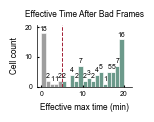

In [6]:
_snr_effective_time_figure_folder = globals().get('figure_save_folder')
if _snr_effective_time_figure_folder is None:
    _snr_effective_time_figure_folder = Path(config.figures_root) / globals().get('FIRST10_FIGURE_FOLDER', 'CKII_pooled')

snr_effective_time_dist = summarize_snr_effective_max_time(
    config=config,
    snr_removed_summary=snr_dist,
    by_place_cells_only=snr_dist_scope_place_cells_only,
    show_plot=True,
    bin_width_minutes=1.0,
    figure_save_folder=_snr_effective_time_figure_folder,
    show_legend=False,
)

display(snr_effective_time_dist["overall"])
display(snr_effective_time_dist["per_animal"])


Loaded 7 cells from CKII_pAce21_PR_20250806
Loaded 7 cells from CKII_pAce38_PX_20251126
Loaded 9 cells from CKII_pAce45_PX_20260118
Loaded 4 cells from CKII_pAce47_PX_20260128
Loaded 7 cells from CKII_pAce46_PR_20260222
Loaded 9 cells from CKII_pAce50_PRL_20260317
Loaded 16 cells from CKII_pAce54_PR_20260506
Loaded 6 cells from CKII_pAce54_PX_20260514

Total: 65 cells loaded


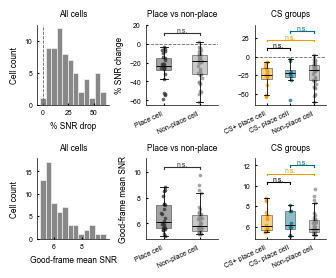

First-vs-last saved/interpolated SNR change: valid cells=65/65, median change=-20.08% (negative means SNR dropped).
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SNR_FirstLast1min_SignedChange.svg


,n_cells_total,n_cells_valid_change,n_cells_valid_good_frame_snr,n_cells_skipped,first_1min_mean_snr_mean,first_1min_mean_snr_median,first_1min_mean_snr_std,first_1min_mean_snr_sem,first_1min_mean_snr_min,first_1min_mean_snr_max,...,overall_good_frame_mean_snr_std,overall_good_frame_mean_snr_sem,overall_good_frame_mean_snr_min,overall_good_frame_mean_snr_max,good_snr_minutes_mean,good_snr_minutes_median,good_snr_minutes_std,good_snr_minutes_sem,good_snr_minutes_min,good_snr_minutes_max
0,65,65,65,24,7.311408,6.578465,2.134528,0.264756,5.048453,14.085078,...,1.108688,0.137516,5.045972,9.716308,14.847497,16.159433,4.509844,0.559377,5.669933,19.9088


,grouping,group,n_cells,n_animals,n_cells_valid_good_frame_snr,n_animals_valid_good_frame_snr,first_1min_mean_snr_mean,first_1min_mean_snr_median,first_1min_mean_snr_std,first_1min_mean_snr_sem,...,overall_good_frame_mean_snr_std,overall_good_frame_mean_snr_sem,overall_good_frame_mean_snr_min,overall_good_frame_mean_snr_max,good_snr_minutes_mean,good_snr_minutes_median,good_snr_minutes_std,good_snr_minutes_sem,good_snr_minutes_min,good_snr_minutes_max
0,all_cells,All cells,65,8,65,8,7.311408,6.578465,2.134528,0.264756,...,1.108688,0.137516,5.045972,9.716308,14.847497,16.159433,4.509844,0.559377,5.669933,19.908800
1,place_nonplace,Place cell,24,8,24,8,7.693513,6.867893,2.193053,0.447655,...,1.143409,0.233397,5.045972,8.819617,14.227367,13.912967,4.428695,0.904004,5.939833,19.889400
2,place_nonplace,Non-place cell,41,8,41,8,7.087737,6.215323,2.094182,0.327056,...,1.082789,0.169103,5.174891,9.716308,15.210501,16.451700,4.571480,0.713945,5.669933,19.908800
3,cs_place_nonplace,CS+ place cell,16,7,16,7,7.849415,6.867893,2.283550,0.570887,...,1.176561,0.294140,5.463427,8.819617,14.701485,14.377017,4.105884,1.026471,7.937333,19.889400
4,cs_place_nonplace,CS- place cell,8,5,8,5,7.381709,6.932122,2.112292,0.746808,...,1.146829,0.405465,5.045972,8.146313,13.279129,13.184000,5.174701,1.829533,5.939833,19.884133
5,cs_place_nonplace,Non-place cell,41,8,41,8,7.087737,6.215323,2.094182,0.327056,...,1.082789,0.169103,5.174891,9.716308,15.210501,16.451700,4.571480,0.713945,5.669933,19.908800


,comparison,metric,group_a,group_b,n_a,n_b,median_a,median_b,median_delta_a_minus_b,test,statistic,p_value,holm_p_value,significance,holm_significance
0,place_vs_nonplace,pct_snr_change_last_vs_first,Place cell,Non-place cell,24,41,-23.433993,-17.992129,-5.441864,mann-whitney u,430.0,0.403166,1.0,n.s.,n.s.
1,csplus_vs_csminus,pct_snr_change_last_vs_first,CS+ place cell,CS- place cell,16,8,-24.214411,-22.341667,-1.872745,mann-whitney u,59.0,0.787463,1.0,n.s.,n.s.
2,csplus_vs_nonplace,pct_snr_change_last_vs_first,CS+ place cell,Non-place cell,16,41,-24.214411,-17.992129,-6.222283,mann-whitney u,279.0,0.389060,1.0,n.s.,n.s.
3,csminus_vs_nonplace,pct_snr_change_last_vs_first,CS- place cell,Non-place cell,8,41,-22.341667,-17.992129,-4.349538,mann-whitney u,151.0,0.740079,1.0,n.s.,n.s.


,comparison,metric,group_a,group_b,n_a,n_b,median_a,median_b,median_delta_a_minus_b,test,statistic,p_value,holm_p_value,significance,holm_significance
0,place_vs_nonplace,overall_good_frame_mean_snr,Place cell,Non-place cell,24,41,6.086688,5.791735,0.294953,mann-whitney u,589.0,0.189607,0.697115,n.s.,n.s.
1,csplus_vs_csminus,overall_good_frame_mean_snr,CS+ place cell,CS- place cell,16,8,6.086688,6.171083,-0.084395,mann-whitney u,66.0,0.928439,1.000000,n.s.,n.s.
2,csplus_vs_nonplace,overall_good_frame_mean_snr,CS+ place cell,Non-place cell,16,41,6.086688,5.791735,0.294953,mann-whitney u,405.0,0.174279,0.697115,n.s.,n.s.
3,csminus_vs_nonplace,overall_good_frame_mean_snr,CS- place cell,Non-place cell,8,41,6.171083,5.791735,0.379347,mann-whitney u,184.0,0.604422,1.000000,n.s.,n.s.


Skipped/malformed cells:


,animal_id,cell_idx,cell_num,reason
0,CKII_pAce21_PR_20250806,7,8,not in spatial classification output; excluded...
1,CKII_pAce21_PR_20250806,8,9,not in spatial classification output; excluded...
2,CKII_pAce38_PX_20251126,2,3,not in spatial classification output; excluded...
3,CKII_pAce38_PX_20251126,7,8,not in spatial classification output; excluded...
4,CKII_pAce45_PX_20260118,5,6,not in spatial classification output; excluded...
5,CKII_pAce45_PX_20260118,7,8,not in spatial classification output; excluded...
6,CKII_pAce45_PX_20260118,9,10,not in spatial classification output; excluded...
7,CKII_pAce45_PX_20260118,10,11,not in spatial classification output; excluded...
8,CKII_pAce45_PX_20260118,13,14,not in spatial classification output; excluded...
9,CKII_pAce45_PX_20260118,14,15,not in spatial classification output; excluded...


Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SNR_FirstLast1min_SignedChange.svg


In [7]:
snr_change_window_seconds = 60.0

figure_save_folder = os.path.join(str(config.figures_root), 'CKII_pooled')
os.makedirs(figure_save_folder, exist_ok=True)

_spatial_data_config_key_current = (
    os.path.abspath(str(config.data_root)),
    tuple(config.animals),
    int(config.pooled.cb_num_threshold),
    float(config.pooled.cs_peak_rate_threshold),
    str(config.pooled.cs_plc_definition_mode),
    float(config.analysis.snr_threshold),
    float(config.analysis.min_good_minutes),
)

if globals().get('spatial_data_config_key') != _spatial_data_config_key_current:
    spatial_data = classify_spatial_cells(
        data_folder=str(config.data_root),
        folders=config.animals,
        cb_num_threshold=config.pooled.cb_num_threshold,
        cs_peak_rate_threshold=config.pooled.cs_peak_rate_threshold,
        cs_plc_definition_mode=config.pooled.cs_plc_definition_mode,
        snr_threshold=config.analysis.snr_threshold,
        min_good_minutes=config.analysis.min_good_minutes,
    )
    spatial_data_config_key = _spatial_data_config_key_current
else:
    print('Reusing existing spatial_data for SNR-change grouping.')

snr_first_last = summarize_first_last_minute_snr_change(
    config=config,
    spatial_data=spatial_data,
    window_seconds=snr_change_window_seconds,
    figure_save_folder=figure_save_folder,
    save_name='SNR_FirstLast1min_SignedChange.svg',
    show_plot=True,
)

display(snr_first_last['overall'])
display(snr_first_last['group_summary'])
display(snr_first_last['comparisons'])
display(snr_first_last['good_frame_snr_comparisons'])

if len(snr_first_last['skipped_cells']) > 0:
    print('Skipped/malformed cells:')
    display(snr_first_last['skipped_cells'])

if snr_first_last['figure_path']:
    print(f"Generated: {snr_first_last['figure_path']}")


x_neural missing-frame pie figure saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/BehaviorNaN_RemovedSeconds_ByAnimal_Pies.svg
x_neural missing-frame summary CSV saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/BehaviorNaN_RemovedSeconds_ByAnimal.csv


,animal_id,requested_variable,resolved_variable,n_frames,frame_rate,duration_s,missing_frames,missing_seconds,missing_percent,finite_seconds,load_error
0,CKII_pAce21_PR_20250806,x_neural,x_neural,299500,500.0,599.000,120,0.240,0.040067,598.760,
1,CKII_pAce38_PX_20251126,x_neural,x_neural,597670,500.0,1195.340,0,0.000,0.000000,1195.340,
2,CKII_pAce45_PX_20260118,x_neural,x_neural,598609,500.0,1197.218,167,0.334,0.027898,1196.884,
3,CKII_pAce47_PX_20260128,x_neural,x_neural,598461,500.0,1196.922,1036,2.072,0.173111,1194.850,
4,CKII_pAce46_PR_20260222,x_neural,x_neural,598579,500.0,1197.158,76,0.152,0.012697,1197.006,
5,CKII_pAce50_PRL_20260317,x_neural,x_neural,599087,500.0,1198.174,0,0.000,0.000000,1198.174,
6,CKII_pAce54_PR_20260506,x_neural,x_neural,599137,500.0,1198.274,0,0.000,0.000000,1198.274,
7,CKII_pAce54_PX_20260514,x_neural,x_neural,599130,500.0,1198.260,10205,20.410,1.703303,1177.850,


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/BehaviorNaN_RemovedSeconds_ByAnimal_Pies.svg
Saved CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/BehaviorNaN_RemovedSeconds_ByAnimal.csv
head direction missing-frame pie figure saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/HeadDirectionNaN_RemovedSeconds_ByAnimal_Pies.svg
head direction missing-frame summary CSV saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/HeadDirectionNaN_RemovedSeconds_ByAnimal.csv


,animal_id,requested_variable,resolved_variable,n_frames,frame_rate,duration_s,missing_frames,missing_seconds,missing_percent,finite_seconds,load_error
0,CKII_pAce21_PR_20250806,hd_angles_neural,hd_angles_neural,299500,500.0,599.000,3879,7.758,1.295159,591.242,
1,CKII_pAce38_PX_20251126,hd_angles_neural,hd_angles_neural,597670,500.0,1195.340,3797,7.594,0.635300,1187.746,
2,CKII_pAce45_PX_20260118,hd_angles_neural,hd_angles_neural,598609,500.0,1197.218,4274,8.548,0.713989,1188.670,
3,CKII_pAce47_PX_20260128,hd_angles_neural,hd_angles_neural,598461,500.0,1196.922,6560,13.120,1.096145,1183.802,
4,CKII_pAce46_PR_20260222,hd_angles_neural,hd_angles_neural,598579,500.0,1197.158,2250,4.500,0.375890,1192.658,
5,CKII_pAce50_PRL_20260317,hd_angles_neural,hd_angles_neural,599087,500.0,1198.174,1425,2.850,0.237862,1195.324,
6,CKII_pAce54_PR_20260506,hd_angles_neural,hd_angles_neural,599137,500.0,1198.274,673,1.346,0.112328,1196.928,
7,CKII_pAce54_PX_20260514,hd_angles_neural,hd_angles_neural,599130,500.0,1198.260,34800,69.600,5.808422,1128.660,


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/HeadDirectionNaN_RemovedSeconds_ByAnimal_Pies.svg
Saved CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/HeadDirectionNaN_RemovedSeconds_ByAnimal.csv


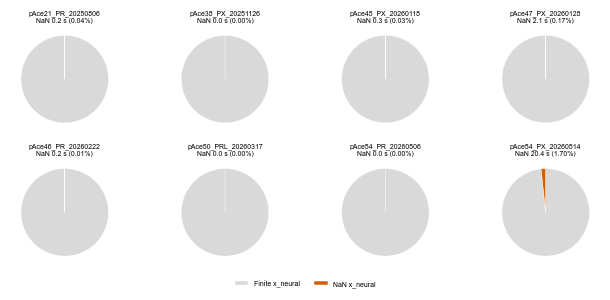

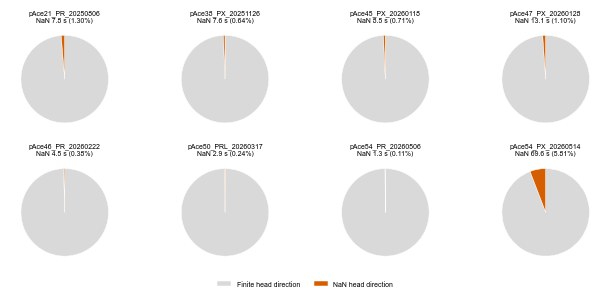

In [8]:
# Analyze missing behavior in each animal
figure_save_folder = os.path.join(str(config.figures_root), 'CKII_pooled')
os.makedirs(figure_save_folder, exist_ok=True)

behavior_nan = plot_missing_frame_seconds_by_animal(
    config=config,
    variable_key='x_neural',
    variable_label='x_neural',
    figure_save_folder=figure_save_folder,
    save_name='BehaviorNaN_RemovedSeconds_ByAnimal_Pies.svg',
    csv_name='BehaviorNaN_RemovedSeconds_ByAnimal.csv',
    show_plot=True,
    figsize=(6.6, 2.9),
    n_cols=4,
)
display(behavior_nan['summary_df'])
print(f"Saved: {behavior_nan['figure_path']}")
print(f"Saved CSV: {behavior_nan['csv_path']}")

head_direction_nan = plot_missing_frame_seconds_by_animal(
    config=config,
    variable_key='hd_angles_neural',
    variable_label='head direction',
    figure_save_folder=figure_save_folder,
    save_name='HeadDirectionNaN_RemovedSeconds_ByAnimal_Pies.svg',
    csv_name='HeadDirectionNaN_RemovedSeconds_ByAnimal.csv',
    show_plot=True,
    figsize=(6.6, 2.9),
    n_cols=4,
)
display(head_direction_nan['summary_df'])
print(f"Saved: {head_direction_nan['figure_path']}")
print(f"Saved CSV: {head_direction_nan['csv_path']}")


### Spatial Heatmap Prep (Direct Core Functions)

In [9]:
figure_save_folder = os.path.join(str(config.figures_root), 'CKII_pooled')
os.makedirs(figure_save_folder, exist_ok=True)

_spatial_data_config_key_current = (
    os.path.abspath(str(config.data_root)),
    tuple(config.animals),
    int(config.pooled.cb_num_threshold),
    float(config.pooled.cs_peak_rate_threshold),
    str(config.pooled.cs_plc_definition_mode),
    float(config.analysis.snr_threshold),
    float(config.analysis.min_good_minutes),
)

if globals().get('spatial_data_config_key') != _spatial_data_config_key_current:
    spatial_data = classify_spatial_cells(
        data_folder=str(config.data_root),
        folders=config.animals,
        cb_num_threshold=config.pooled.cb_num_threshold,
        cs_peak_rate_threshold=config.pooled.cs_peak_rate_threshold,
        cs_plc_definition_mode=config.pooled.cs_plc_definition_mode,
        snr_threshold=config.analysis.snr_threshold,
        min_good_minutes=config.analysis.min_good_minutes,
    )
    spatial_data_config_key = _spatial_data_config_key_current
else:
    print('Reusing existing spatial_data for spatial heatmap prep.')

all_cells_for_vlim = spatial_data.plcs_csplus + spatial_data.plcs_csminus + spatial_data.non_plcs
global_theta_vlim, global_slow_vlim = compute_global_theta_slow_vlims(all_cells_for_vlim)

# Keep style/limits consistent with your current pooled notebook
selected_theta_vlim = [0, 0.2] if global_theta_vlim is not None else None
selected_slow_vlim = [-0.15, 0.15] if global_slow_vlim is not None else None

# Plateau heatmap controls for plot_selected_cells_figure
include_plateau_heatmap = True
plateau_state_mode = 'split'  # {'split', 'all', 'moving', 'resting'}
plateau_include_long_cb_as_plateau = False
plateau_cb_min_duration_ms = 200.0
plateau_speed_threshold = 3.0

print(f"CS+ PLCs: {len(spatial_data.plcs_csplus)}")
print(f"CS- PLCs: {len(spatial_data.plcs_csminus)}")
print(f"Non-PLCs: {len(spatial_data.non_plcs)}")
print(f"theta vlim (global): {global_theta_vlim}; using: {selected_theta_vlim}")
print(f"slow vlim (global): {global_slow_vlim}; using: {selected_slow_vlim}")
print(
    "Plateau settings:",
    {
        'include_plateau_heatmap': include_plateau_heatmap,
        'plateau_state_mode': plateau_state_mode,
        'plateau_include_long_cb_as_plateau': plateau_include_long_cb_as_plateau,
        'plateau_cb_min_duration_ms': plateau_cb_min_duration_ms,
        'plateau_speed_threshold': plateau_speed_threshold,
    }
)



Reusing existing spatial_data for spatial heatmap prep.
CS+ PLCs: 16
CS- PLCs: 8
Non-PLCs: 41
theta vlim (global): (np.float64(0.04555849743840422), np.float64(0.2194512966363137)); using: [0, 0.2]
slow vlim (global): (np.float64(-0.15657572810406967), np.float64(0.15657572810406967)); using: [-0.15, 0.15]
Plateau settings: {'include_plateau_heatmap': True, 'plateau_state_mode': 'split', 'plateau_include_long_cb_as_plateau': False, 'plateau_cb_min_duration_ms': 200.0, 'plateau_speed_threshold': 3.0}


### CellType_Distribution_PieChart

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/CellType_Distribution_PieChart.svg


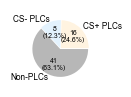

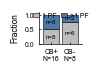

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/MultiplePF_Percentage_CSplus_CSminus.svg


,group,n_cells,n_single_pf,n_multiple_pf,pct_single_pf,pct_multiple_pf
0,CS+ PLCs,16,8,8,50.0,50.0
1,CS- PLCs,8,6,2,75.0,25.0


In [10]:
pie_path = os.path.join(figure_save_folder, 'CellType_Distribution_PieChart.svg')

plot_celltype_distribution_pie(
    spatial_data.plcs_csplus,
    spatial_data.plcs_csminus,
    spatial_data.non_plcs,
    save_path=pie_path,
    fig_width=0.8,
    fig_height=1.0,
)

print(f'Saved: {pie_path}')

multiple_pf_path = os.path.join(figure_save_folder, 'MultiplePF_Percentage_CSplus_CSminus.svg')
multiple_pf_summary = plot_multiple_pf_percentage_by_group(
    spatial_data.plcs_csplus,
    spatial_data.plcs_csminus,
    save_path=multiple_pf_path,
    fig_width=0.9,
    fig_height=0.75,
)
plt.show()
print(f'Saved: {multiple_pf_path}')
display(multiple_pf_summary['summary_df'])


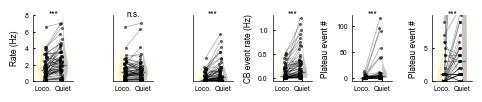

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/StateDep_FiringRates_AllCells_WithPlateauCount.svg
Cells included per subplot:
  1. All: 65
  2. SS: 65
  3. CS: 63
  4. Complex burst rate: 63
  5. Plateau: 41
  6. Plateau zoom: 41
Cells with CB quiet > 10 and CB loco <= 2: 7
Complex burst event counts for those cells: Loco=9, Quiet=292


In [11]:
state_dep_figsize = (4.8, 1.0)
state_dep_rate_ylim_max = 8.0
state_dep_plateau_zoom_ylim_max = 10.0

if "pooled_stats" not in globals():
    pooled_stats = prepare_pooled_stats_tables(
        data_folder=str(config.data_root),
        folders=config.animals,
        cb_num_threshold=config.pooled.cb_num_threshold,
        cs_peak_rate_threshold=config.pooled.cs_peak_rate_threshold,
        cs_plc_definition_mode=config.pooled.cs_plc_definition_mode,
        snr_threshold=config.analysis.snr_threshold,
    )

state_dep_out = plot_state_dependent_firing_rates_with_plateau_count(
    config,
    pooled_stats,
    figure_save_folder,
    plateau_include_long_cb_as_plateau=plateau_include_long_cb_as_plateau,
    plateau_cb_min_duration_ms=plateau_cb_min_duration_ms,
    plateau_speed_threshold=plateau_speed_threshold,
    rate_ylim_max=state_dep_rate_ylim_max,
    plateau_zoom_ylim_max=state_dep_plateau_zoom_ylim_max,
    figsize=state_dep_figsize,
    save_name="StateDep_FiringRates_AllCells_WithPlateauCount.svg",
    show_plot=True,
)
print(f"Generated: {state_dep_out['figure_path']}")
print("Cells included per subplot:")
print(f"  1. All: {state_dep_out['subplot_counts']['all_rate']}")
print(f"  2. SS: {state_dep_out['subplot_counts']['ss_rate']}")
print(f"  3. CS: {state_dep_out['subplot_counts']['cs_rate']}")
print(f"  4. Complex burst rate: {state_dep_out['subplot_counts']['complex_burst_rate']}")
print(f"  5. Plateau: {state_dep_out['subplot_counts']['plateau']}")
print(f"  6. Plateau zoom: {state_dep_out['subplot_counts']['plateau_zoom']}")
cs_quiet_high_mask = (((state_dep_out['summary_df']['complex_burst_event_count_quiet'] > 10) & (state_dep_out['summary_df']['complex_burst_event_count_loco'] <= 2)).fillna(False))
print(f"Cells with CB quiet > 10 and CB loco <= 2: {int(cs_quiet_high_mask.sum())}")
print(
    "Complex burst event counts for those cells: "
    f"Loco={int(state_dep_out['summary_df'].loc[cs_quiet_high_mask, 'complex_burst_event_count_loco'].fillna(0).sum())}, "
    f"Quiet={int(state_dep_out['summary_df'].loc[cs_quiet_high_mask, 'complex_burst_event_count_quiet'].fillna(0).sum())}"
)


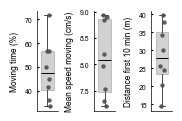

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/AnimalMovementSummary.svg


In [12]:
movement_summary_figsize = (1.8, 1.2)

movement_summary_out = plot_animal_movement_summary_boxplots(
    config,
    figure_save_folder,
    first_n_minutes=10.0,
    figsize=movement_summary_figsize,
    save_name="AnimalMovementSummary.svg",
    show_plot=True,
)
print(f"Generated: {movement_summary_out['figure_path']}")



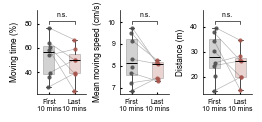

Included first-window-only recordings: CKII_pAce21_PR_20250806 (9.98 min)


,metric,label,n_animals,first_mean,last_mean,mean_delta_last_minus_first,median_delta_last_minus_first,test,statistic,p_value
0,moving_percent,Moving time (%),7,54.396309,46.968990,-7.427318,-9.790126,wilcoxon,8.0,0.375000
1,mean_speed_cm_s,Mean moving speed (cm/s),7,8.352242,7.829225,-0.523017,-0.391198,wilcoxon,5.0,0.156250
2,distance_m,Distance (m),7,29.452491,24.379557,-5.072934,-4.982429,wilcoxon,7.0,0.296875


Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/AnimalMovementFirstLast10minComparison.svg


In [13]:
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)

movement_first_last_out = _pcp.plot_animal_movement_first_last_window_comparison(
    config,
    figure_save_folder,
    window_minutes=10.0,
    include_short_recordings_in_first_window=True,
    figsize=(2.6, 1.2),
    save_name="AnimalMovementFirstLast10minComparison.svg",
    show_plot=True,
)

if movement_first_last_out["skipped_animals"]:
    skipped = ", ".join(
        f"{row['animal_id']} ({row['recording_duration_min']:.2f} min)"
        for row in movement_first_last_out["skipped_animals"]
    )
    print(f"Skipped recordings <= 10 min: {skipped}")

if movement_first_last_out["unpaired_animals"]:
    unpaired = ", ".join(
        f"{row['animal_id']} ({row['recording_duration_min']:.2f} min)"
        for row in movement_first_last_out["unpaired_animals"]
    )
    print(f"Included first-window-only recordings: {unpaired}")

display(movement_first_last_out["stats_df"])
print(f"Generated: {movement_first_last_out['figure_path']}")


### SpatialHeatmaps_All_PLCs_CSplus_then_CSminus_Combined

pAce21 Cell 2: removed_snr=9927/299500 (3.31%), removed_total=10048/299500 (3.35%)
pAce21 Cell 2: SS PF mask is empty
pAce21 Cell 3: removed_snr=15953/299500 (5.33%), removed_total=16074/299500 (5.37%)
pAce21 Cell 3: SS PF mask is empty
pAce38 Cell 4: removed_snr=988/597670 (0.17%), removed_total=988/597670 (0.17%)
pAce38 Cell 6: removed_snr=988/597670 (0.17%), removed_total=988/597670 (0.17%)
pAce38 Cell 7: removed_snr=22650/597670 (3.79%), removed_total=22650/597670 (3.79%)
pAce45 Cell 5: removed_snr=31486/598609 (5.26%), removed_total=31655/598609 (5.29%)
pAce45 Cell 12: removed_snr=154783/598609 (25.86%), removed_total=154952/598609 (25.89%)
pAce47 Cell 1: removed_snr=85457/598461 (14.28%), removed_total=86497/598461 (14.45%)
pAce47 Cell 3: removed_snr=74396/598461 (12.43%), removed_total=75436/598461 (12.60%)
pAce47 Cell 4: removed_snr=178457/598461 (29.82%), removed_total=179497/598461 (29.99%)
pAce50 Cell 9: removed_snr=222158/599087 (37.08%), removed_total=222158/599087 (37.08%

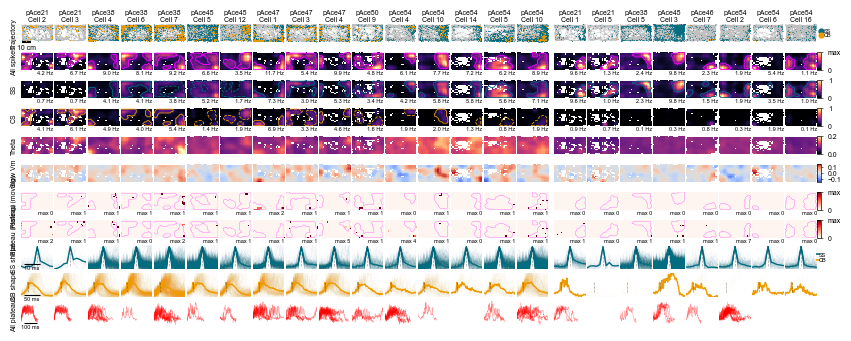

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_PLCs_CSplus_then_CSminus_Combined.svg


In [14]:
csplus_all = list(spatial_data.plcs_csplus)
csminus_all = list(spatial_data.plcs_csminus)

out_path = os.path.join(figure_save_folder, "SpatialHeatmaps_All_PLCs_CSplus_then_CSminus_Combined.svg")
plot_selected_cells_figure(
    cell_groups=[csplus_all, csminus_all],
    group_names=['CS+ PLC', 'CS- PLC'],
    subplot_width=0.33,
    theta_vlim=selected_theta_vlim,
    slow_vlim=selected_slow_vlim,
    save_path=out_path,
    plot_putative_PF=True,
    show_place_cell_star=False,
    show_significance_marker=False,
    shape_ylim=(-0.5, 2.0),
    include_plateau=include_plateau_heatmap,
    plateau_state_mode=plateau_state_mode,
    plateau_include_long_cb_as_plateau=plateau_include_long_cb_as_plateau,
    plateau_cb_min_duration_ms=plateau_cb_min_duration_ms,
    plateau_speed_threshold=plateau_speed_threshold,
)
print(f"Generated: {out_path}")



### SpatialHeatmaps_All_NonPLCs (may generate multiple part files)

Rendering SpatialHeatmaps_All_NonPLCs_part01.svg: cells=10
pAce21 Cell 4: removed_snr=20626/299500 (6.89%), removed_total=20747/299500 (6.93%)
pAce21 Cell 4: All spikes PF mask is empty
pAce21 Cell 4: SS PF mask is empty
pAce21 Cell 4: CS PF mask is empty
pAce21 Cell 6: removed_snr=16323/299500 (5.45%), removed_total=16444/299500 (5.49%)
pAce21 Cell 6: SS PF mask is empty
pAce21 Cell 7: removed_snr=18254/299500 (6.09%), removed_total=18375/299500 (6.14%)
pAce21 Cell 7: SS PF mask is empty
pAce38 Cell 1: removed_snr=170658/597670 (28.55%), removed_total=170658/597670 (28.55%)
pAce38 Cell 2: removed_snr=988/597670 (0.17%), removed_total=988/597670 (0.17%)
pAce38 Cell 2: CS PF mask is empty
pAce38 Cell 9: removed_snr=267507/597670 (44.76%), removed_total=267507/597670 (44.76%)
pAce38 Cell 9: CS PF mask is empty
pAce45 Cell 1: removed_snr=47176/598609 (7.88%), removed_total=47345/598609 (7.91%)
pAce45 Cell 1: CS PF mask is empty
pAce45 Cell 2: removed_snr=2071/598609 (0.35%), removed_total

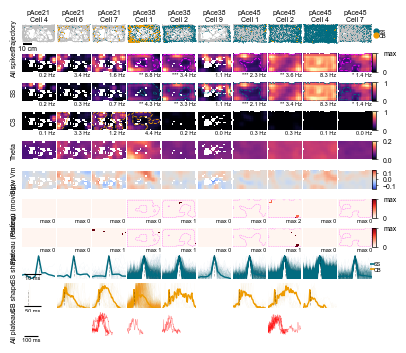

Rendering SpatialHeatmaps_All_NonPLCs_part02.svg: cells=10
pAce45 Cell 9: removed_snr=428342/598609 (71.56%), removed_total=428511/598609 (71.58%)
pAce45 Cell 9: CS PF mask is empty
pAce45 Cell 13: removed_snr=93749/598609 (15.66%), removed_total=93918/598609 (15.69%)
pAce45 Cell 13: CS PF mask is empty
pAce47 Cell 5: removed_snr=72745/598461 (12.16%), removed_total=73785/598461 (12.33%)
pAce46 Cell 1: removed_snr=40454/598579 (6.76%), removed_total=40531/598579 (6.77%)
pAce46 Cell 1: CS PF mask is empty
pAce46 Cell 4: removed_snr=112527/598579 (18.80%), removed_total=112604/598579 (18.81%)
pAce46 Cell 4: CS PF mask is empty
pAce46 Cell 5: removed_snr=171562/598579 (28.66%), removed_total=171639/598579 (28.67%)
pAce46 Cell 6: removed_snr=59191/598579 (9.89%), removed_total=59268/598579 (9.90%)
pAce46 Cell 6: All spikes PF mask is empty
pAce46 Cell 6: SS PF mask is empty
pAce46 Cell 6: CS PF mask is empty
pAce46 Cell 8: removed_snr=6176/598579 (1.03%), removed_total=6253/598579 (1.04%)


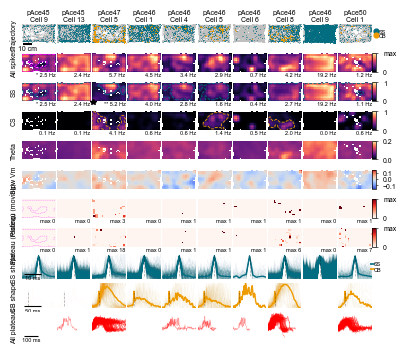

Rendering SpatialHeatmaps_All_NonPLCs_part03.svg: cells=10
pAce50 Cell 2: removed_snr=1823/599087 (0.30%), removed_total=1823/599087 (0.30%)
pAce50 Cell 2: CS PF mask is empty
pAce50 Cell 3: removed_snr=38036/599087 (6.35%), removed_total=38036/599087 (6.35%)
pAce50 Cell 4: removed_snr=1823/599087 (0.30%), removed_total=1823/599087 (0.30%)
pAce50 Cell 4: CS PF mask is empty
pAce50 Cell 5: removed_snr=262381/599087 (43.80%), removed_total=262381/599087 (43.80%)
pAce50 Cell 5: All spikes PF mask is empty
pAce50 Cell 5: SS PF mask is empty
pAce50 Cell 5: CS PF mask is empty
pAce50 Cell 6: removed_snr=1823/599087 (0.30%), removed_total=1823/599087 (0.30%)
pAce50 Cell 6: CS PF mask is empty
pAce50 Cell 7: removed_snr=1823/599087 (0.30%), removed_total=1823/599087 (0.30%)
pAce50 Cell 7: CS PF mask is empty
pAce50 Cell 8: removed_snr=105536/599087 (17.62%), removed_total=105536/599087 (17.62%)
pAce50 Cell 8: CS PF mask is empty
pAce54 Cell 1: removed_snr=11535/599137 (1.93%), removed_total=11

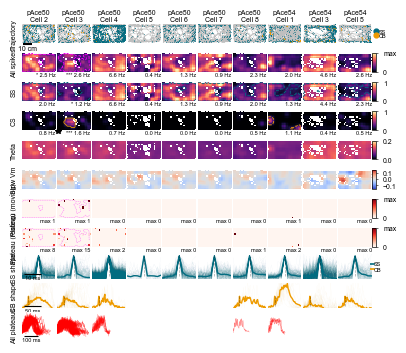

Rendering SpatialHeatmaps_All_NonPLCs_part04.svg: cells=10
pAce54 Cell 7: removed_snr=366673/599137 (61.20%), removed_total=366673/599137 (61.20%)
pAce54 Cell 8: removed_snr=349586/599137 (58.35%), removed_total=349586/599137 (58.35%)
pAce54 Cell 8: All spikes PF mask is empty
pAce54 Cell 8: SS PF mask is empty
pAce54 Cell 8: CS PF mask is empty
pAce54 Cell 9: removed_snr=6612/599137 (1.10%), removed_total=6612/599137 (1.10%)
pAce54 Cell 11: removed_snr=38917/599137 (6.50%), removed_total=38917/599137 (6.50%)
pAce54 Cell 11: CS PF mask is empty
pAce54 Cell 12: removed_snr=31854/599137 (5.32%), removed_total=31854/599137 (5.32%)
pAce54 Cell 13: removed_snr=114354/599137 (19.09%), removed_total=114354/599137 (19.09%)
pAce54 Cell 13: CS PF mask is empty
pAce54 Cell 15: removed_snr=159232/599137 (26.58%), removed_total=159232/599137 (26.58%)
pAce54 Cell 8: removed_snr=184551/599130 (30.80%), removed_total=194822/599130 (32.52%)
pAce54 Cell 8: CS PF mask is empty
pAce54 Cell 12: removed_snr

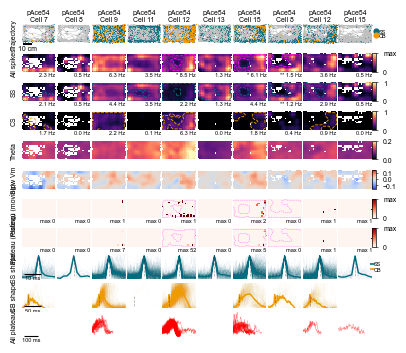

Rendering SpatialHeatmaps_All_NonPLCs_part05.svg: cells=1
pAce54 Cell 16: removed_snr=378013/599130 (63.09%), removed_total=388284/599130 (64.81%)
pAce54 Cell 16: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part05.svg


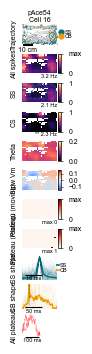

Generated files: 5
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part01.svg
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part02.svg
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part03.svg
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part04.svg
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part05.svg


In [15]:
out_paths = render_spatial_heatmap_chunks(
    spatial_data.non_plcs,
    figure_save_folder=figure_save_folder,
    base_filename='SpatialHeatmaps_All_NonPLCs.svg',
    max_cells_per_figure=10,
    subplot_width=0.35,
    theta_vlim=selected_theta_vlim,
    slow_vlim=selected_slow_vlim,
    plot_putative_PF=True,
    show_place_cell_star=True,
    show_significance_marker=True,
    pf_only_place_cells=False,
    include_plateau=include_plateau_heatmap,
    plateau_state_mode=plateau_state_mode,
    plateau_include_long_cb_as_plateau=plateau_include_long_cb_as_plateau,
    plateau_cb_min_duration_ms=plateau_cb_min_duration_ms,
    plateau_speed_threshold=plateau_speed_threshold,
)

print(f"Generated files: {len(out_paths)}")
for pth in out_paths:
    print(f"  {pth}")



### SpatialHeatmaps_All_PLCs_CB

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_PLCs_CB.svg


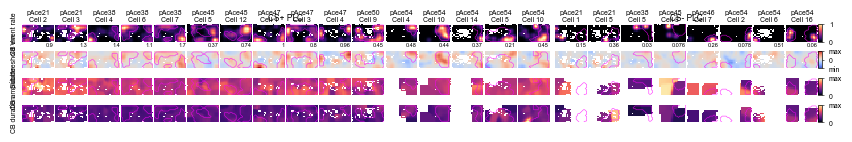

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_PLCs_CB.svg


In [33]:
csplus_all = list(spatial_data.plcs_csplus)
csminus_all = list(spatial_data.plcs_csminus)

out_path = os.path.join(figure_save_folder, "SpatialHeatmaps_All_PLCs_CB.svg")
plot_complex_burst_event_heatmaps(
    cell_groups=[csplus_all, csminus_all],
    group_names=['CS+ PLC', 'CS- PLC'],
    subplot_width=0.33,
    save_path=out_path,
    plot_pf_contours=True,
)
print(f"Generated: {out_path}")


### SpatilHeatmaps_selected_cells

pAce38 Cell 4: removed_snr=988/597670 (0.17%), removed_total=988/597670 (0.17%)
pAce54 Cell 4: removed_snr=243253/599137 (40.60%), removed_total=243253/599137 (40.60%)
pAce47 Cell 1: removed_snr=85457/598461 (14.28%), removed_total=86497/598461 (14.45%)
pAce21 Cell 1: removed_snr=17959/299500 (6.00%), removed_total=18080/299500 (6.04%)
pAce21 Cell 1: CS PF mask is empty
pAce38 Cell 5: removed_snr=1146/597670 (0.19%), removed_total=1146/597670 (0.19%)
pAce38 Cell 5: CS PF mask is empty
pAce45 Cell 3: removed_snr=2050/598609 (0.34%), removed_total=2219/598609 (0.37%)
pAce45 Cell 3: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_SelectedCells_Transposed_CSplus_CSminus.svg


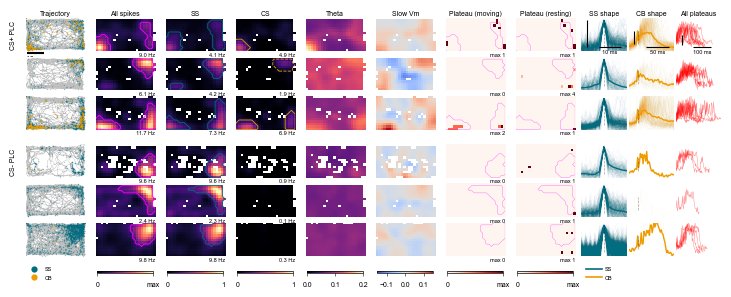

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_SelectedCells_Transposed_CSplus_CSminus.svg


In [17]:
def _animal_short(cell):
    animal_id = str(cell.get("animal_id", ""))
    return animal_id.split("_")[1] if "_" in animal_id else animal_id


def _select_spatial_cells(cells, specs, group_label):
    selected = []
    missing = []
    for animal_short, cell_num in specs:
        match = [
            cell for cell in cells
            if _animal_short(cell) == animal_short
            and int(cell.get("cell_idx", -1)) == int(cell_num) - 1
        ]
        if match:
            selected.append(match[0])
        else:
            missing.append(f"{animal_short} Cell {cell_num}")
    if missing:
        raise ValueError(f"Missing {group_label} selected cells: {', '.join(missing)}")
    return selected


selected_csplus_specs = [
    ("pAce38", 4),
    ("pAce54", 4),
    ("pAce47", 1),
]
selected_csminus_specs = [
    ("pAce21", 1),
    ("pAce38", 5),
    ("pAce45", 3),
]

selected_csplus = _select_spatial_cells(spatial_data.plcs_csplus, selected_csplus_specs, "CS+")
selected_csminus = _select_spatial_cells(spatial_data.plcs_csminus, selected_csminus_specs, "CS-")

# Marker area (points^2) for first-column SS/CB spike scatter.
selected_trajectory_spike_size = 1
# Marker opacity for first-column SS/CB spike scatter.
selected_trajectory_spike_alpha = 0.3

out_path = os.path.join(
    figure_save_folder,
    "SpatialHeatmaps_SelectedCells_Transposed_CSplus_CSminus.svg",
)

fig = plot_selected_cells_transposed_figure(
    cell_groups=[selected_csplus, selected_csminus],
    group_names=["CS+ PLC", "CS- PLC"],
    subplot_width=0.7,
    figsize=None,
    wspace=0.03,
    hspace=0.2,
    trailing_col_width_ratio=2/3,
    gap_ratio=0.1,
    trajectory_spike_size=selected_trajectory_spike_size,
    trajectory_spike_alpha=selected_trajectory_spike_alpha,
    theta_vlim=selected_theta_vlim,
    slow_vlim=selected_slow_vlim,
    save_path=out_path,
    plot_putative_PF=True,
    show_place_cell_star=False,
    show_significance_marker=False,
    shape_ylim=(-0.5, 2.0),
    include_plateau=include_plateau_heatmap,
    plateau_state_mode=plateau_state_mode,
    plateau_include_long_cb_as_plateau=plateau_include_long_cb_as_plateau,
    plateau_cb_min_duration_ms=plateau_cb_min_duration_ms,
    plateau_speed_threshold=plateau_speed_threshold,
)

print(f"Generated: {out_path}")


### Pooled Stats Prep (Direct Core Functions)

In [18]:
pooled_stats = prepare_pooled_stats_tables(
    data_folder=str(config.data_root),
    folders=config.animals,
    cb_num_threshold=config.pooled.cb_num_threshold,
    cs_peak_rate_threshold=config.pooled.cs_peak_rate_threshold,
    cs_plc_definition_mode=config.pooled.cs_plc_definition_mode,
    snr_threshold=config.analysis.snr_threshold,
)

df_cs_plc = pooled_stats.df_cs_plc
df_non_cs_plc = pooled_stats.df_non_cs_plc

print(f"Total valid cells: {len(pooled_stats.df_all)}")
print(f"Place cells: {len(pooled_stats.df_pc)}")
print(f"CS+ PLCs: {len(df_cs_plc)}")
print(f"CS- PLCs: {len(df_non_cs_plc)}")


Total valid cells: 65
Place cells: 24
CS+ PLCs: 16
CS- PLCs: 8


### MovingEpoch_CS_CB_Metrics_AllCells_PlaceCells


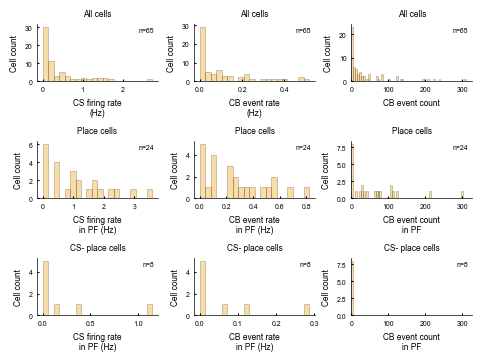

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/MovingEpoch_CS_CB_Metrics_AllCells_PlaceCells.svg


In [19]:
moving_epoch_hist_bins = 20
moving_epoch_count_bin_size = 5
moving_epoch_within_pf = True
out_path = os.path.join(figure_save_folder, 'MovingEpoch_CS_CB_Metrics_AllCells_PlaceCells.svg')
fig = plot_moving_epoch_cs_cb_metrics_allcells_placecells(
    summary_df=state_dep_out['summary_df'],
    classification_df=pooled_stats.df_all,
    save_path=out_path,
    hist_bins=moving_epoch_hist_bins,
    count_bin_size=moving_epoch_count_bin_size,
    within_pf=moving_epoch_within_pf,
    fig_width=4.8,
    fig_height=3.6,
)
plt.show()
print(f'Saved: {out_path}')


### combined_cs_plus_minus_4panels

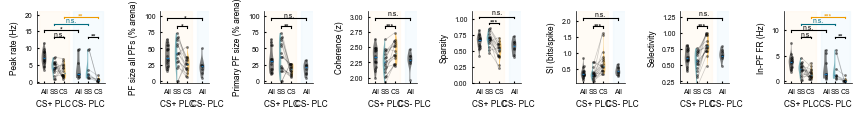

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/combined_cs_plus_minus_4panels.svg


In [20]:
combined_sig_marker_offset_frac = -0.05  # Star offset from bracket as a fraction of panel y-range; negative moves it downward.

out_path = os.path.join(figure_save_folder, 'combined_cs_plus_minus_4panels.svg')
fig = plot_combined_cs_plus_minus_4panels(
    df_cs_plc=df_cs_plc,
    df_non_cs_plc=df_non_cs_plc,
    save_path=out_path,
    plot_cs_minus_ss=False,
    show_only_significant=False,
    fig_width=8.6,
    fig_height=1.2,
    sig_marker_offset_frac=combined_sig_marker_offset_frac,
)
plt.show()
print(f'Saved: {out_path}')


### cs_plus_plc_correlations_overlay_cs_ss

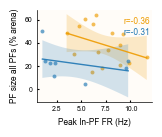

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/in_pf_peak_fr_vs_all_pf_size_csplus_csminus.svg


,group,fr_metric,fr_source_column,n,pearson_r,p_value,slope,intercept
0,CS+ PLC,peak,peak_rate_all,16,-0.364268,0.165414,-2.625441,57.565063
1,CS- PLC,peak,peak_rate_all,8,-0.314290,0.448363,-1.164427,27.236973


In [21]:
in_pf_fr_metric = 'peak'  # 'mean' or 'peak'
out_path = os.path.join(figure_save_folder, f'in_pf_{in_pf_fr_metric}_fr_vs_all_pf_size_csplus_csminus.svg')
in_pf_fr_pf_size = plot_in_pf_fr_vs_all_pf_size_by_cs_group(
    df_cs_plc=df_cs_plc,
    df_non_cs_plc=df_non_cs_plc,
    save_path=out_path,
    fig_width=1.6,
    fig_height=1.35,
    fr_metric=in_pf_fr_metric,
)
plt.show()
print(f"Saved: {out_path}")
display(in_pf_fr_pf_size["stats_df"])


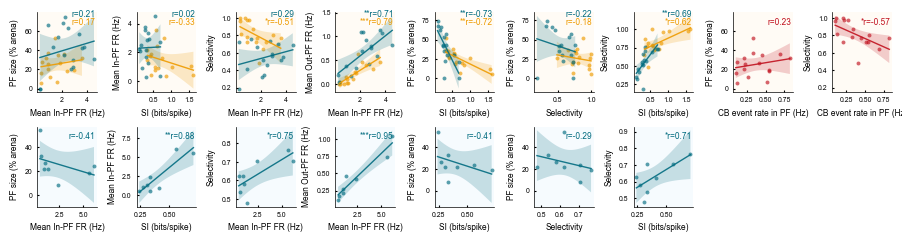

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/cs_plus_plc_correlations_overlay_cs_ss.svg


In [22]:
cs_plus_corr_fr_metric = 'mean'  # 'peak' or 'mean'
cs_minus_corr_spike_metric = 'ss'  # 'ss' or 'all'
out_path = os.path.join(figure_save_folder, 'cs_plus_plc_correlations_overlay_cs_ss.svg')
fig = plot_cs_plus_plc_correlations_overlay_cs_ss(
    df_cs_plc=df_cs_plc,
    df_non_cs_plc=df_non_cs_plc,
    save_path=out_path,
    overlay_ss_metrics=True,
    fr_metric=cs_plus_corr_fr_metric,
    csminus_spike_metric=cs_minus_corr_spike_metric,
)
plt.show()
print(f'Saved: {out_path}')


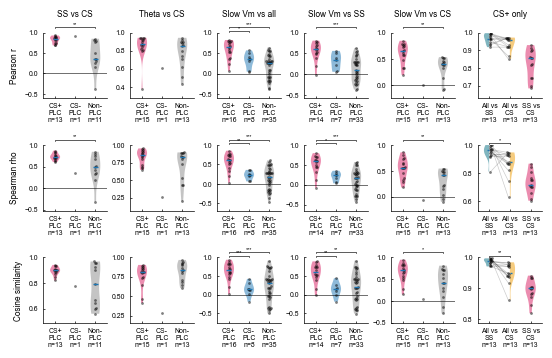

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/map_pair_similarity_by_cell_type.svg


,similarity_metric,similarity_label,map_pair,map_pair_label,group,n,mean,median,sd,sem,min,max
0,pearson,Pearson r,ss_vs_cs,SS vs CS,CS+ PLC,13,0.824274,0.853982,0.083071,0.023040,0.683860,0.929059
1,pearson,Pearson r,ss_vs_cs,SS vs CS,CS- PLC,1,0.908846,0.908846,NaN,NaN,0.908846,0.908846
2,pearson,Pearson r,ss_vs_cs,SS vs CS,Non-PLC,11,0.434542,0.361643,0.364860,0.110009,-0.373761,0.848828
3,pearson,Pearson r,theta_vs_cs,Theta vs CS,CS+ PLC,15,0.848961,0.870280,0.140699,0.036328,0.375204,0.941928
4,pearson,Pearson r,theta_vs_cs,Theta vs CS,CS- PLC,1,0.612400,0.612400,NaN,NaN,0.612400,0.612400
5,pearson,Pearson r,theta_vs_cs,Theta vs CS,Non-PLC,13,0.775073,0.855546,0.164033,0.045495,0.431752,0.942059
6,pearson,Pearson r,slow_vs_all,Slow Vm vs all,CS+ PLC,16,0.579262,0.638463,0.221100,0.055275,0.061281,0.819466
7,pearson,Pearson r,slow_vs_all,Slow Vm vs all,CS- PLC,8,0.324298,0.345969,0.183494,0.064875,0.047319,0.567119
8,pearson,Pearson r,slow_vs_all,Slow Vm vs all,Non-PLC,35,0.176734,0.259366,0.275288,0.046532,-0.382594,0.633733
9,pearson,Pearson r,slow_vs_ss,Slow Vm vs SS,CS+ PLC,14,0.542494,0.600547,0.230892,0.061708,-0.018706,0.806223


,similarity_metric,similarity_label,map_pair,map_pair_label,test,statistic,p_value,significance,n_CS+ PLC,n_CS- PLC,n_Non-PLC,shapiro_p_CS+ PLC,shapiro_p_CS- PLC,shapiro_p_Non-PLC
0,pearson,Pearson r,ss_vs_cs,SS vs CS,one-way ANOVA,14.080596,0.001101,**,13,1,11,0.188414,NaN,0.154303
1,pearson,Pearson r,theta_vs_cs,Theta vs CS,Kruskal-Wallis,1.846684,0.174170,n.s.,15,1,13,0.000036,NaN,0.044322
2,pearson,Pearson r,slow_vs_all,Slow Vm vs all,one-way ANOVA,14.074739,0.000011,***,16,8,35,0.067032,0.447180,0.122232
3,pearson,Pearson r,slow_vs_ss,Slow Vm vs SS,one-way ANOVA,13.425179,0.000021,***,14,7,33,0.075752,0.519228,0.333116
4,pearson,Pearson r,slow_vs_cs,Slow Vm vs CS,Kruskal-Wallis,9.103979,0.002551,**,15,1,13,0.146160,NaN,0.006982
5,spearman,Spearman rho,ss_vs_cs,SS vs CS,one-way ANOVA,8.321629,0.008602,**,13,1,11,0.821724,NaN,0.236617
6,spearman,Spearman rho,theta_vs_cs,Theta vs CS,Kruskal-Wallis,2.381432,0.122785,n.s.,15,1,13,0.071818,NaN,0.006203
7,spearman,Spearman rho,slow_vs_all,Slow Vm vs all,one-way ANOVA,15.437708,0.000005,***,16,8,35,0.169249,0.255789,0.267709
8,spearman,Spearman rho,slow_vs_ss,Slow Vm vs SS,one-way ANOVA,12.766797,0.000032,***,14,7,33,0.077425,0.635832,0.506694
9,spearman,Spearman rho,slow_vs_cs,Slow Vm vs CS,one-way ANOVA,10.376217,0.003418,**,15,1,13,0.790744,NaN,0.083992


,similarity_metric,similarity_label,map_pair,map_pair_label,comparison,group1,group2,n_group1,n_group2,test,p_value,p_adjust_method,p_value_adj,significance,shapiro_p_group1,shapiro_p_group2
0,pearson,Pearson r,ss_vs_cs,SS vs CS,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,13,1,n/a,NaN,holm,NaN,,NaN,NaN
1,pearson,Pearson r,ss_vs_cs,SS vs CS,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,13,11,t-test,0.001101,holm,0.001101,**,0.188414,0.154303
2,pearson,Pearson r,ss_vs_cs,SS vs CS,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,11,n/a,NaN,holm,NaN,,NaN,NaN
3,pearson,Pearson r,theta_vs_cs,Theta vs CS,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,15,1,n/a,NaN,holm,NaN,,NaN,NaN
4,pearson,Pearson r,theta_vs_cs,Theta vs CS,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,15,13,Mann-Whitney,0.181584,holm,0.181584,n.s.,0.000036,0.044322
5,pearson,Pearson r,theta_vs_cs,Theta vs CS,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,13,n/a,NaN,holm,NaN,,NaN,NaN
6,pearson,Pearson r,slow_vs_all,Slow Vm vs all,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,16,8,t-test,0.010302,holm,0.020605,*,0.067032,0.447180
7,pearson,Pearson r,slow_vs_all,Slow Vm vs all,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,16,35,t-test,0.000005,holm,0.000015,***,0.067032,0.122232
8,pearson,Pearson r,slow_vs_all,Slow Vm vs all,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,8,35,t-test,0.158094,holm,0.158094,n.s.,0.447180,0.122232
9,pearson,Pearson r,slow_vs_ss,Slow Vm vs SS,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,14,7,t-test,0.032889,holm,0.065778,n.s.,0.075752,0.519228


,similarity_metric,similarity_label,comparison,group,map_pair_1,map_pair_label_1,map_pair_2,map_pair_label_2,n_pairs,median_1,median_2,median_delta_1_minus_2,test,statistic,p_value,significance,shapiro_p_diff
0,pearson,Pearson r,CS+ PLC all_vs_ss vs all_vs_cs,CS+ PLC,all_vs_ss,All vs SS,all_vs_cs,All vs CS,13,0.965045,0.958684,0.006361,paired t-test,2.116943,0.055838,n.s.,0.675329
1,spearman,Spearman rho,CS+ PLC all_vs_ss vs all_vs_cs,CS+ PLC,all_vs_ss,All vs SS,all_vs_cs,All vs CS,13,0.962144,0.881424,0.080720,paired t-test,2.301534,0.040086,*,0.558088
2,cosine,Cosine similarity,CS+ PLC all_vs_ss vs all_vs_cs,CS+ PLC,all_vs_ss,All vs SS,all_vs_cs,All vs CS,13,0.988521,0.948601,0.039920,wilcoxon,6.000000,0.003418,**,0.041142


In [23]:
out_path = os.path.join(figure_save_folder, 'map_pair_similarity_by_cell_type.svg')
map_pair_similarity = plot_map_pair_similarity_by_cell_type(
    plcs_csplus=spatial_data.plcs_csplus,
    plcs_csminus=spatial_data.plcs_csminus,
    non_plcs=spatial_data.non_plcs,
    save_path=out_path,
    min_firing_rate_map_peak_hz=1.0,
    fig_width=5.5,
    fig_height=3.6,
)
plt.show()
print(f"Saved: {out_path}")
display(map_pair_similarity["summary_df"])
display(map_pair_similarity["omnibus_df"])
display(map_pair_similarity["pairwise_df"])
display(map_pair_similarity["paired_df"])


### ComplexBurstMetrics_CSplus_run

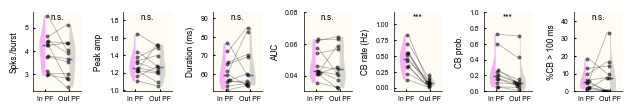

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/ComplexBurstMetrics_CSplus_run.svg


In [24]:
out_path = os.path.join(figure_save_folder, 'ComplexBurstMetrics_CSplus_run.svg')
fig = plot_complex_burst_metrics_csplus(
    plcs_csplus=spatial_data.plcs_csplus,
    save_path=out_path,
    state_key='run',
)
plt.show()
print(f'Saved: {out_path}')


### ComplexBurstMetricDistributions_CSplus_run


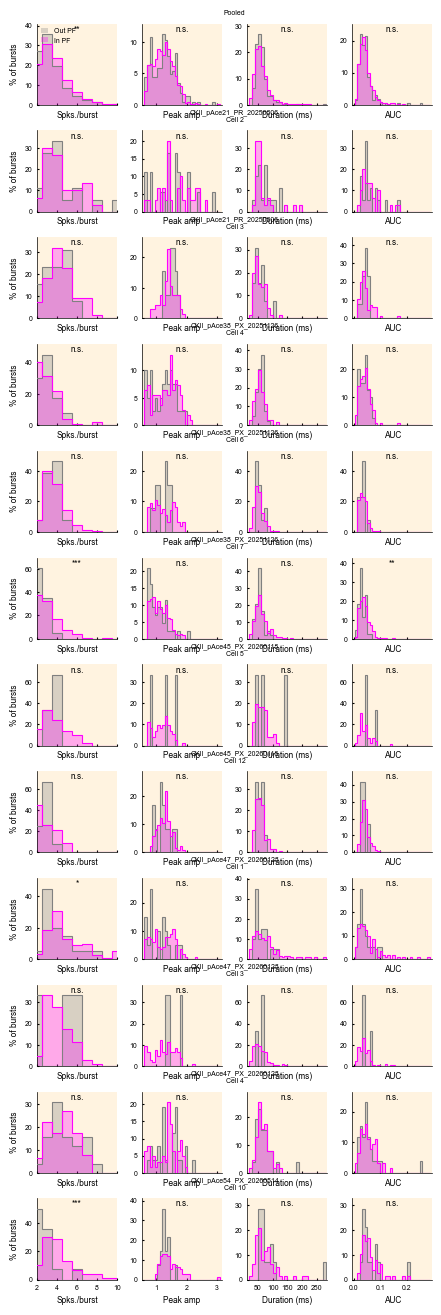

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/ComplexBurstMetricDistributions_CSplus_run.svg


In [25]:
out_path = os.path.join(figure_save_folder, 'ComplexBurstMetricDistributions_CSplus_run.svg')
fig = plot_complex_burst_metric_distributions_csplus(
    plcs_csplus=spatial_data.plcs_csplus,
    save_path=out_path,
    state_key='run',
)
plt.show()
print(f'Saved: {out_path}')


### ComplexBurstMetricDistributions_QuietVsMoving_AllCells


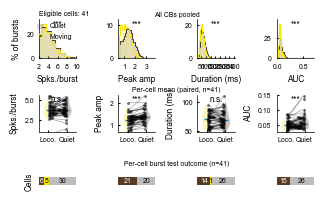

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/ComplexBurstMetricDistributions_QuietVsMoving_AllCells.svg


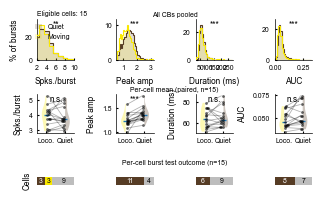

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/ComplexBurstMetricDistributions_QuietVsMoving_CSplusOnly.svg


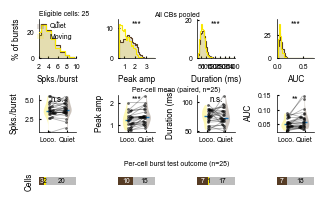

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/ComplexBurstMetricDistributions_QuietVsMoving_NonPLCsOnly.svg


In [26]:
min_bursts_per_state = 5
fig_width = 3.2
fig_height = 2.1

figure_specs = [
    {
        'filename': 'ComplexBurstMetricDistributions_QuietVsMoving_AllCells.svg',
        'plcs_csplus': spatial_data.plcs_csplus,
        'plcs_csminus': spatial_data.plcs_csminus,
        'non_plcs': spatial_data.non_plcs,
    },
    {
        'filename': 'ComplexBurstMetricDistributions_QuietVsMoving_CSplusOnly.svg',
        'plcs_csplus': spatial_data.plcs_csplus,
        'plcs_csminus': [],
        'non_plcs': [],
    },
    {
        'filename': 'ComplexBurstMetricDistributions_QuietVsMoving_NonPLCsOnly.svg',
        'plcs_csplus': [],
        'plcs_csminus': [],
        'non_plcs': spatial_data.non_plcs,
    },
]

for spec in figure_specs:
    out_path = os.path.join(figure_save_folder, spec['filename'])
    fig = plot_complex_burst_metric_distributions_quiet_vs_moving_allcells(
        plcs_csplus=spec['plcs_csplus'],
        plcs_csminus=spec['plcs_csminus'],
        non_plcs=spec['non_plcs'],
        save_path=out_path,
        speed_threshold_cm_s=config.analysis.speed_threshold,
        min_bursts_per_state=min_bursts_per_state,
        plot_mode='hist',
        fig_width=fig_width,
        fig_height=fig_height,
    )
    plt.show()
    print(f'Saved: {out_path}')


### CBrate_correlations_CSplus_InOut_alt

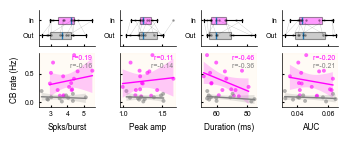

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/CBrate_correlations_CSplus_InOut_alt.svg


In [26]:
out_path = os.path.join(figure_save_folder, 'CBrate_correlations_CSplus_InOut_alt.svg')
fig = plot_cbrate_correlations_csplus_inout_alt(
    plcs_csplus=spatial_data.plcs_csplus,
    save_path=out_path,
)
plt.show()
print(f'Saved: {out_path}')


### theta_inout_loco_csplus_vs_csminus

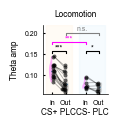

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/theta_inout_loco_csplus_vs_csminus.svg


In [27]:
out_path = os.path.join(figure_save_folder, 'theta_inout_loco_csplus_vs_csminus.svg')
fig = plot_theta_inout_loco_csplus_vs_csminus(
    df_cs_plc=df_cs_plc,
    df_non_cs_plc=df_non_cs_plc,
    save_path=out_path,
    fig_width=1.2,
    fig_height=1.3,
)
plt.show()
print(f'Saved: {out_path}')


### slow_vm_inout_loco_csplus_vs_csminus

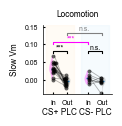

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/slow_vm_inout_loco_csplus_vs_csminus.svg


In [28]:
out_path = os.path.join(figure_save_folder, 'slow_vm_inout_loco_csplus_vs_csminus.svg')
fig = plot_slow_vm_inout_loco_csplus_vs_csminus(
    df_cs_plc=df_cs_plc,
    df_non_cs_plc=df_non_cs_plc,
    save_path=out_path,
    fig_width=1.2,
    fig_height=1.3,
)
plt.show()
print(f'Saved: {out_path}')


# Trial by Trial Analysis, Distance normalized

## Trial by trial plots with distance windowing

In [29]:
distance_centered_params = PFDistanceCenteredParams(
    distance_window_cm=15.0,
    detection_window_cm=10.0,
    distance_bin_cm=1.5,
    distance_mode='cumulative_path',
    center_by_pf_position=True,
    min_traversals=10,
    min_traversals_per_type=10,
    require_full_span=False,
    subtract_pre_traversal_baseline=traversal_params.subtract_pre_traversal_baseline,
    pf_component_selection=traversal_params.pf_component_selection,
    max_pf_distance_cm=traversal_params.max_pf_distance_cm,
    smooth_window=5.0, # cm
    exclude_trials_with_bad_frames=True,
    require_movement=True,
    include_long_cb_as_plateau=True,
    cb_plateau_min_duration_ms=100.0,
)



In [30]:
## Trial by Trial plots + unified distance dataset

distance_defined_distance_window_cm = 15.0 # default 15
distance_defined_detection_window_cm = 8.0
distance_defined_distance_bin_cm = 1.5 # default 1.5
distance_defined_distance_mode = 'euclidean_to_peak'  # alternative: 'euclidean_to_peak'
distance_defined_center_vicinity_min_cm = 1
distance_defined_center_vicinity_max_cm = 5
distance_defined_moving_speed_threshold = float(config.analysis.speed_threshold)
distance_defined_resting_speed_threshold = 0.5
distance_defined_trial_sharey = True
distance_defined_max_plot_trial_duration_s = 20.0
distance_defined_max_trials_per_component_plot = 120  # keep dataset, skip only SVGs above this trial count
distance_defined_print_component_progress = True

distance_defined_categories = ('CSplus', 'CSminus', 'non-PLC')  # e.g. ('non-PLC',) or ('CSplus','CSminus','non-PLC')

# Related to Plateaus
distance_defined_include_long_cb_as_plateau = False
distance_defined_cb_plateau_min_duration_ms = 100.0
distance_defined_plateau_trace_window_ms = 100.0  # symmetric pre/post window around plateau onset
distance_defined_include_resting_plateaus = True
distance_defined_align_all_pf_components_to_session_compare = True
distance_defined_session_compare_cache_version = 'v2'

trial_plot_dilation_bins = 0 #place_cell_params.pf_reliability_dilation_bins  # set 0 for no dilation
trial_plot_dilation_shape = place_cell_params.pf_reliability_dilation_shape  # 'disk' | 'square' | 'manhattan'

distance_defined_unified_result = generate_distance_defined_trials_and_dataset(
    config=config,
    spatial_data=spatial_data,
    distance_params=distance_centered_params,
    figure_save_folder=figure_save_folder,
    distance_window_cm=distance_defined_distance_window_cm,
    detection_window_cm=distance_defined_detection_window_cm,
    distance_bin_cm=distance_defined_distance_bin_cm,
    distance_mode=distance_defined_distance_mode,
    center_vicinity_min_cm=distance_defined_center_vicinity_min_cm,
    center_vicinity_max_cm=distance_defined_center_vicinity_max_cm,
    moving_speed_threshold=distance_defined_moving_speed_threshold,
    resting_speed_threshold=distance_defined_resting_speed_threshold,
    pf_ranks=(1, 2),
    categories=distance_defined_categories,
    clear_output=True,
    save_summary_csv=True,
    show_plots=False,
    show_rest_patches=True,
    pf_reliability_dilation_bins=trial_plot_dilation_bins,
    pf_reliability_dilation_shape=trial_plot_dilation_shape,
    trace_slow_gap=1.0,
    theta_slow_pad_factor=0.05,
    sharey=distance_defined_trial_sharey,
    max_plot_trial_duration_s=distance_defined_max_plot_trial_duration_s,
    include_long_cb_as_plateau=distance_defined_include_long_cb_as_plateau,
    cb_plateau_min_duration_ms=distance_defined_cb_plateau_min_duration_ms,
    plateau_trace_window_ms=distance_defined_plateau_trace_window_ms,
    include_resting_plateaus=distance_defined_include_resting_plateaus,
    align_all_pf_components_to_session_compare=distance_defined_align_all_pf_components_to_session_compare,
    session_compare_cache_version=distance_defined_session_compare_cache_version,
    max_trials_per_component_plot=distance_defined_max_trials_per_component_plot,
    print_component_progress=distance_defined_print_component_progress,
)

distance_defined_trial_summary = distance_defined_unified_result['plot_summary']
distance_centered_dataset = distance_defined_unified_result['dataset']

print('Output folders:')
for cat, out_dir in distance_defined_trial_summary['output_dirs'].items():
    print(f"  {cat}: {out_dir}")
print(f"Summary CSV: {distance_defined_trial_summary['summary_csv']}")
print(distance_defined_trial_summary['counters'])

cats_for_print = tuple(distance_centered_dataset.get('metadata', {}).get('categories', ()))
if len(cats_for_print) == 0:
    cats_for_print = tuple(distance_defined_trial_summary.get('output_dirs', {}).keys())

for cat in cats_for_print:
    cat_data = distance_centered_dataset.get(cat, {})
    p1 = cat_data.get(1, {})
    p2 = cat_data.get(2, {})
    
    print(f"{cat} PF1: {p1.get('n_entries', 0)} entries (skipped={p1.get('n_skipped', 0)})")
    print(f"{cat} PF2: {p2.get('n_entries', 0)} entries (skipped={p2.get('n_skipped', 0)})")

print('Distance-centered metadata:')
print(distance_centered_dataset.get('metadata', {}))


CKII_pAce21_PR_20250806: SNR filter kept 7/9 cells (threshold=5, min_good_minutes=5.0).
[distance-defined] CSplus CKII_pAce21_PR_20250806 Cell2 PF1: computing trials...
[distance-defined] CSplus CKII_pAce21_PR_20250806 Cell2 PF1: computed 10 trials in 0.2s.
[distance-defined] CSplus CKII_pAce21_PR_20250806 Cell2 PF1: plotting 10 trials...


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8449: RuntimeWarning: Mean of empty slice
  "ss_pct_mean": np.nanmean(ss_pct_arr, axis=0) if np.any(np.isfinite(ss_pct_arr)) else np.full(len(distance_rel), np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8450: RuntimeWarning: Mean of empty slice
  "cs_pct_mean": np.nanmean(cs_pct_arr, axis=0) if np.any(np.isfinite(cs_pct_arr)) else np.full(len(distance_rel), np.nan),


Plotted 10 traversal trials (10 with spikes in PF, used for average)
[distance-defined] CSplus CKII_pAce21_PR_20250806 Cell2 PF1: saving /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PF_distance_defined_trials_CSplus_PLCs/CKII_pAce21_PR_20250806_Cell2_PF1_distance_defined_traversal.svg...


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_core.py:12035: RuntimeWarning: invalid value encountered in divide
  ss_pct = np.where(valid, 100.0 * ss_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_core.py:12036: RuntimeWarning: invalid value encountered in divide
  cs_pct = np.where(valid, 100.0 * cs_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_core.py:12046: RuntimeWarning: Mean of empty slice
  pf_ss_pct_mean = np.nanmean(ss_pct_stack, axis=0) if include_pf_pct else None
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_core.py:12047: RuntimeWarning: Mean of empty slice
  pf_cs_pct_mean = np.nanmean(cs_pct_stack, axis=0) if include_pf_pct else None
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-pac

[distance-defined] CSplus CKII_pAce21_PR_20250806 Cell2 PF1: saved (1.3s plot, 0.7s save).
[distance-defined] CSplus CKII_pAce21_PR_20250806 Cell3 PF1: computing trials...
[distance-defined] CSplus CKII_pAce21_PR_20250806 Cell3 PF1: computed 12 trials in 0.2s.
[distance-defined] CSplus CKII_pAce21_PR_20250806 Cell3 PF1: plotting 12 trials...
Plotted 12 traversal trials (11 with spikes in PF, used for average)
[distance-defined] CSplus CKII_pAce21_PR_20250806 Cell3 PF1: saving /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PF_distance_defined_trials_CSplus_PLCs/CKII_pAce21_PR_20250806_Cell3_PF1_distance_defined_traversal.svg...
[distance-defined] CSplus CKII_pAce21_PR_20250806 Cell3 PF1: saved (0.9s plot, 0.5s save).
CKII_pAce38_PX_20251126: SNR filter kept 7/9 cells (threshold=5, min_good_minutes=5.0).
[distance-defined] CSplus CKII_pAce38_PX_20251126 Cell4 PF1: computing trials...
[distance-defined] CSplus CKII_pAce38_PX_2025

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8444: RuntimeWarning: Mean of empty slice
  "theta_mean": np.nanmean(theta_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8445: RuntimeWarning: Mean of empty slice
  "slow_mean": np.nanmean(slow_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8446: RuntimeWarning: Mean of empty slice
  "rate_mean": np.nanmean(rate_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8447: RuntimeWarning: Mean of empty slice
  "ss_rate_mean": np.nanmean(ss_rate_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8448: RuntimeWarning: Mean of empty slice
  "cs_rate_mean": np.nanmea

Plotted 27 traversal trials (22 with spikes in PF, used for average)
[distance-defined] CSplus CKII_pAce47_PX_20260128 Cell3 PF1: saving /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PF_distance_defined_trials_CSplus_PLCs/CKII_pAce47_PX_20260128_Cell3_PF1_distance_defined_traversal.svg...
[distance-defined] CSplus CKII_pAce47_PX_20260128 Cell3 PF1: saved (1.3s plot, 1.3s save).
[distance-defined] CSplus CKII_pAce47_PX_20260128 Cell4 PF1: computing trials...
[distance-defined] CSplus CKII_pAce47_PX_20260128 Cell4 PF1: computed 25 trials in 0.4s.
[distance-defined] CSplus CKII_pAce47_PX_20260128 Cell4 PF1: plotting 25 trials...
Plotted 25 traversal trials (25 with spikes in PF, used for average)
[distance-defined] CSplus CKII_pAce47_PX_20260128 Cell4 PF1: saving /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PF_distance_defined_trials_CSplus_PLCs/CKII_pAce47_PX_2026012

Distance-centered trial counts by category and PF rank (per cell):
Included minutes are computed from the actual framewise bad mask used by analysis, not from first SNR drop.

CSplus:
  CKII_pAce21_PR_20250806 Cell2: PF1 trials=10, PF2 trials=0, included=9.65 min, last included timepoint=9.80 min, manual cutoff=9.98 min, first SNR<5=none (all frames pass SNR threshold)
  CKII_pAce21_PR_20250806 Cell3: PF1 trials=12, PF2 trials=0, included=9.45 min, last included timepoint=9.79 min, manual cutoff=9.98 min, first SNR<5=none (all frames pass SNR threshold)
  CKII_pAce38_PX_20251126 Cell4: PF1 trials=29, PF2 trials=0, included=19.89 min, last included timepoint=19.92 min, manual cutoff=19.92 min, first SNR<5=none (all frames pass SNR threshold)
  CKII_pAce38_PX_20251126 Cell6: PF1 trials=41, PF2 trials=25, included=19.89 min, last included timepoint=19.92 min, manual cutoff=19.92 min, first SNR<5=none (all frames pass SNR threshold)
  CKII_pAce38_PX_20251126 Cell7: PF1 trials=26, PF2 trial

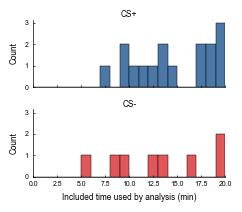

In [31]:
import numpy as np

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    import pickle
    from pathlib import Path

    _inclusion_cache = {}

    def _load_distance_inclusion_payload(session_name):
        if session_name in _inclusion_cache:
            return _inclusion_cache[session_name]
        animal_dir = Path(config.data_root) / str(session_name)
        try:
            merged = _pcp._load_merged_data(animal_dir, config)
        except Exception:
            merged = None
        sidecar = None
        sidecar_path = animal_dir / 'manual_spike_detection_results.pkl'
        if sidecar_path.exists():
            try:
                with sidecar_path.open('rb') as f:
                    sidecar = pickle.load(f)
            except Exception:
                sidecar = None
        bad_masks = None
        mask_stats = None
        if isinstance(merged, dict):
            try:
                bad_masks, mask_stats = _pcp._compute_bad_masks(
                    merged,
                    float(config.analysis.snr_threshold),
                    float(config.analysis.min_good_minutes),
                    return_stats=True,
                )
            except Exception:
                bad_masks = None
                mask_stats = None
        _inclusion_cache[session_name] = {
            "merged": merged,
            "sidecar": sidecar,
            "bad_masks": bad_masks,
            "mask_stats": mask_stats,
        }
        return _inclusion_cache[session_name]

    def _manual_cutoff_min(session_name, cell_idx, merged, sidecar, mask_stats, frame_rate, n_frames):
        manual_cutoff_s = np.nan
        if isinstance(sidecar, dict):
            cells = sidecar.get("cells", {})
            cell_rec = None
            if isinstance(cells, dict):
                cell_rec = cells.get(str(int(cell_idx)), cells.get(int(cell_idx)))
            if isinstance(cell_rec, dict):
                try:
                    manual_cutoff_s = float(cell_rec.get("snr_acceptable_until_s", np.nan))
                except Exception:
                    manual_cutoff_s = np.nan
        if not np.isfinite(manual_cutoff_s) and isinstance(mask_stats, list):
            if int(cell_idx) < len(mask_stats) and isinstance(mask_stats[int(cell_idx)], dict):
                try:
                    manual_cutoff_s = float(mask_stats[int(cell_idx)].get("manual_snr_acceptable_until_s", np.nan))
                except Exception:
                    manual_cutoff_s = np.nan
        if np.isfinite(manual_cutoff_s):
            return float(np.clip(manual_cutoff_s, 0.0, n_frames / frame_rate) / 60.0)
        return float(n_frames / frame_rate / 60.0)

    def _get_cell_snr_values(merged, cell_idx, n_frames):
        snr_source = merged.get("SNR_interpolated", []) if isinstance(merged, dict) else []
        try:
            if isinstance(snr_source, (list, tuple)):
                if int(cell_idx) < len(snr_source):
                    return np.asarray(snr_source[int(cell_idx)], dtype=float).reshape(-1)
            else:
                snr_arr = np.asarray(snr_source, dtype=float)
                if snr_arr.ndim == 2 and snr_arr.shape[0] > int(cell_idx) and snr_arr.shape[1] == n_frames:
                    return snr_arr[int(cell_idx), :].reshape(-1)
                if snr_arr.ndim == 2 and snr_arr.shape[1] > int(cell_idx) and snr_arr.shape[0] == n_frames:
                    return snr_arr[:, int(cell_idx)].reshape(-1)
        except Exception:
            pass
        return np.array([], dtype=float)

    def _cell_analysis_inclusion_minutes(session_name, cell_idx):
        payload = _load_distance_inclusion_payload(session_name)
        merged = payload.get("merged")
        sidecar = payload.get("sidecar")
        bad_masks = payload.get("bad_masks")
        mask_stats = payload.get("mask_stats")
        out = {
            "manual_cutoff_min": np.nan,
            "first_snr_low_min": np.nan,
            "included_minutes": np.nan,
            "max_included_timepoint_min": np.nan,
            "included_frames": 0,
            "n_frames": 0,
            "snr_note": "unavailable",
        }
        if not isinstance(merged, dict):
            return out
        frame_rate = float(merged.get("frame_rate", np.nan))
        n_frames = int(merged.get("n_frames", 0) or len(np.asarray(merged.get("x_neural", []))))
        out["n_frames"] = int(n_frames)
        if not np.isfinite(frame_rate) or frame_rate <= 0 or n_frames <= 0:
            return out
        duration_min = float(n_frames) / frame_rate / 60.0
        out["manual_cutoff_min"] = _manual_cutoff_min(
            session_name, cell_idx, merged, sidecar, mask_stats, frame_rate, n_frames
        )

        snr_vals = _get_cell_snr_values(merged, cell_idx, n_frames)
        if snr_vals.ndim == 1 and snr_vals.size == n_frames:
            snr_good = np.isfinite(snr_vals) & (snr_vals >= float(config.analysis.snr_threshold))
            low_idx = np.flatnonzero(~snr_good)
            if low_idx.size:
                first_low = int(low_idx[0])
                out["first_snr_low_min"] = float(first_low / frame_rate / 60.0)
                out["snr_note"] = "first low-SNR frame; later SNR recovers" if np.any(snr_good[first_low:]) else "first low-SNR frame"
            else:
                out["first_snr_low_min"] = np.nan
                out["snr_note"] = "all frames pass SNR threshold"
        else:
            out["snr_note"] = "SNR_interpolated unavailable"

        bad_mask = None
        if isinstance(bad_masks, np.ndarray) and bad_masks.ndim == 2:
            if int(cell_idx) < bad_masks.shape[0] and bad_masks.shape[1] == n_frames:
                bad_mask = np.asarray(bad_masks[int(cell_idx)], dtype=bool)
        if bad_mask is None:
            return out
        good_mask = ~bad_mask
        included_frames = int(np.sum(good_mask))
        out["included_frames"] = included_frames
        out["included_minutes"] = float(included_frames) / frame_rate / 60.0
        good_idx = np.flatnonzero(good_mask)
        if good_idx.size:
            out["max_included_timepoint_min"] = float(good_idx[-1] / frame_rate / 60.0)
        else:
            out["max_included_timepoint_min"] = 0.0
        return out

    included_minutes_by_category = {}

    print("Distance-centered trial counts by category and PF rank (per cell):")
    print("Included minutes are computed from the actual framewise bad mask used by analysis, not from first SNR drop.")
    for cat in ["CSplus", "CSminus"]:
        cat_block = distance_centered_dataset.get(cat, {})
        pf1_entries = list(cat_block.get(1, {}).get("entries", []))
        pf2_entries = list(cat_block.get(2, {}).get("entries", []))

        pf1_by_key = {}
        for e in pf1_entries:
            key = (str(e.get("session", "")), int(e.get("cell_idx", -1)))
            n = e.get("data", {}).get("all", {}).get("n_trials", 0)
            try:
                pf1_by_key[key] = int(n)
            except Exception:
                pf1_by_key[key] = 0

        pf2_by_key = {}
        for e in pf2_entries:
            key = (str(e.get("session", "")), int(e.get("cell_idx", -1)))
            n = e.get("data", {}).get("all", {}).get("n_trials", 0)
            try:
                pf2_by_key[key] = int(n)
            except Exception:
                pf2_by_key[key] = 0

        all_keys = sorted(set(pf1_by_key.keys()) | set(pf2_by_key.keys()), key=lambda x: (x[0], x[1]))

        print(f"\n{cat}:")
        total_pf1 = 0
        total_pf2 = 0
        included_values = []
        for session_name, cell_idx in all_keys:
            n1 = int(pf1_by_key.get((session_name, cell_idx), 0))
            n2 = int(pf2_by_key.get((session_name, cell_idx), 0))
            total_pf1 += n1
            total_pf2 += n2
            inc = _cell_analysis_inclusion_minutes(session_name, cell_idx)
            if np.isfinite(inc["included_minutes"]):
                included_values.append(float(inc["included_minutes"]))
            first_snr_str = "none" if not np.isfinite(inc["first_snr_low_min"]) else f"{inc['first_snr_low_min']:.2f} min"
            print(
                f"  {session_name} Cell{cell_idx + 1}: "
                f"PF1 trials={n1}, PF2 trials={n2}, "
                f"included={inc['included_minutes']:.2f} min, "
                f"last included timepoint={inc['max_included_timepoint_min']:.2f} min, "
                f"manual cutoff={inc['manual_cutoff_min']:.2f} min, "
                f"first SNR<{float(config.analysis.snr_threshold):g}={first_snr_str}"
                f" ({inc['snr_note']})"
            )

        included_minutes_by_category[cat] = np.asarray(included_values, dtype=float)
        print(f"  Total: PF1 trials={total_pf1}, PF2 trials={total_pf2}")
        print(f"  n_cells listed={len(all_keys)}")

    # Distribution of actual included minutes by category.
    csplus_included = included_minutes_by_category.get("CSplus", np.array([], dtype=float))
    csminus_included = included_minutes_by_category.get("CSminus", np.array([], dtype=float))
    all_included = np.concatenate([
        csplus_included[np.isfinite(csplus_included)],
        csminus_included[np.isfinite(csminus_included)],
    ]) if (csplus_included.size or csminus_included.size) else np.array([], dtype=float)

    if all_included.size:
        bins = np.arange(0.0, 20.0 + 1.0, 1.0)
        fig, axes = plt.subplots(2, 1, figsize=(2.4, 2.1), sharex=True, sharey=True)
        for ax, label, values, color in [
            (axes[0], "CS+", csplus_included, "#4C78A8"),
            (axes[1], "CS-", csminus_included, "#E15759"),
        ]:
            values = values[np.isfinite(values)]
            ax.hist(values, bins=bins, color=color, edgecolor="black", linewidth=0.35)
            ax.set_ylabel("Count")
            ax.set_title(label, pad=2)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(width=0.5)
        axes[1].set_xlabel("Included time used by analysis (min)")
        axes[1].set_xlim(0.0, 20.0)
        fig.tight_layout()
        _included_minutes_path = Path(figure_save_folder) / "DistanceCentered_IncludedMinutes_Distribution.svg"
        fig.savefig(_included_minutes_path, dpi=300)
        print(f"Included minutes distribution saved: {_included_minutes_path}")
        plt.show()
    else:
        print("No finite included-minute values available to plot.")

## Compare Sessions


### Heatmaps comparing two sessions

In [84]:
smooth_window = 3.0 # cm
avg_smooth_window = 0.0 # cm
max_peak_adjust_cm_pf1 = 6.0 # cm
max_peak_adjust_cm_pf2 = 6.0 # cm
distance_centered_display_xlim = (-12.0, 12.0)

two_session_split_mode = 'time_windows'
two_session_split_window_minutes = 10.0  # set to 5.0 for first/second 5 min windows

In [85]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    distance_heatmap_summary_2sessions = generate_pf_distance_centered_component_heatmaps_2sessions(
        dataset=distance_centered_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        interpolate_nan=True,
        smooth_window=smooth_window,
        fr_vmax_scale=0.1,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=1,
        subplot_width=0.4,
        heatmap_height=0.36,
        avg_height=0.1,
        xlim=distance_centered_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=avg_smooth_window,
        max_peak_adjust_cm_pf1=max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=max_peak_adjust_cm_pf2,
        avg_ylim_focus_window=(-1.0, 1.0),
        disable_pf2_avg_ylim_sync=True,
        split_mode=two_session_split_mode,
        split_window_minutes=two_session_split_window_minutes,
        print_peak_shift_bins=True,
        show_plot=False,
        rate_colorbar_vmax=10,  # set row-1 all-spike heatmap/colorbar max directly
        Plot_plateaus=True,
        plateau_height_per_spkh=0.05,
    )

    for cat, info in distance_heatmap_summary_2sessions.items():
        print(f"{cat} folder (2 sessions): {info['output_dir']}")
        print(f"{cat} summary (2 sessions): {info}")


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:16206: RuntimeWarning: Mean of empty slice
  np.asarray(np.nanmean(ss_pct_stack, axis=0), dtype=float)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:16212: RuntimeWarning: Mean of empty slice
  np.asarray(np.nanmean(cs_pct_stack, axis=0), dtype=float)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:16195: RuntimeWarning: Mean of empty slice
  out[mean_key] = np.asarray(np.nanmean(stack, axis=0), dtype=float)


[CSplus] per-cell peak shifts (distance bin = 1.5 cm):
  CKII_pAce21_PR_20250806 Cell 2: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce21_PR_20250806 Cell 3: PF1=+1 bins (+1.50 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 4: PF1=-2 bins (-3.00 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 6: PF1=+2 bins (+3.00 cm), PF2=-2 bins (-3.00 cm)
  CKII_pAce38_PX_20251126 Cell 7: PF1=+0 bins (+0.00 cm), PF2=+0 bins (+0.00 cm)
  CKII_pAce45_PX_20260118 Cell 5: PF1=-1 bins (-1.50 cm), PF2=NA
  CKII_pAce45_PX_20260118 Cell 12: PF1=-4 bins (-6.00 cm), PF2=NA
  CKII_pAce47_PX_20260128 Cell 1: PF1=-2 bins (-3.00 cm), PF2=-1 bins (-1.50 cm)
  CKII_pAce47_PX_20260128 Cell 3: PF1=-4 bins (-6.00 cm), PF2=NA
  CKII_pAce47_PX_20260128 Cell 4: PF1=-1 bins (-1.50 cm), PF2=+0 bins (+0.00 cm)
  CKII_pAce50_PRL_20260317 Cell 9: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce54_PR_20260506 Cell 4: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce54_PR_20260506 Cell 10: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce54_PR_20260506 Cell 14

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:19734: RuntimeWarning: Mean of empty slice
  trace = np.asarray(np.nanmean(stack, axis=0), dtype=float)
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[CSplus] 2/16 saved: CKII_pAce21_PR_20250806_Cell3_heatmap_2sessions.svg
[CSplus] 3/16 saved: CKII_pAce38_PX_20251126_Cell4_heatmap_2sessions.svg
[CSplus] 4/16 saved: CKII_pAce38_PX_20251126_Cell6_heatmap_2sessions.svg
[CSplus] 5/16 saved: CKII_pAce38_PX_20251126_Cell7_heatmap_2sessions.svg
[CSplus] 6/16 saved: CKII_pAce45_PX_20260118_Cell5_heatmap_2sessions.svg
[CSplus] 7/16 saved: CKII_pAce45_PX_20260118_Cell12_heatmap_2sessions.svg
[CSplus] 8/16 saved: CKII_pAce47_PX_20260128_Cell1_heatmap_2sessions.svg
[CSplus] 9/16 saved: CKII_pAce47_PX_20260128_Cell3_heatmap_2sessions.svg
[CSplus] 10/16 saved: CKII_pAce47_PX_20260128_Cell4_heatmap_2sessions.svg
[CSplus] 11/16 saved: CKII_pAce50_PRL_20260317_Cell9_heatmap_2sessions.svg
[CSplus] 12/16 saved: CKII_pAce54_PR_20260506_Cell4_heatmap_2sessions.svg
[CSplus] 13/16 saved: CKII_pAce54_PR_20260506_Cell10_heatmap_2sessions.svg
[CSplus] 14/16 saved: CKII_pAce54_PR_20260506_Cell14_heatmap_2sessions.svg
[CSplus] 15/16 saved: CKII_pAce54_PX_20260

In [86]:
# Trial-count diagnostics from 2-session average exports
import pandas as pd
from pathlib import Path

trial_count_threshold = 4
export_root_2sessions = Path(figure_save_folder) / 'pf_distance_centered_2sessions_average_exports'

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    for cat in ("CSplus", "CSminus"):
        index_csv = export_root_2sessions / cat / 'session_averages_pre_post_index.csv'
        print(f"\n[{cat}] export index: {index_csv}")
        if not index_csv.exists():
            print("  Missing export index CSV. Run generate_pf_distance_centered_component_heatmaps_2sessions first.")
            continue

        df = pd.read_csv(index_csv)
        required_cols = [
            'animal_id', 'cell_idx', 'cell_num',
            'n_trials_pf1_s1', 'n_trials_pf1_s2', 'n_trials_pf2_s1', 'n_trials_pf2_s2',
        ]
        missing = [c for c in required_cols if c not in set(df.columns)]
        if len(missing) > 0:
            print(f"  Missing columns in export CSV: {missing}")
            continue

        for c in ['n_trials_pf1_s1', 'n_trials_pf1_s2', 'n_trials_pf2_s1', 'n_trials_pf2_s2', 'cell_num', 'cell_idx']:
            df[c] = pd.to_numeric(df[c], errors='coerce')

        df = df.sort_values(['animal_id', 'cell_num', 'cell_idx'], na_position='last').reset_index(drop=True)

        print("  Per-cell trial counts:")
        for _, r in df.iterrows():
            cell_label = int(r['cell_num']) if pd.notna(r['cell_num']) else int(r['cell_idx']) + 1
            print(
                f"    {r['animal_id']}_Cell{cell_label}: "
                f"PF1 S1={int(r['n_trials_pf1_s1']) if pd.notna(r['n_trials_pf1_s1']) else 'NaN'}, "
                f"PF1 S2={int(r['n_trials_pf1_s2']) if pd.notna(r['n_trials_pf1_s2']) else 'NaN'}, "
                f"PF2 S1={int(r['n_trials_pf2_s1']) if pd.notna(r['n_trials_pf2_s1']) else 'NaN'}, "
                f"PF2 S2={int(r['n_trials_pf2_s2']) if pd.notna(r['n_trials_pf2_s2']) else 'NaN'}"
            )

        pf1_both = ((df['n_trials_pf1_s1'] >= trial_count_threshold) & (df['n_trials_pf1_s2'] >= trial_count_threshold)).sum()
        pf2_both = ((df['n_trials_pf2_s1'] >= trial_count_threshold) & (df['n_trials_pf2_s2'] >= trial_count_threshold)).sum()
        print(f"  Summary (>={trial_count_threshold} in both sessions): PF1={int(pf1_both)}, PF2={int(pf2_both)}")



[CSplus] export index: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_2sessions_average_exports/CSplus/session_averages_pre_post_index.csv
  Per-cell trial counts:
    CKII_pAce21_PR_20250806_Cell2: PF1 S1=10, PF1 S2=0, PF2 S1=0, PF2 S2=0
    CKII_pAce21_PR_20250806_Cell3: PF1 S1=12, PF1 S2=0, PF2 S1=0, PF2 S2=0
    CKII_pAce38_PX_20251126_Cell4: PF1 S1=14, PF1 S2=15, PF2 S1=0, PF2 S2=0
    CKII_pAce38_PX_20251126_Cell6: PF1 S1=17, PF1 S2=24, PF2 S1=19, PF2 S2=6
    CKII_pAce38_PX_20251126_Cell7: PF1 S1=19, PF1 S2=7, PF2 S1=18, PF2 S2=27
    CKII_pAce45_PX_20260118_Cell5: PF1 S1=21, PF1 S2=18, PF2 S1=0, PF2 S2=0
    CKII_pAce45_PX_20260118_Cell12: PF1 S1=25, PF1 S2=14, PF2 S1=0, PF2 S2=0
    CKII_pAce47_PX_20260128_Cell1: PF1 S1=22, PF1 S2=8, PF2 S1=21, PF2 S2=4
    CKII_pAce47_PX_20260128_Cell3: PF1 S1=20, PF1 S2=7, PF2 S1=0, PF2 S2=0
    CKII_pAce47_PX_20260128_Cell4: PF1 S1=22, PF1 S2=3, PF2 S1=16, PF2

### Average Plot, comparing two sessisons

PF FR norm denominator mode=zero: zero=8, peak fallback=0, invalid=0


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:20463: RuntimeWarning: Mean of empty slice
  return np.nanmean(stack, axis=0)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:19734: RuntimeWarning: Mean of empty slice
  trace = np.asarray(np.nanmean(stack, axis=0), dtype=float)
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


PF FR norm denominator mode=zero: zero=4, peak fallback=0, invalid=0
[CS+ PLCs] n (PF1): combined=8, S1=8, S2=8
[CS+ PLCs] n (PF2): combined=4, S1=4, S2=4


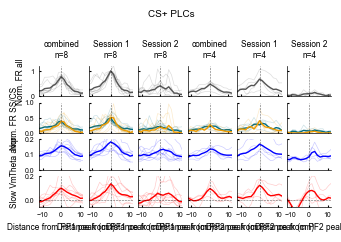

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_CSplus_average_primary_secondary_2sessions.svg
PF FR norm denominator mode=zero: zero=4, peak fallback=0, invalid=0
PF FR norm denominator mode=zero: zero=1, peak fallback=0, invalid=0
[CS- PLCs] n (PF1): combined=4, S1=4, S2=4
[CS- PLCs] n (PF2): combined=1, S1=1, S2=1


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:19815: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)


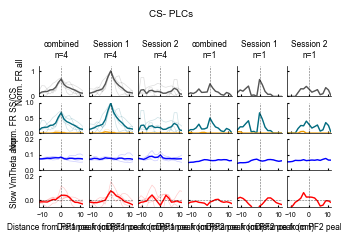

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_CSminus_average_primary_secondary_2sessions.svg


In [87]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    # Shared parameters for both CS+ and CS- 2-session average plots
    pf_avg_fr_row_ylim_max = 1.2
    min_trials_per_column_2sessions = 4  # include only if n_trials >= this threshold in that column
    average_export_dir_2sessions = os.path.join(figure_save_folder, 'pf_distance_centered_2sessions_average_exports')
    distance_session_average_export_stage = 'post'
    distance_session_enforce_min_traversals_on_saved_exports = False
    distance_session_fr_norm_reference_col = 'session1'
    distance_session_fr_norm_denominator_mode = 'zero'

    common_plot_kwargs = dict(
        smooth_window=smooth_window,
        plot_trials=True,
        trial_alpha=0.2,
        trial_linewidth=0.5,
        theta_ylim=(0, 0.2),
        slow_ylim=(-0.05, 0.2),
        fr_ylim_scale=1.2,
        ss_cs_ylim_scale=1.2,
        figsize_per_block=(3.4, 1.8),
        xlim=distance_centered_display_xlim,
        fr_row_ylim_max=pf_avg_fr_row_ylim_max,
        show_plot=True,
        max_peak_adjust_cm_pf1=max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=max_peak_adjust_cm_pf2,
        min_traversals_per_type=distance_centered_params.min_traversals_per_type,
        min_trials_per_column=min_trials_per_column_2sessions,
        use_saved_average_exports=True,
        average_export_dir=average_export_dir_2sessions,
        average_export_stage=distance_session_average_export_stage,
        enforce_min_traversals_on_saved_exports=distance_session_enforce_min_traversals_on_saved_exports,
        fr_norm_reference_col=distance_session_fr_norm_reference_col,
        fr_norm_denominator_mode=distance_session_fr_norm_denominator_mode,
        show_sem_shading=False,
        split_mode=two_session_split_mode,
        split_window_minutes=two_session_split_window_minutes,
    )

    plot_specs_2sessions = [
        ('CSplus', 'CS+ PLCs', 'pf_distance_centered_CSplus_average_primary_secondary_2sessions.svg'),
        ('CSminus', 'CS- PLCs', 'pf_distance_centered_CSminus_average_primary_secondary_2sessions.svg'),
    ]

    for category_name, title_text, filename in plot_specs_2sessions:
        out_path = os.path.join(figure_save_folder, filename)
        plot_pf_distance_centered_category_primary_secondary_from_dataset_2sessions(
            dataset=distance_centered_dataset,
            category=category_name,
            title=title_text,
            out_path=out_path,
            **common_plot_kwargs,
        )
        print(f'Generated: {out_path}')


### Statistics

In [88]:
### Stability
stability_min_traversals_per_session = 0
stability_smooth_window_cm = 0.0
stability_auc_window_cm = None
stability_slow_auc_window_cm = (-10.0, 10.0)
stability_min_trials_per_column_2sessions = min_trials_per_column_2sessions
stability_average_export_dir_2sessions = average_export_dir_2sessions
stability_figsize = None  # e.g. (5.0, 6.5)
stability_row_height = 1.2
stability_figsize = (4.2, 2.3)  

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    stability_results = compute_pf_distance_centered_session_stability(
        distance_centered_dataset,
        min_traversals_per_session=stability_min_traversals_per_session,
        smooth_window_cm=stability_smooth_window_cm,
        auc_window_cm=stability_auc_window_cm,
        slow_auc_window_cm=stability_slow_auc_window_cm,
        min_trials_per_column_2sessions=stability_min_trials_per_column_2sessions,
        average_export_dir=stability_average_export_dir_2sessions,
        split_mode=two_session_split_mode,
        split_window_minutes=two_session_split_window_minutes,
        strict_follow_plot_inclusion=True,
        print_nan_diagnostics=True,
    )

    print(f"Skipped counts: {stability_results.get('skipped_counts', {})}")

    per_cell_stability = stability_results.get("per_cell_stability", None)
    if per_cell_stability is not None and len(per_cell_stability) > 0:
        print("\nDisplayed cell counts by metric/group:")
        count_cols = {
            "r": "r",
            "spearman": "spearman_r",
            "cosine": "cosine_similarity",
            "peak_shift": "delta_peak_x_cm",
            "auc_ratio": "auc_ratio",
        }
        for metric_name in ["all_spike", "ss", "cs", "theta", "slow"]:
            sub_metric = per_cell_stability[per_cell_stability["metric"] == metric_name].copy()
            if len(sub_metric) == 0:
                continue
            print(f"  {metric_name}:")
            for stat_label, stat_col in count_cols.items():
                if stat_col not in set(sub_metric.columns):
                    continue
                sub_stat = sub_metric.copy()
                if stat_col == "delta_peak_x_cm":
                    sub_stat[stat_col] = sub_stat[stat_col].abs()
                sub_stat = sub_stat[sub_stat[stat_col].notna()]
                # CS row is plotted without CS- PF1 in the current figure.
                if metric_name == "cs":
                    sub_stat = sub_stat[sub_stat["group"].isin(["CSplus_PF1", "CSplus_PF2"])]
                sub_stat["cell_key"] = (
                    sub_stat["animal_id"].astype(str) + "::" + sub_stat["cell_idx"].astype(int).astype(str)
                )
                counts = (
                    sub_stat.groupby("group")["cell_key"]
                    .nunique()
                    .reindex(["CSplus_PF1", "CSplus_PF2", "CSminus_PF1"])
                    .fillna(0)
                    .astype(int)
                )
                print(
                    f"    {stat_label}: "
                    f"CS+ PF1={counts.get('CSplus_PF1', 0)}, "
                    f"CS+ PF2={counts.get('CSplus_PF2', 0)}, "
                    f"CS- PF1={counts.get('CSminus_PF1', 0)}"
                )

    stability_plot_summary = plot_pf_distance_centered_session_stability(
        stability_results,
        figure_save_folder=figure_save_folder,
        figsize=stability_figsize,
        row_height=stability_row_height,
        show_plot=False,
        save_csv=True, 
    )

    print("Stability outputs:")
    print(f"  Per-cell CSV: {stability_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {stability_plot_summary.get('stats_csv')}")
    for metric_name, fig_path in stability_plot_summary.get('figure_paths', {}).items():
        print(f"  {metric_name}: {fig_path}")


[session_stability] Cells/metrics with NaN values (flat/invalid traces):
  group=CSplus_PF1, metric=cs, cell=CKII_pAce47_PX_20260128_Cell3, n_s1=20, n_s2=7, overlap_bins=18, spearman_bins=18, cosine_bins=18, auc_bins=18, peak_bins=13, reasons=r:flat_trace_session2; r_set_to_zero; spearman:flat_trace_session2; spearman_set_to_zero
  group=CSplus_PF2, metric=cs, cell=CKII_pAce47_PX_20260128_Cell1, n_s1=21, n_s2=4, overlap_bins=21, spearman_bins=21, cosine_bins=21, auc_bins=21, peak_bins=13, reasons=r:flat_trace_session2; r_set_to_zero; spearman:flat_trace_session2; spearman_set_to_zero
  group=CSplus_PF2, metric=cs, cell=CKII_pAce47_PX_20260128_Cell4, n_s1=16, n_s2=4, overlap_bins=21, spearman_bins=21, cosine_bins=21, auc_bins=21, peak_bins=13, reasons=r:flat_trace_session2; r_set_to_zero; spearman:flat_trace_session2; spearman_set_to_zero
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell5, n_s1=18, n_s2=24, overlap_bins=21, spearman_bins=21, cosine_bins=21, auc_bins=21, 

In [89]:
### CS+ PF1/PF2 delta and width
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)

delta_width_min_traversals_per_session = 0
delta_width_smooth_window_cm = 0.0
delta_width_min_peak_rate_hz = 1.0
delta_width_min_trials_per_column_2sessions = min_trials_per_column_2sessions
delta_width_average_export_dir_2sessions = average_export_dir_2sessions
delta_width_figsize = (3.8, 2.5)
delta_width_row_height = 2.2

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    delta_width_results = _pcp.compute_csplus_pf_distance_centered_session_delta_width(
        distance_centered_dataset,
        min_traversals_per_session=delta_width_min_traversals_per_session,
        smooth_window_cm=delta_width_smooth_window_cm,
        width_min_peak_rate_hz=delta_width_min_peak_rate_hz,
        min_trials_per_column_2sessions=delta_width_min_trials_per_column_2sessions,
        average_export_dir=delta_width_average_export_dir_2sessions,
        split_mode=two_session_split_mode,
        split_window_minutes=two_session_split_window_minutes,
        strict_follow_plot_inclusion=True,
    )

    print(f"Skipped counts: {delta_width_results.get('skipped_counts', {})}")
    print(
        "Cell counts: "
        f"PF1={delta_width_results.get('n_cells_pf1', 0)}, "
        f"PF2={delta_width_results.get('n_cells_pf2', 0)}, "
        f"overlap={delta_width_results.get('n_cells_with_pf1_pf2', 0)}"
    )

    count_summary = delta_width_results.get("count_summary", {})
    if len(count_summary) > 0:
        print("\nDisplayed counts by metric:")
        label_map = {
            "all_spike_delta_fr_s2_s1_over_s1": "all-spike (S2-S1)/S1",
            "all_spike_fwhm_s1_cm": "all-spike width S1",
            "all_spike_fwhm_s2_cm": "all-spike width S2",
            "ss_fwhm_s1_cm": "SS width S1",
            "ss_fwhm_s2_cm": "SS width S2",
            "cs_fwhm_s1_cm": "CS width S1",
            "cs_fwhm_s2_cm": "CS width S2",
        }
        ordered_keys = [
            "all_spike_delta_fr_s2_s1_over_s1",
            "all_spike_fwhm_s1_cm",
            "all_spike_fwhm_s2_cm",
            "ss_fwhm_s1_cm",
            "ss_fwhm_s2_cm",
            "cs_fwhm_s1_cm",
            "cs_fwhm_s2_cm",
        ]
        for category_name, category_label in [("CSplus", "CS+"), ("CSminus", "CS-")]:
            print(f"  {category_label}:")
            for key in ordered_keys:
                counts = count_summary.get(f"{category_name}::{key}", {})
                print(
                    f"    {label_map.get(key, key)}: "
                    f"PF1={counts.get('PF1', 0)}, "
                    f"PF2={counts.get('PF2', 0)}, "
                    f"paired={counts.get('paired', 0)}"
                )

    delta_width_plot_summary = _pcp.plot_csplus_pf_distance_centered_session_delta_width(
        delta_width_results,
        figure_save_folder=figure_save_folder,
        figsize=delta_width_figsize,
        row_height=delta_width_row_height,
        show_plot=False,
        save_csv=True,
    )

    print("Delta-and-width outputs:")
    print(f"  Per-cell CSV: {delta_width_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {delta_width_plot_summary.get('stats_csv')}")
    print(f"  Figure: {delta_width_plot_summary.get('figure_path')}")


Skipped counts: {'missing': 0, 'insufficient_sessions': 0, 'low_traversals': 31}
Cell counts: PF1=12, PF2=5, overlap=4

Displayed counts by metric:
  CS+:
    all-spike (S2-S1)/S1: PF1=3, PF2=3, paired=3
    all-spike width S1: PF1=8, PF2=4, paired=0
    all-spike width S2: PF1=8, PF2=4, paired=0
    SS width S1: PF1=7, PF2=3, paired=0
    SS width S2: PF1=7, PF2=3, paired=0
    CS width S1: PF1=7, PF2=2, paired=0
    CS width S2: PF1=7, PF2=2, paired=0
  CS-:
    all-spike (S2-S1)/S1: PF1=1, PF2=1, paired=1
    all-spike width S1: PF1=4, PF2=0, paired=0
    all-spike width S2: PF1=4, PF2=0, paired=0
    SS width S1: PF1=4, PF2=0, paired=0
    SS width S2: PF1=4, PF2=0, paired=0
    CS width S1: PF1=0, PF2=0, paired=0
    CS width S2: PF1=0, PF2=0, paired=0

PF1/PF2 delta-and-width stats:
All-spike ΔFr: n=3, test=wilcoxon (n<=6), shapiro_p=nan, stat=3, p=1, sig=n.s.
All-spike width PF1 S2 vs S1: n=8, test=paired t-test, shapiro_p=0.353, stat=-2.15, p=0.0682, sig=n.s.
All-spike width PF

In [90]:
# SS/CS PF1/PF2 summary for absolute normalized FR change
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)

if 'stability_results' not in locals() or stability_results is None:
    print("stability_results not found. Run the Stability cell first.")
else:
    ss_cs_peak_change_summary = _pcp.plot_pf_distance_centered_abs_norm_fr_change_ss_cs(
        stability_results,
        figure_save_folder=figure_save_folder,
        out_name='pf_distance_centered_abs_norm_fr_change_ss_cs.svg',
        figsize=(1.15, 3.5),
        add_CSminus=True,
        show_plot=False,
        save_csv=True,
    )
    print('Generated figure:', ss_cs_peak_change_summary.get('figure'))
    print('Stats CSV:', ss_cs_peak_change_summary.get('stats_csv'))
    print('n (SS PF1 vs CS PF1):', ss_cs_peak_change_summary.get('n_ss_pf1_vs_cs_pf1'))
    print('n (SS PF2 vs CS PF2):', ss_cs_peak_change_summary.get('n_ss_pf2_vs_cs_pf2'))
    print('n (SS PF1 vs SS PF2):', ss_cs_peak_change_summary.get('n_ss_pf1_vs_ss_pf2'))
    print('n (CS PF1 vs CS PF2):', ss_cs_peak_change_summary.get('n_cs_pf1_vs_cs_pf2'))
    print('n (ratio SS PF1 vs CS PF1):', ss_cs_peak_change_summary.get('n_ratio_ss_pf1_vs_cs_pf1'))
    print('n (ratio SS PF2 vs CS PF2):', ss_cs_peak_change_summary.get('n_ratio_ss_pf2_vs_cs_pf2'))
    print('n (ratio SS PF1 vs SS PF2):', ss_cs_peak_change_summary.get('n_ratio_ss_pf1_vs_ss_pf2'))
    print('n (ratio CS PF1 vs CS PF2):', ss_cs_peak_change_summary.get('n_ratio_cs_pf1_vs_cs_pf2'))
    print('n (pearson SS PF1 vs CS PF1):', ss_cs_peak_change_summary.get('n_pearson_ss_pf1_vs_cs_pf1'))
    print('n (pearson SS PF2 vs CS PF2):', ss_cs_peak_change_summary.get('n_pearson_ss_pf2_vs_cs_pf2'))
    print('n (pearson SS PF1 vs SS PF2):', ss_cs_peak_change_summary.get('n_pearson_ss_pf1_vs_ss_pf2'))
    print('n (pearson CS PF1 vs CS PF2):', ss_cs_peak_change_summary.get('n_pearson_cs_pf1_vs_cs_pf2'))
    print('n (spearman SS PF1 vs CS PF1):', ss_cs_peak_change_summary.get('n_spearman_ss_pf1_vs_cs_pf1'))
    print('n (spearman SS PF2 vs CS PF2):', ss_cs_peak_change_summary.get('n_spearman_ss_pf2_vs_cs_pf2'))
    print('n (spearman SS PF1 vs SS PF2):', ss_cs_peak_change_summary.get('n_spearman_ss_pf1_vs_ss_pf2'))
    print('n (spearman CS PF1 vs CS PF2):', ss_cs_peak_change_summary.get('n_spearman_cs_pf1_vs_cs_pf2'))
    print('n (cosine SS PF1 vs CS PF1):', ss_cs_peak_change_summary.get('n_cosine_ss_pf1_vs_cs_pf1'))
    print('n (cosine SS PF2 vs CS PF2):', ss_cs_peak_change_summary.get('n_cosine_ss_pf2_vs_cs_pf2'))
    print('n (cosine SS PF1 vs SS PF2):', ss_cs_peak_change_summary.get('n_cosine_ss_pf1_vs_ss_pf2'))
    print('n (cosine CS PF1 vs CS PF2):', ss_cs_peak_change_summary.get('n_cosine_cs_pf1_vs_cs_pf2'))
    print('n (CS- PF1):', ss_cs_peak_change_summary.get('n_csminus_pf1'))
    print('n (ratio CS- PF1):', ss_cs_peak_change_summary.get('n_ratio_csminus_pf1'))
    print('n (pearson CS- PF1):', ss_cs_peak_change_summary.get('n_pearson_csminus_pf1'))
    print('n (spearman CS- PF1):', ss_cs_peak_change_summary.get('n_spearman_csminus_pf1'))
    print('n (cosine CS- PF1):', ss_cs_peak_change_summary.get('n_cosine_csminus_pf1'))


Generated figure: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_abs_norm_fr_change_ss_cs.svg
Stats CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_abs_norm_fr_change_ss_cs_stats.csv
n (SS PF1 vs CS PF1): 8
n (SS PF2 vs CS PF2): 4
n (SS PF1 vs SS PF2): 3
n (CS PF1 vs CS PF2): 3
n (ratio SS PF1 vs CS PF1): 8
n (ratio SS PF2 vs CS PF2): 4
n (ratio SS PF1 vs SS PF2): 3
n (ratio CS PF1 vs CS PF2): 3
n (pearson SS PF1 vs CS PF1): 8
n (pearson SS PF2 vs CS PF2): 4
n (pearson SS PF1 vs SS PF2): 3
n (pearson CS PF1 vs CS PF2): 3
n (spearman SS PF1 vs CS PF1): 8
n (spearman SS PF2 vs CS PF2): 4
n (spearman SS PF1 vs SS PF2): 3
n (spearman CS PF1 vs CS PF2): 3
n (cosine SS PF1 vs CS PF1): 8
n (cosine SS PF2 vs CS PF2): 4
n (cosine SS PF1 vs SS PF2): 3
n (cosine CS PF1 vs CS PF2): 3
n (CS- PF1): 4
n (ratio CS- PF1): 4
n (pearson CS- 

## Compare Plateau pre-post

In [39]:
# Pre/post plateau split parameters
prepost_plateau_split_mode = 'prepost_plateau'
prepost_plateau_min_traversals_per_phase = 5
prepost_plateau_excluded_traversals = 0
prepost_plateau_average_export_subdir = 'pf_distance_centered_prepost_plateau_average_exports'
prepost_plateau_output_prefix = 'pf_centered_prepost_plateau'
prepost_plateau_phase_labels = ('Pre plateau', 'Post plateau')

print(
    f"Pre/post plateau split: min traversals per phase={prepost_plateau_min_traversals_per_phase}, "
    f"excluded traversals after first plateau={prepost_plateau_excluded_traversals}"
)


Pre/post plateau split: min traversals per phase=5, excluded traversals after first plateau=0


In [40]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    distance_heatmap_summary_prepost_plateau = generate_pf_distance_centered_component_heatmaps_2sessions(
        dataset=distance_centered_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        interpolate_nan=True,
        smooth_window=smooth_window,
        fr_vmax_scale=0.1,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=1,
        subplot_width=0.4,
        heatmap_height=0.36,
        avg_height=0.1,
        xlim=distance_centered_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=avg_smooth_window,
        max_peak_adjust_cm_pf1=max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=max_peak_adjust_cm_pf2,
        avg_ylim_focus_window=(-1.0, 1.0),
        disable_pf2_avg_ylim_sync=True,
        split_mode=prepost_plateau_split_mode,
        split_window_minutes=None,
        plateau_split_min_traversals_per_phase=prepost_plateau_min_traversals_per_phase,
        plateau_split_excluded_traversals=prepost_plateau_excluded_traversals,
        phase_labels=prepost_plateau_phase_labels,
        average_export_subdir=prepost_plateau_average_export_subdir,
        output_prefix=prepost_plateau_output_prefix,
        print_peak_shift_bins=True,
        show_plot=False,
        rate_colorbar_vmax=10,
        Plot_plateaus=True,
        plateau_height_per_spkh=0.05,
    )

    for cat, info in distance_heatmap_summary_prepost_plateau.items():
        print(f"{cat} folder (pre/post plateau): {info['output_dir']}")
        print(f"{cat} summary (pre/post plateau): {info}")


[CSplus] per-cell peak shifts (distance bin = 1.5 cm):
  CKII_pAce38_PX_20251126 Cell 7: PF1=+0 bins (+0.00 cm), PF2=+0 bins (+0.00 cm)
  CKII_pAce45_PX_20260118 Cell 5: PF1=-1 bins (-1.50 cm), PF2=NA
  CKII_pAce47_PX_20260128 Cell 4: PF1=-1 bins (-1.50 cm), PF2=+0 bins (+0.00 cm)
  CKII_pAce54_PR_20260506 Cell 4: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce54_PX_20260514 Cell 5: PF1=-1 bins (-1.50 cm), PF2=NA
  CKII_pAce54_PX_20260514 Cell 10: PF1=-3 bins (-4.50 cm), PF2=NA
[CSminus] per-cell peak shifts (distance bin = 1.5 cm):
  CKII_pAce38_PX_20251126 Cell 5: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce45_PX_20260118 Cell 3: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce54_PR_20260506 Cell 2: PF1=NA, PF2=+0 bins (+0.00 cm)
[nonPLC] per-cell peak shifts (distance bin = 1.5 cm):
PF-centered (2 sessions) heatmaps root folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled
[CSplus] output folder: /Users/qixinyang/Documents/AdamLab/min

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:16206: RuntimeWarning: Mean of empty slice
  np.asarray(np.nanmean(ss_pct_stack, axis=0), dtype=float)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:16212: RuntimeWarning: Mean of empty slice
  np.asarray(np.nanmean(cs_pct_stack, axis=0), dtype=float)


[CSplus] 1/6 saved: CKII_pAce38_PX_20251126_Cell7_heatmap_2sessions.svg
[CSplus] 2/6 saved: CKII_pAce45_PX_20260118_Cell5_heatmap_2sessions.svg
[CSplus] 3/6 saved: CKII_pAce47_PX_20260128_Cell4_heatmap_2sessions.svg
[CSplus] 4/6 saved: CKII_pAce54_PR_20260506_Cell4_heatmap_2sessions.svg
[CSplus] 5/6 saved: CKII_pAce54_PX_20260514_Cell5_heatmap_2sessions.svg
[CSplus] 6/6 saved: CKII_pAce54_PX_20260514_Cell10_heatmap_2sessions.svg
[CSminus] output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_centered_prepost_plateau_CSminus_heatmaps


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:19734: RuntimeWarning: Mean of empty slice
  trace = np.asarray(np.nanmean(stack, axis=0), dtype=float)
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[CSminus] 1/3 saved: CKII_pAce38_PX_20251126_Cell5_heatmap_2sessions.svg
[CSminus] 2/3 saved: CKII_pAce45_PX_20260118_Cell3_heatmap_2sessions.svg
[CSminus] 3/3 saved: CKII_pAce54_PR_20260506_Cell2_heatmap_2sessions.svg
[nonPLC] output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_centered_prepost_plateau_nonPLC_heatmaps
CSplus folder (pre/post plateau): /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_centered_prepost_plateau_CSplus_heatmaps
CSplus summary (pre/post plateau): {'output_dir': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_centered_prepost_plateau_CSplus_heatmaps', 'n_primary_entries': 6, 'n_secondary_entries': 2, 'n_union_entries': 6, 'n_pf2_only_entries': 0, 'n_saved_files': 6, 'n_dual_pf_files': 2, 'Plot_plateaus': True, 'plateau_height_per_spkh': 0.05, 'phase_labels': ('Pre 

In [41]:
# Pre/post plateau export diagnostics
import pandas as pd
from pathlib import Path

export_root_prepost_plateau = Path(figure_save_folder) / prepost_plateau_average_export_subdir

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    for cat in ("CSplus", "CSminus", "nonPLC"):
        index_csv = export_root_prepost_plateau / cat / 'session_averages_pre_post_index.csv'
        print(f"\n[{cat}] pre/post plateau export index: {index_csv}")
        if not index_csv.exists():
            print("  Missing export index CSV. Run the pre/post plateau heatmap cell first.")
            continue

        df = pd.read_csv(index_csv)
        required_cols = [
            'animal_id', 'cell_idx', 'cell_num',
            'n_trials_pf1_s1', 'n_trials_pf1_s2', 'n_trials_pf2_s1', 'n_trials_pf2_s2',
            'phase1_label', 'phase2_label',
        ]
        missing = [c for c in required_cols if c not in set(df.columns)]
        if len(missing) > 0:
            print(f"  Missing columns in export CSV: {missing}")
            continue

        for c in ['n_trials_pf1_s1', 'n_trials_pf1_s2', 'n_trials_pf2_s1', 'n_trials_pf2_s2', 'cell_num', 'cell_idx']:
            df[c] = pd.to_numeric(df[c], errors='coerce')

        df = df.sort_values(['animal_id', 'cell_num', 'cell_idx'], na_position='last').reset_index(drop=True)

        print("  Per-cell trial counts:")
        for _, r in df.iterrows():
            cell_label = int(r['cell_num']) if pd.notna(r['cell_num']) else int(r['cell_idx']) + 1
            print(
                f"    {r['animal_id']}_Cell{cell_label}: "
                f"PF1 pre={int(r['n_trials_pf1_s1']) if pd.notna(r['n_trials_pf1_s1']) else 'NaN'}, "
                f"PF1 post={int(r['n_trials_pf1_s2']) if pd.notna(r['n_trials_pf1_s2']) else 'NaN'}, "
                f"PF2 pre={int(r['n_trials_pf2_s1']) if pd.notna(r['n_trials_pf2_s1']) else 'NaN'}, "
                f"PF2 post={int(r['n_trials_pf2_s2']) if pd.notna(r['n_trials_pf2_s2']) else 'NaN'}"
            )

        pf1_both = ((df['n_trials_pf1_s1'] >= prepost_plateau_min_traversals_per_phase) & (df['n_trials_pf1_s2'] >= prepost_plateau_min_traversals_per_phase)).sum()
        pf2_both = ((df['n_trials_pf2_s1'] >= prepost_plateau_min_traversals_per_phase) & (df['n_trials_pf2_s2'] >= prepost_plateau_min_traversals_per_phase)).sum()
        print(f"  Eligible PFs (>={prepost_plateau_min_traversals_per_phase} pre and post): PF1={int(pf1_both)}, PF2={int(pf2_both)}")



[CSplus] pre/post plateau export index: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_prepost_plateau_average_exports/CSplus/session_averages_pre_post_index.csv
  Per-cell trial counts:
    CKII_pAce38_PX_20251126_Cell7: PF1 pre=9, PF1 post=17, PF2 pre=14, PF2 post=31
    CKII_pAce45_PX_20260118_Cell5: PF1 pre=20, PF1 post=19, PF2 pre=0, PF2 post=0
    CKII_pAce47_PX_20260128_Cell4: PF1 pre=8, PF1 post=17, PF2 pre=15, PF2 post=5
    CKII_pAce54_PR_20260506_Cell4: PF1 pre=6, PF1 post=11, PF2 pre=0, PF2 post=0
    CKII_pAce54_PX_20260514_Cell5: PF1 pre=5, PF1 post=21, PF2 pre=0, PF2 post=0
    CKII_pAce54_PX_20260514_Cell10: PF1 pre=5, PF1 post=30, PF2 pre=0, PF2 post=0
  Eligible PFs (>=5 pre and post): PF1=6, PF2=2

[CSminus] pre/post plateau export index: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_prepost_plateau_averag

PF FR norm denominator mode=zero: zero=6, peak fallback=0, invalid=0
PF FR norm denominator mode=zero: zero=2, peak fallback=0, invalid=0


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:20463: RuntimeWarning: Mean of empty slice
  return np.nanmean(stack, axis=0)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:19734: RuntimeWarning: Mean of empty slice
  trace = np.asarray(np.nanmean(stack, axis=0), dtype=float)
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[CS+ PLCs pre/post plateau] n (PF1): combined=6, pre=6, post=6
[CS+ PLCs pre/post plateau] n (PF2): combined=2, pre=2, post=2


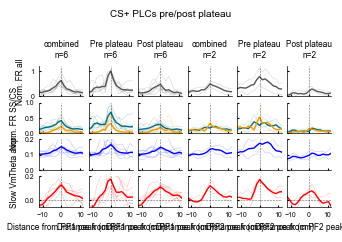

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_CSplus_average_primary_secondary_prepost_plateau.svg
PF FR norm denominator mode=zero: zero=2, peak fallback=0, invalid=0
PF FR norm denominator mode=zero: zero=1, peak fallback=0, invalid=0
[CS- PLCs pre/post plateau] n (PF1): combined=2, pre=2, post=2
[CS- PLCs pre/post plateau] n (PF2): combined=1, pre=1, post=1


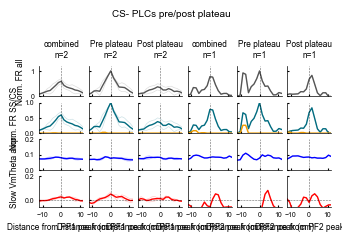

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_CSminus_average_primary_secondary_prepost_plateau.svg


In [42]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    pf_avg_fr_row_ylim_max = 1.2
    min_trials_per_column_prepost_plateau = prepost_plateau_min_traversals_per_phase
    average_export_dir_prepost_plateau = os.path.join(figure_save_folder, prepost_plateau_average_export_subdir)

    common_prepost_plateau_kwargs = dict(
        smooth_window=smooth_window,
        plot_trials=True,
        trial_alpha=0.2,
        trial_linewidth=0.5,
        theta_ylim=(0, 0.2),
        slow_ylim=(-0.05, 0.2),
        fr_ylim_scale=1.2,
        ss_cs_ylim_scale=1.2,
        figsize_per_block=(3.4, 1.8),
        xlim=distance_centered_display_xlim,
        fr_row_ylim_max=pf_avg_fr_row_ylim_max,
        show_plot=True,
        max_peak_adjust_cm_pf1=max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=max_peak_adjust_cm_pf2,
        min_traversals_per_type=distance_centered_params.min_traversals_per_type,
        min_trials_per_column=min_trials_per_column_prepost_plateau,
        use_saved_average_exports=True,
        average_export_dir=average_export_dir_prepost_plateau,
        average_export_stage='post',
        enforce_min_traversals_on_saved_exports=False,
        fr_norm_reference_col='session1',
        show_sem_shading=False,
        split_mode=prepost_plateau_split_mode,
        split_window_minutes=None,
        plateau_split_min_traversals_per_phase=prepost_plateau_min_traversals_per_phase,
        plateau_split_excluded_traversals=prepost_plateau_excluded_traversals,
        phase_labels=prepost_plateau_phase_labels,
    )

    plot_specs_prepost_plateau = [
        ('CSplus', 'CS+ PLCs pre/post plateau', 'pf_distance_centered_CSplus_average_primary_secondary_prepost_plateau.svg'),
        ('CSminus', 'CS- PLCs pre/post plateau', 'pf_distance_centered_CSminus_average_primary_secondary_prepost_plateau.svg'),
    ]

    for category_name, title_text, filename in plot_specs_prepost_plateau:
        out_path = os.path.join(figure_save_folder, filename)
        plot_pf_distance_centered_category_primary_secondary_from_dataset_2sessions(
            dataset=distance_centered_dataset,
            category=category_name,
            title=title_text,
            out_path=out_path,
            **common_prepost_plateau_kwargs,
        )
        print(f'Generated: {out_path}')


## Compare directions

In [43]:
# Compare directions: heatmaps
direction_avg_mode = "combined"  # combined, S1, or S2
direction_smooth_window = smooth_window  # cm
direction_avg_smooth_window = avg_smooth_window  # cm
direction_max_peak_adjust_cm_pf1 = max_peak_adjust_cm_pf1  # cm
direction_max_peak_adjust_cm_pf2 = max_peak_adjust_cm_pf2  # cm
direction_average_export_subdir = 'pf_distance_centered_2directions_average_exports'

# Inclusion/normalization settings used by the distance-based grand average.
# Time-based direction plots below inherit these and only change axis/window/smoothing.
direction_min_trials_per_column = None
direction_average_export_stage = 'post'
direction_enforce_min_traversals_on_saved_exports = False
direction_fr_norm_reference_col = 'all'
direction_fr_norm_denominator_mode = 'zero'
direction_show_column_counts_in_titles = True


### Heatmaps comparing CW and CCW

In [44]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    distance_heatmap_summary_2directions = generate_pf_distance_centered_component_heatmaps_2directions(
        dataset=distance_centered_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        smooth_window=direction_smooth_window,
        fr_vmax_scale=0.2,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.3, 0.3),
        fig_width=2.6,
        trial_height=0.01,
        xlim=distance_centered_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=direction_avg_smooth_window,
        max_peak_adjust_cm_pf1=direction_max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=direction_max_peak_adjust_cm_pf2,
        avg_mode=direction_avg_mode,
        save_average_exports=True,
        average_export_subdir=direction_average_export_subdir,
        print_peak_shift_bins=True,
        show_plot=False,
    )

    for cat, info in distance_heatmap_summary_2directions.items():
        print(f"{cat} folder (2 directions): {info['output_dir']}")
        print(f"{cat} summary (2 directions): {info}")


[CSplus] per-cell peak shifts (distance bin = 1.5 cm):
  CKII_pAce21_PR_20250806 Cell 2: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce21_PR_20250806 Cell 3: PF1=+1 bins (+1.50 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 4: PF1=-2 bins (-3.00 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 6: PF1=+2 bins (+3.00 cm), PF2=-2 bins (-3.00 cm)
  CKII_pAce38_PX_20251126 Cell 7: PF1=+0 bins (+0.00 cm), PF2=+0 bins (+0.00 cm)
  CKII_pAce45_PX_20260118 Cell 5: PF1=-1 bins (-1.50 cm), PF2=NA
  CKII_pAce45_PX_20260118 Cell 12: PF1=-4 bins (-6.00 cm), PF2=NA
  CKII_pAce47_PX_20260128 Cell 1: PF1=-2 bins (-3.00 cm), PF2=-1 bins (-1.50 cm)
  CKII_pAce47_PX_20260128 Cell 3: PF1=-4 bins (-6.00 cm), PF2=NA
  CKII_pAce47_PX_20260128 Cell 4: PF1=-1 bins (-1.50 cm), PF2=+0 bins (+0.00 cm)
  CKII_pAce50_PRL_20260317 Cell 9: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce54_PR_20260506 Cell 4: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce54_PR_20260506 Cell 10: PF1=+0 bins (+0.00 cm), PF2=NA
  CKII_pAce54_PR_20260506 Cell 14

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:19029: RuntimeWarning: Mean of empty slice
  mean_trace = np.asarray(np.nanmean(stack[mask], axis=0), dtype=float)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:14202: RuntimeWarning: Mean of empty slice
  mean_trace = _smooth_avg(np.nanmean(stack, axis=0))
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:14128: RuntimeWarning: Mean of empty slice
  ss_mean = _smooth_avg(np.nanmean(ss_stack, axis=0))
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:14137: RuntimeWarning: Mean of empty slice
  cs_mean = _smooth_avg(np.nanmean(cs_stack, axis=0))


[CSplus] 2/16 saved: CKII_pAce21_PR_20250806_Cell3_heatmap_2directions.svg
[CSplus] 3/16 saved: CKII_pAce38_PX_20251126_Cell4_heatmap_2directions.svg
[CSplus] 4/16 saved: CKII_pAce38_PX_20251126_Cell6_heatmap_2directions.svg
[CSplus] 5/16 saved: CKII_pAce38_PX_20251126_Cell7_heatmap_2directions.svg
[CSplus] 6/16 saved: CKII_pAce45_PX_20260118_Cell5_heatmap_2directions.svg
[CSplus] 7/16 saved: CKII_pAce45_PX_20260118_Cell12_heatmap_2directions.svg
[CSplus] 8/16 saved: CKII_pAce47_PX_20260128_Cell1_heatmap_2directions.svg
[CSplus] 9/16 saved: CKII_pAce47_PX_20260128_Cell3_heatmap_2directions.svg
[CSplus] 10/16 saved: CKII_pAce47_PX_20260128_Cell4_heatmap_2directions.svg
[CSplus] 11/16 saved: CKII_pAce50_PRL_20260317_Cell9_heatmap_2directions.svg
[CSplus] 12/16 saved: CKII_pAce54_PR_20260506_Cell4_heatmap_2directions.svg
[CSplus] 13/16 saved: CKII_pAce54_PR_20260506_Cell10_heatmap_2directions.svg
[CSplus] 14/16 saved: CKII_pAce54_PR_20260506_Cell14_heatmap_2directions.svg
[CSplus] 15/16 s

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:19404: RuntimeWarning: Mean of empty slice
  tr = np.asarray(np.nanmean(sub, axis=0), dtype=float)


CSplus folder (2 directions): /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_centered_2directions_CSplus_heatmaps
CSplus summary (2 directions): {'output_dir': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_centered_2directions_CSplus_heatmaps', 'n_primary_entries': 16, 'n_secondary_entries': 5, 'n_union_entries': 16, 'n_pf2_only_entries': 0, 'n_saved_files': 16, 'n_dual_pf_files': 5, 'mode': 'direction_heatmap_with_avg_mode', 'avg_mode': 'combined', 'average_export_dir': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_2directions_average_exports/CSplus', 'average_export_index_csv': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_2directions_average_exports/CSplus/session_averages_pre_post_index.csv', 

### Grand Average, comparing directions


PF1 counts: All (n=16), Pref (n=16), Non-pref (n=16)

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:20976: RuntimeWarning: Mean of empty slice
  dir_data["ss_pct_mean"] = np.nanmean(ss_pct, axis=0) if ss_pct.size > 0 else np.full(n_time, np.nan, dtype=float)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:20977: RuntimeWarning: Mean of empty slice
  dir_data["cs_pct_mean"] = np.nanmean(cs_pct, axis=0) if cs_pct.size > 0 else np.full(n_time, np.nan, dtype=float)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:14886: RuntimeWarning: Mean of empty slice
  trace = np.nanmean(stack, axis=0)



PF1 FR norm denominator mode=zero: zero=16, peak fallback=0, external=0, invalid/skipped=0
PF2 counts: All (n=5), Pref (n=5), Non-pref (n=5)
PF2 FR norm denominator mode=zero: zero=0, peak fallback=0, external=5, invalid/skipped=0


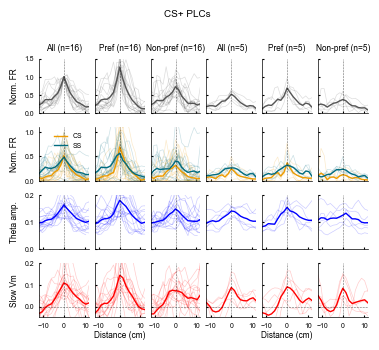

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_CSplus_average_primary_secondary_2directions.svg
PF1 counts: All (n=8), Pref (n=8), Non-pref (n=8)
PF1 FR norm denominator mode=zero: zero=8, peak fallback=0, external=0, invalid/skipped=0
PF2 counts: All (n=2), Pref (n=2), Non-pref (n=2)
PF2 FR norm denominator mode=zero: zero=0, peak fallback=0, external=2, invalid/skipped=0


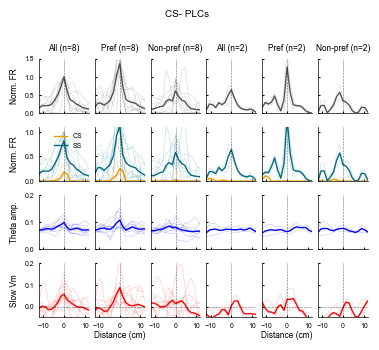

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_CSminus_average_primary_secondary_2directions.svg


In [45]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    direction_avg_out_cs_plus = os.path.join(figure_save_folder, 'pf_distance_centered_CSplus_average_primary_secondary_2directions.svg')
    direction_avg_out_cs_minus = os.path.join(figure_save_folder, 'pf_distance_centered_CSminus_average_primary_secondary_2directions.svg')
    direction_average_export_dir = os.path.join(figure_save_folder, direction_average_export_subdir)
    direction_ss_cs_row_ylim_max = 1.1

    direction_common_plot_kwargs = dict(
        smooth_window=direction_smooth_window,
        avg_smooth_window=direction_avg_smooth_window,
        plot_trials=True,
        trial_alpha=0.2,
        trial_linewidth=0.5,
        theta_ylim=(0, 0.2),
        slow_ylim=(-0.05, 0.2),
        fr_ylim_scale=1.2,
        ss_cs_ylim_scale=1.2,
        figsize_per_block=(3.8, 3.5),
        xlim=distance_centered_display_xlim,
        fr_row_ylim_max=1.5,
        ss_cs_row_ylim_max=direction_ss_cs_row_ylim_max,
        max_peak_adjust_cm_pf1=direction_max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=direction_max_peak_adjust_cm_pf2,
        min_traversals_per_type=distance_centered_params.min_traversals_per_type,
        min_trials_per_column=direction_min_trials_per_column,
        use_saved_average_exports=True,
        average_export_dir=direction_average_export_dir,
        average_export_stage=direction_average_export_stage,
        avg_mode=direction_avg_mode,
        enforce_min_traversals_on_saved_exports=direction_enforce_min_traversals_on_saved_exports,
        show_sem_shading=False,
        fr_norm_reference_col=direction_fr_norm_reference_col,
        fr_norm_denominator_mode=direction_fr_norm_denominator_mode,
        show_column_counts_in_titles=direction_show_column_counts_in_titles,
        show_plot=True,
    )

    plot_pf_distance_centered_category_primary_secondary_from_dataset_2directions(
        dataset=distance_centered_dataset,
        category='CSplus',
        title='CS+ PLCs',
        out_path=direction_avg_out_cs_plus,
        **direction_common_plot_kwargs,
    )
    print(f'Generated: {direction_avg_out_cs_plus}')

    plot_pf_distance_centered_category_primary_secondary_from_dataset_2directions(
        dataset=distance_centered_dataset,
        category='CSminus',
        title='CS- PLCs',
        out_path=direction_avg_out_cs_minus,
        **direction_common_plot_kwargs,
    )
    print(f'Generated: {direction_avg_out_cs_minus}')



### Statistics, Pref vs Non-pref


In [46]:
### Directionality (Pref vs Non-pref) | Stability-style metrics
# Uses the same metric family as compare-sessions: r, peak shift, AUC ratio, peak ratio, abs normalized change.
directionality_min_traversals_per_type = distance_centered_params.min_traversals_per_type
directionality_smooth_window_cm = 0.0
directionality_auc_window_cm = None
directionality_slow_auc_window_cm = (-10.0, 10.0)
directionality_peak_window_cm = (-10.0, 10.0)
directionality_five_panel_figsize = (2.7, 2.3)
directionality_two_subplot_figsize = (1, 2.3)    # tune 2-subplot figure size
directionality_average_export_dir_2directions = os.path.join(figure_save_folder, direction_average_export_subdir)

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    directionality_results = compute_pf_distance_centered_pref_nonpref_stats(
        distance_centered_dataset,
        min_traversals_per_type=directionality_min_traversals_per_type,
        smooth_window_cm=directionality_smooth_window_cm,
        auc_window_cm=directionality_auc_window_cm,
        slow_auc_window_cm=directionality_slow_auc_window_cm,
        peak_window_cm=directionality_peak_window_cm,
        use_saved_average_exports=True,
        average_export_dir=directionality_average_export_dir_2directions,
        average_export_stage='post',
        avg_mode=direction_avg_mode,
        print_nan_diagnostics=True,
        set_nan_r_to_zero=True,
    )

    print(f"Skipped counts: {directionality_results.get('skipped_counts', {})}")

    per_cell_directionality = directionality_results.get("per_cell_stability", None)
    if per_cell_directionality is not None and len(per_cell_directionality) > 0:
        print("\nDisplayed cell counts by metric/group:")
        count_cols = {
            "r": "r",
            "peak_shift": "delta_peak_x_cm",
            "auc_ratio": "auc_ratio",
            "peak_ratio": "peak_ratio_s2_s1",
            "abs_norm_change": "peak_abs_sym_diff",
        }
        for metric_name in ["all_spike", "ss", "cs", "theta", "slow"]:
            sub_metric = per_cell_directionality[per_cell_directionality["metric"] == metric_name].copy()
            if len(sub_metric) == 0:
                continue
            print(f"  {metric_name}:")
            for stat_label, stat_col in count_cols.items():
                if stat_col not in set(sub_metric.columns):
                    continue
                sub_stat = sub_metric.copy()
                if stat_col == "delta_peak_x_cm":
                    sub_stat[stat_col] = sub_stat[stat_col].abs()
                sub_stat = sub_stat[sub_stat[stat_col].notna()]
                if metric_name == "cs":
                    sub_stat = sub_stat[sub_stat["group"].isin(["CSplus_PF1", "CSplus_PF2"])]
                sub_stat["cell_key"] = (
                    sub_stat["animal_id"].astype(str) + "::" + sub_stat["cell_idx"].astype(int).astype(str)
                )
                counts = (
                    sub_stat.groupby("group")["cell_key"]
                    .nunique()
                    .reindex(["CSplus_PF1", "CSplus_PF2", "CSminus_PF1"])
                    .fillna(0)
                    .astype(int)
                )
                print(
                    f"    {stat_label}: "
                    f"CS+ PF1={counts.get('CSplus_PF1', 0)}, "
                    f"CS+ PF2={counts.get('CSplus_PF2', 0)}, "
                    f"CS- PF1={counts.get('CSminus_PF1', 0)}"
                )

    directionality_plot_summary = plot_pf_distance_centered_pref_nonpref_stats(
        directionality_results,
        figure_save_folder=figure_save_folder,
        five_panel_figsize=directionality_five_panel_figsize,
        two_subplot_figsize=directionality_two_subplot_figsize,
        show_plot=False,
        save_csv=True,
    )

    print('Directionality outputs:')
    print(f"  Figure (5 columns): {directionality_plot_summary.get('figure')}")
    print(f"  Per-cell CSV: {directionality_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {directionality_plot_summary.get('stats_csv')}")
    print(f"  Figure (2 subplots): {directionality_plot_summary.get('figure_2subplots')}")
    print(f"  Stats CSV (2 subplots): {directionality_plot_summary.get('stats_csv_2subplots')}")





[pref_nonpref_stability] Cells/metrics with NaN values (flat/invalid traces):
  group=CSminus_PF1, metric=cs, cell=CKII_pAce45_PX_20260118_Cell3, n_pref=21, n_nonpref=29, overlap_bins=21, auc_bins=21, peak_bins=13, reasons=peak_ratio:zero_or_invalid_peak_preferred; peak_abs_sym_diff:zero_or_invalid_peak_sum
Skipped counts: {'missing': 0, 'low_traversals': 15, 'no_preferred': 11}

Displayed cell counts by metric/group:
  all_spike:
    r: CS+ PF1=9, CS+ PF2=3, CS- PF1=2
    peak_shift: CS+ PF1=9, CS+ PF2=3, CS- PF1=2
    auc_ratio: CS+ PF1=9, CS+ PF2=3, CS- PF1=2
    peak_ratio: CS+ PF1=9, CS+ PF2=3, CS- PF1=2
    abs_norm_change: CS+ PF1=9, CS+ PF2=3, CS- PF1=2
  ss:
    r: CS+ PF1=9, CS+ PF2=3, CS- PF1=2
    peak_shift: CS+ PF1=9, CS+ PF2=3, CS- PF1=2
    auc_ratio: CS+ PF1=9, CS+ PF2=3, CS- PF1=2
    peak_ratio: CS+ PF1=9, CS+ PF2=3, CS- PF1=2
    abs_norm_change: CS+ PF1=9, CS+ PF2=3, CS- PF1=2
  cs:
    r: CS+ PF1=9, CS+ PF2=3, CS- PF1=0
    peak_shift: CS+ PF1=9, CS+ PF2=3, CS- PF

### Compare FWHM of All spikes and slow Vm tuning curves for PF1 and PF2

All spikes FWHM CS+ PF2 vs PF1: n=4, test=wilcoxon (n<=6), shapiro_p=nan, stat=1, p=0.25, sig=n.s.
All spikes FWHM CS- PF2 vs PF1: n=2, test=n/a, shapiro_p=nan, stat=nan, p=nan, sig=
SS FWHM CS+ PF2 vs PF1: n=4, test=wilcoxon (n<=6), shapiro_p=nan, stat=5, p=1, sig=n.s.
SS FWHM CS- PF2 vs PF1: n=2, test=n/a, shapiro_p=nan, stat=nan, p=nan, sig=
CS FWHM CS+ PF2 vs PF1: n=4, test=wilcoxon (n<=6), shapiro_p=nan, stat=3, p=0.625, sig=n.s.
CS FWHM CS- PF2 vs PF1: n=1, test=n/a, shapiro_p=nan, stat=nan, p=nan, sig=
Theta FWHM CS+ PF2 vs PF1: n=4, test=wilcoxon (n<=6), shapiro_p=nan, stat=3, p=0.625, sig=n.s.
Theta FWHM CS- PF2 vs PF1: n=2, test=n/a, shapiro_p=nan, stat=nan, p=nan, sig=
Slow Vm FWHM CS+ PF2 vs PF1: n=4, test=wilcoxon (n<=6), shapiro_p=nan, stat=3, p=0.625, sig=n.s.
Slow Vm FWHM CS- PF2 vs PF1: n=2, test=n/a, shapiro_p=nan, stat=nan, p=nan, sig=
CS+ all-spike vs slow Vm PF1 Slow Vm vs All spikes: n=14, test=paired t-test, shapiro_p=0.0531, stat=1.84, p=0.089, sig=n.s.
CS+ all-

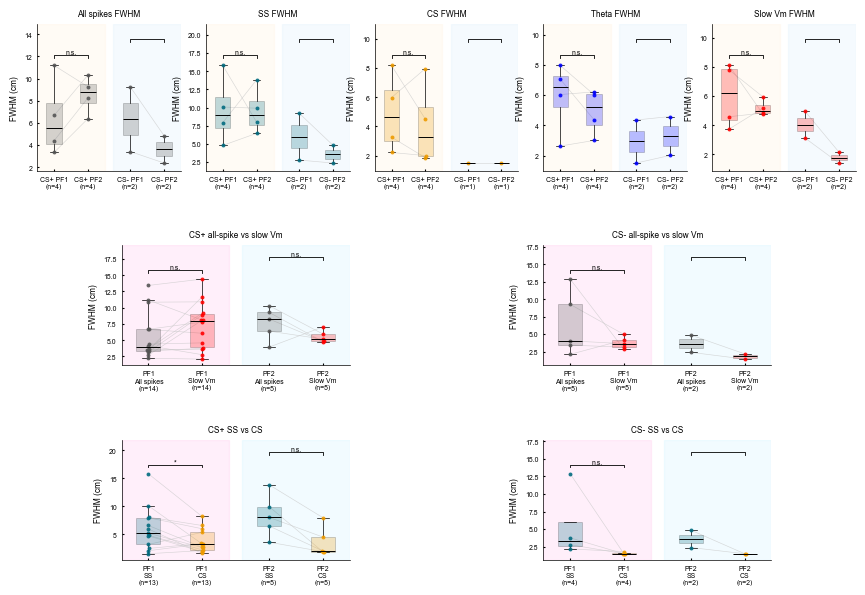

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_pf1_pf2_fwhm_all_spikes_slow_vm.svg


,metric,metric_label,category,comparison,n,p_value,statistic,test,shapiro_p,pf1_mean,pf2_mean,pf_rank,left_metric,right_metric,left_mean,right_mean
0,all_spike,All spikes FWHM,CSplus,PF2_vs_PF1,4,0.250000,1.000000,wilcoxon (n<=6),NaN,6.399010,8.559261,NaN,NaN,NaN,NaN,NaN
1,all_spike,All spikes FWHM,CSminus,PF2_vs_PF1,2,NaN,NaN,n/a,NaN,6.341973,3.619714,NaN,NaN,NaN,NaN,NaN
2,ss,SS FWHM,CSplus,PF2_vs_PF1,4,1.000000,5.000000,wilcoxon (n<=6),NaN,9.660418,9.560548,NaN,NaN,NaN,NaN,NaN
3,ss,SS FWHM,CSminus,PF2_vs_PF1,2,NaN,NaN,n/a,NaN,6.029291,3.619714,NaN,NaN,NaN,NaN,NaN
4,cs,CS FWHM,CSplus,PF2_vs_PF1,4,0.625000,3.000000,wilcoxon (n<=6),NaN,4.911443,4.084024,NaN,NaN,NaN,NaN,NaN
5,cs,CS FWHM,CSminus,PF2_vs_PF1,1,NaN,NaN,n/a,NaN,1.500000,1.500000,NaN,NaN,NaN,NaN,NaN
6,theta,Theta FWHM,CSplus,PF2_vs_PF1,4,0.625000,3.000000,wilcoxon (n<=6),NaN,5.916477,4.897246,NaN,NaN,NaN,NaN,NaN
7,theta,Theta FWHM,CSminus,PF2_vs_PF1,2,NaN,NaN,n/a,NaN,2.930546,3.296216,NaN,NaN,NaN,NaN,NaN
8,slow_vm,Slow Vm FWHM,CSplus,PF2_vs_PF1,4,0.625000,3.000000,wilcoxon (n<=6),NaN,6.052044,5.182675,NaN,NaN,NaN,NaN,NaN
9,slow_vm,Slow Vm FWHM,CSminus,PF2_vs_PF1,2,NaN,NaN,n/a,NaN,4.035051,1.789311,NaN,NaN,NaN,NaN,NaN


In [47]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    pf1_pf2_fwhm_out_path = os.path.join(
        figure_save_folder,
        "pf_distance_centered_pf1_pf2_fwhm_all_spikes_slow_vm.svg",
    )
    pf1_pf2_fwhm_summary = plot_pf_distance_centered_pf1_pf2_fwhm_all_spikes_slow_vm(
        distance_centered_dataset=distance_centered_dataset,
        save_path=pf1_pf2_fwhm_out_path,
        fig_width=8.5,
        fig_height=5.8,
        min_traversals_per_type=distance_centered_params.min_traversals_per_type,
        smooth_window_cm=0.0,
        all_direction_key="all",
    )
    plt.show()
    print(f"Saved: {pf1_pf2_fwhm_summary['figure_path']}")
    display(pf1_pf2_fwhm_summary["stats_df"])


# Session Compare: Heatmaps

### Session-Compare Parameters

In [48]:
session_compare_params = SessionCompareParams(
    panel_mode='s1_s2',  # 's1_s2' or 'combined_s1_s2'
    cache_version='v2',
    rebuild_cache=True,
    max_cells_per_figure=10,
    missing_s2_policy='na_panel',
    s1s2_min_occupancy_per_bin_s=0.2,  # require >=0.5 s occupancy in both sessions for each spatial bin
    occupancy_spearman_threshold=-0.5,
    apply_occupancy_dataset_filter=False,
    enforce_s1s2_min_peak_rate_filter=True,
    s1s2_min_peak_rate_hz=0.5,
    clean_heatmap=True,
    heatmap_similarity_metric='pearson',
    weighted=True,  # if True, weight Pearson/Spearman/cosine by min S1/S2 occupancy per bin
    baseline_subtraction_cosine=False,  # if True, subtract each map mean before cosine similarity
    plot_spike_shapes=True,
    plot_spike_shapes_overall=True,
    plot_spike_shapes_in_field=True,
    plot_spike_shapes_out_field=True,
    include_plateau=include_plateau_heatmap,
    plateau_state_mode=plateau_state_mode,
    plateau_include_long_cb_as_plateau=plateau_include_long_cb_as_plateau,
    plateau_cb_min_duration_ms=plateau_cb_min_duration_ms,
    plateau_speed_threshold=plateau_speed_threshold,
    two_session_split_mode='time_windows',
    two_session_split_window_minutes=10.0,  # set to 5.0 for first/second 5 min windows
    align_to_distance_normalized_exports=False,
    distance_normalized_export_dir=os.path.join(figure_save_folder, 'pf_distance_centered_2sessions_average_exports'),
    distance_normalized_min_trials_per_session=4,
    distance_normalized_pf_rank=1,
    selected_theta_vlim=None,
    selected_slow_vlim=None,
    quiet_epoch_mode='strict_low_speed',  # 'strict_low_speed' or 'non_moving'
    stats_min_included_minutes_per_session=4.0,  # stats-only: require >=4 included minutes in both S1 and S2
)

print(session_compare_params)


SessionCompareParams(panel_mode='s1_s2', cache_version='v2', rebuild_cache=True, max_cells_per_figure=10, missing_s2_policy='na_panel', occupancy_spearman_threshold=-0.5, apply_occupancy_dataset_filter=False, enforce_s1s2_min_peak_rate_filter=True, s1s2_min_peak_rate_hz=0.5, clean_heatmap=True, heatmap_similarity_metric='pearson', weighted=True, baseline_subtraction_cosine=False, s1s2_min_occupancy_per_bin_s=0.2, plot_spike_shapes=True, plot_spike_shapes_overall=True, plot_spike_shapes_in_field=True, plot_spike_shapes_out_field=True, plot_PF_combined=True, include_plateau=True, plateau_state_mode='split', plateau_include_long_cb_as_plateau=False, plateau_cb_min_duration_ms=200.0, plateau_speed_threshold=3.0, two_session_split_mode='time_windows', two_session_split_window_minutes=10.0, align_to_distance_normalized_exports=False, distance_normalized_export_dir='/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_

### Build/Load Payloads + Assemble Groups

In [49]:
import numpy as np
import pandas as pd

expected_session_compare_counts = {
    'CS+': len(spatial_data.plcs_csplus),
    'CS-': len(spatial_data.plcs_csminus),
    'Non-PLC': len(spatial_data.non_plcs),
    'Excluded': len(spatial_data.deleted_cells),
}


session_compare_analysis = build_session_compare_analysis(
    config,
    session_compare_params,
    spatial_data=spatial_data,
)
session_compare_payloads = session_compare_analysis['payloads']
session_compare_groups = session_compare_analysis['groups']
session_split_4panel_tables = session_compare_analysis['session_split_4panel_tables']
session_split_classification = session_compare_analysis['session_split_classification']

expected_key_sets = {
    'CS+': set((str(c['session']), int(c['cell_idx'])) for c in spatial_data.plcs_csplus),
    'CS-': set((str(c['session']), int(c['cell_idx'])) for c in spatial_data.plcs_csminus),
    'Non-PLC': set((str(c['session']), int(c['cell_idx'])) for c in spatial_data.non_plcs),
}
actual_key_sets = {
    'CS+': set(session_compare_groups['csplus_keys']),
    'CS-': set(session_compare_groups['csminus_keys']),
    'Non-PLC': set(session_compare_groups['nonpc_keys']),
}
session_compare_key_summary = {
    label: {
        'expected': len(expected_key_sets[label]),
        'actual': len(actual_key_sets[label]),
        'missing_from_session_compare': len(expected_key_sets[label] - actual_key_sets[label]),
        'extra_in_session_compare': len(actual_key_sets[label] - expected_key_sets[label]),
    }
    for label in expected_key_sets
}

actual_session_compare_counts = {
    'CS+': len(session_compare_groups['csplus_groups']),
    'CS-': len(session_compare_groups['csminus_groups']),
    'Non-PLC': len(session_compare_groups['nonpc_groups']),
}
print(f"Datasets loaded: {len(session_compare_payloads['session_payload_by_dataset'])}")
print(f"Category source: {session_compare_groups.get('category_source')}")
print(f"Current spatial_data counts: {expected_session_compare_counts}")
print(f"Session Compare category counts after filters: {actual_session_compare_counts}")
print(f"Session Compare key summary: {session_compare_key_summary}")
print(f"Session Compare category counts before filters: {session_compare_groups.get('category_counts_before_filters')}")
print(f"Stats min included minutes per session: {session_compare_groups.get('stats_min_included_minutes_per_session')}")
print(f"Stats included-time filter: {session_compare_groups.get('stats_filter_summary')}")
print(f"Precomputed S1/S2 similarity metrics: {sorted(session_compare_analysis.get('s1s2_similarity_stats_by_metric', {}).keys())}")
print(f"Allowed datasets after occupancy filter: {len(session_compare_groups['allowed_dataset_ids'])}")
print(f"Excluded datasets: {len(session_compare_groups['excluded_dataset_ids'])}")
print(f"CS+ rows: {actual_session_compare_counts['CS+']}")
print(f"CS- rows: {actual_session_compare_counts['CS-']}")
print(f"Non-PLC rows: {actual_session_compare_counts['Non-PLC']}")
print(
    "Split 4-panel rows: "
    f"S1 CS+={len(session_split_4panel_tables['session1']['df_cs_plc'])}, "
    f"S1 CS-={len(session_split_4panel_tables['session1']['df_non_cs_plc'])}, "
    f"S2 CS+={len(session_split_4panel_tables['session2']['df_cs_plc'])}, "
    f"S2 CS-={len(session_split_4panel_tables['session2']['df_non_cs_plc'])}"
)
print(f"Theta vlim: {session_compare_groups['selected_theta_vlim']}")
print(f"Slow vlim: {session_compare_groups['selected_slow_vlim']}")

print(f"Distance-normalized alignment: {session_compare_groups.get('distance_normalized_alignment')}")

def _stats_table_min_minutes(df):
    if df is None or len(df) == 0:
        return np.nan
    vals = pd.to_numeric(df.get('included_minutes', np.nan), errors='coerce')
    return float(vals.min()) if len(vals) else np.nan

stats_table_min_minutes = {
    'S1 CS+': _stats_table_min_minutes(session_split_4panel_tables['session1']['df_cs_plc']),
    'S1 CS-': _stats_table_min_minutes(session_split_4panel_tables['session1']['df_non_cs_plc']),
    'S2 CS+': _stats_table_min_minutes(session_split_4panel_tables['session2']['df_cs_plc']),
    'S2 CS-': _stats_table_min_minutes(session_split_4panel_tables['session2']['df_non_cs_plc']),
}
print(f"Stats table min included minutes observed: {stats_table_min_minutes}")

display(session_compare_groups['occupancy_similarity_df'])
display(session_compare_analysis['session_split_classification_summary_df'])
display(session_compare_analysis['nonplc_becomes_plc_df'])


CKII_pAce21_PR_20250806: SNR filter kept 7/9 cells (threshold=5, min_good_minutes=0.0).
Saved session-compare cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce21_PR_20250806/spatial_session_cache_v2.pkl
CKII_pAce38_PX_20251126: SNR filter kept 7/9 cells (threshold=5, min_good_minutes=0.0).
CKII_pAce38_PX_20251126: SNR filter kept 7/9 cells (threshold=5, min_good_minutes=0.0).
Saved session-compare cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce38_PX_20251126/spatial_session_cache_v2.pkl
CKII_pAce45_PX_20260118: SNR filter kept 9/16 cells (threshold=5, min_good_minutes=0.0).
CKII_pAce45_PX_20260118: SNR filter kept 8/16 cells (threshold=5, min_good_minutes=0.0).
Saved session-compare cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce45_PX_20260118/spatial_session_cache_v2.pkl
CKII_pAce47_PX_20260128: SNR filter 

,dataset_id,occupancy_spearman,n_valid_bins
0,CKII_pAce21_PR_20250806,NaN,0
1,CKII_pAce38_PX_20251126,0.224293,336
2,CKII_pAce45_PX_20260118,0.668176,336
3,CKII_pAce47_PX_20260128,0.077920,336
4,CKII_pAce46_PR_20260222,0.482462,336
5,CKII_pAce50_PRL_20260317,0.153043,336
6,CKII_pAce54_PR_20260506,0.061181,336
7,CKII_pAce54_PX_20260514,0.862020,336


,combined_group,n_cells,session1_CS+_PLC,session1_CS-_PLC,session1_Non-PLC,session1_missing,session2_CS+_PLC,session2_CS-_PLC,session2_Non-PLC,session2_missing,same_label_both_sessions,becomes_split_session_PLC
0,combined CS+ PLC,16,13,0,3,0,3,1,9,3,3,0
1,combined CS- PLC,8,0,7,1,0,0,2,3,3,2,0
2,combined Non-PLC,41,0,3,38,0,0,3,29,9,27,5


,combined_group,animal_id,session,cell_idx,session1_label,session2_label,session1_is_place_cell,session2_is_place_cell,session1_n_cb_run_in,session2_n_cb_run_in,session1_cs_peak_rate,session2_cs_peak_rate
28,combined Non-PLC,CKII_pAce38_PX_20251126,CKII_pAce38_PX_20251126,1,CS- PLC,Non-PLC,True,False,4,3,0.633442,0.289305
30,combined Non-PLC,CKII_pAce45_PX_20260118,CKII_pAce45_PX_20260118,0,CS- PLC,CS- PLC,True,True,5,3,0.464379,0.548422
44,combined Non-PLC,CKII_pAce50_PRL_20260317,CKII_pAce50_PRL_20260317,1,Non-PLC,CS- PLC,False,True,0,6,1.548347,0.485016
49,combined Non-PLC,CKII_pAce50_PRL_20260317,CKII_pAce50_PRL_20260317,6,Non-PLC,CS- PLC,False,True,0,0,0.000000,0.000000
61,combined Non-PLC,CKII_pAce54_PX_20260514,CKII_pAce54_PX_20260514,7,CS- PLC,Non-PLC,True,False,7,4,0.764496,0.796939


### Render Session-Compare Heatmaps

Plotting CS+ comparison (n=16, 2 conditions each)
  Rendering CS+ part 1/2: n=10 -> spatial_compare_csplus_s1_s2_part01.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/spatial_compare_csplus_s1_s2_part01.svg


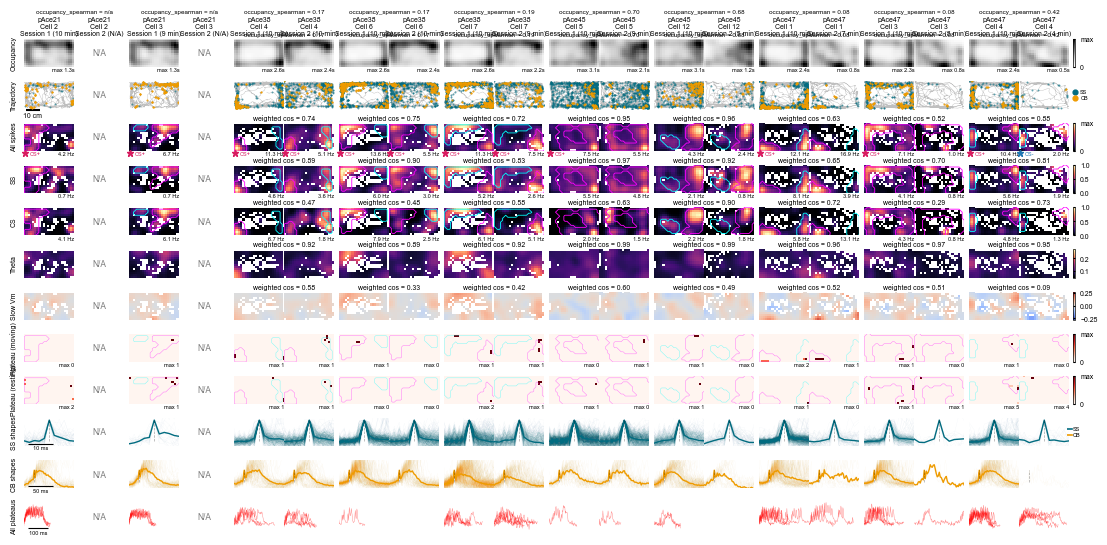

  Rendering CS+ part 2/2: n=6 -> spatial_compare_csplus_s1_s2_part02.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/spatial_compare_csplus_s1_s2_part02.svg


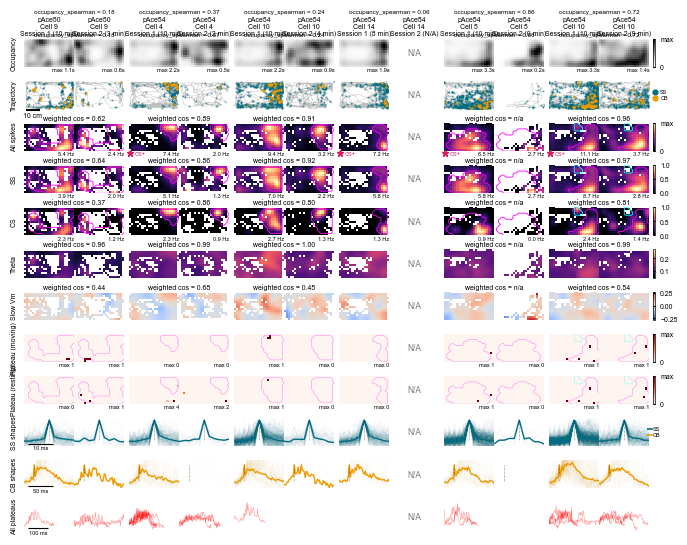

Plotting CS- comparison (n=8, 2 conditions each)
  Rendering CS- part 1/1: n=8 -> spatial_compare_csminus_s1_s2.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/spatial_compare_csminus_s1_s2.svg


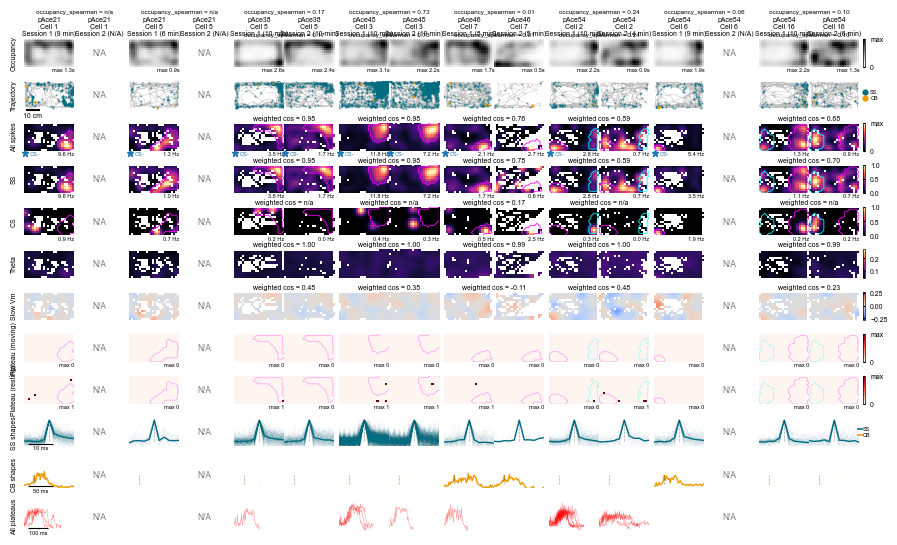

Plotting Non-PLC comparison (n=41, 2 conditions each)
  Rendering Non-PLC part 1/5: n=10 -> spatial_compare_nonplc_s1_s2_part01.svg
pAce21 Cell 4: All spikes PF mask is empty
pAce21 Cell 4: SS PF mask is empty
pAce21 Cell 4: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/spatial_compare_nonplc_s1_s2_part01.svg


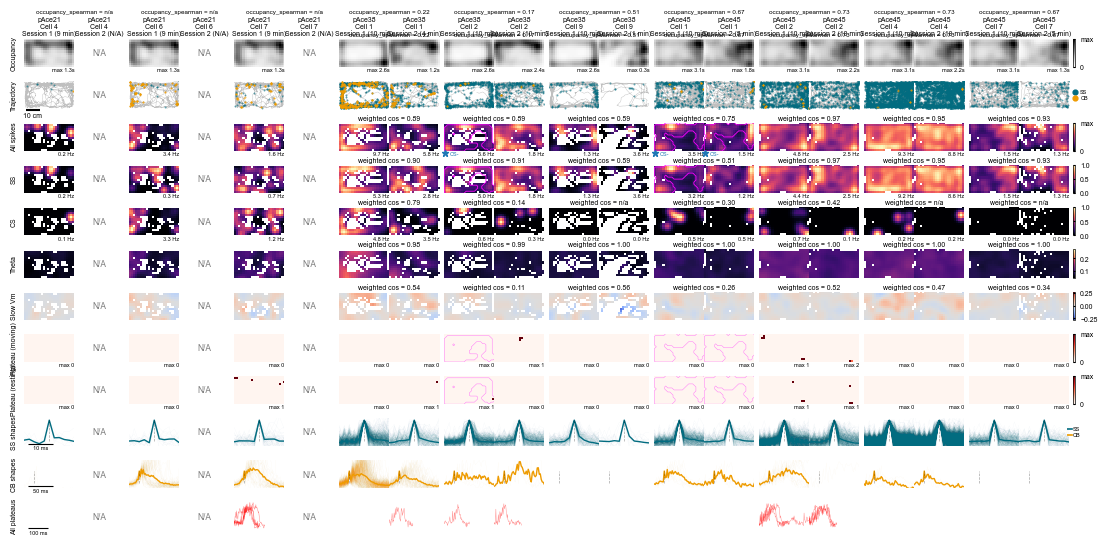

  Rendering Non-PLC part 2/5: n=10 -> spatial_compare_nonplc_s1_s2_part02.svg
pAce46 Cell 6: All spikes PF mask is empty
pAce46 Cell 6: SS PF mask is empty
pAce46 Cell 6: CS PF mask is empty
pAce46 Cell 6: All spikes PF mask is empty
pAce46 Cell 6: SS PF mask is empty
pAce46 Cell 6: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/spatial_compare_nonplc_s1_s2_part02.svg


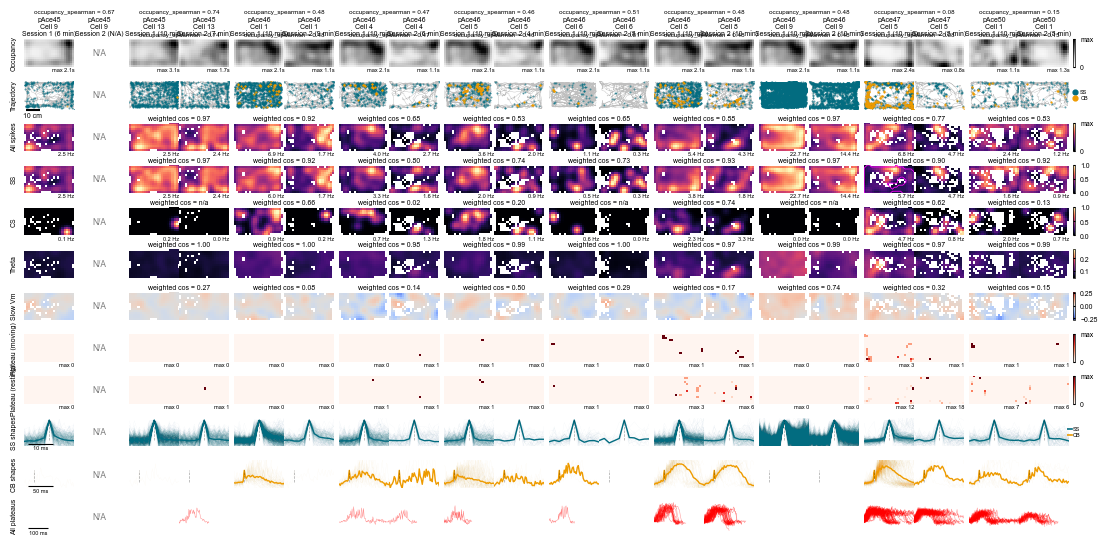

  Rendering Non-PLC part 3/5: n=10 -> spatial_compare_nonplc_s1_s2_part03.svg
pAce50 Cell 5: All spikes PF mask is empty
pAce50 Cell 5: SS PF mask is empty
pAce50 Cell 5: CS PF mask is empty
pAce50 Cell 5: All spikes PF mask is empty
pAce50 Cell 5: SS PF mask is empty
pAce50 Cell 5: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/spatial_compare_nonplc_s1_s2_part03.svg


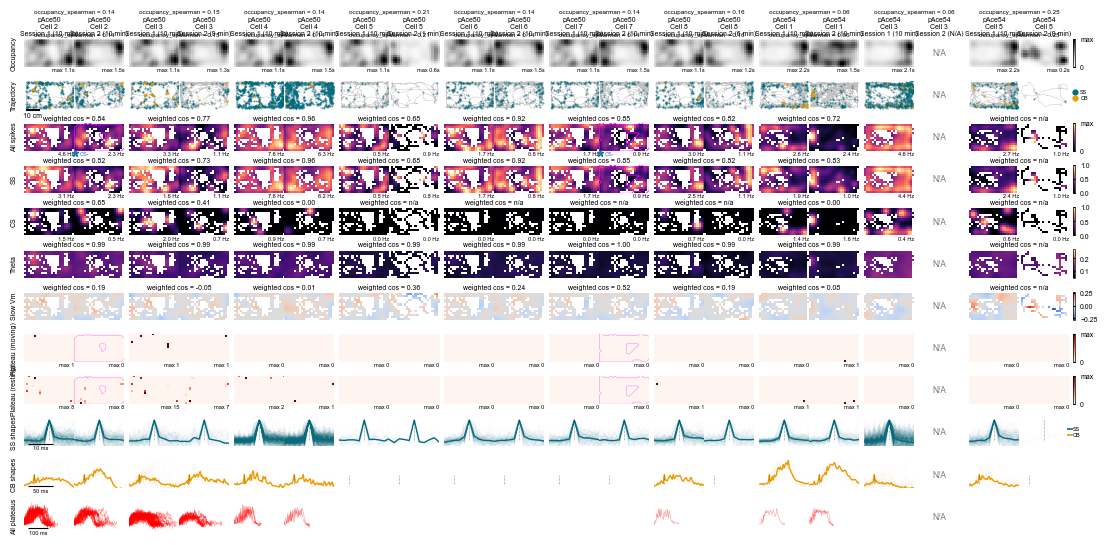

  Rendering Non-PLC part 4/5: n=10 -> spatial_compare_nonplc_s1_s2_part04.svg
pAce54 Cell 8: All spikes PF mask is empty
pAce54 Cell 8: SS PF mask is empty
pAce54 Cell 8: CS PF mask is empty
pAce54 Cell 15: All spikes PF mask is empty
pAce54 Cell 15: SS PF mask is empty
pAce54 Cell 15: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/spatial_compare_nonplc_s1_s2_part04.svg


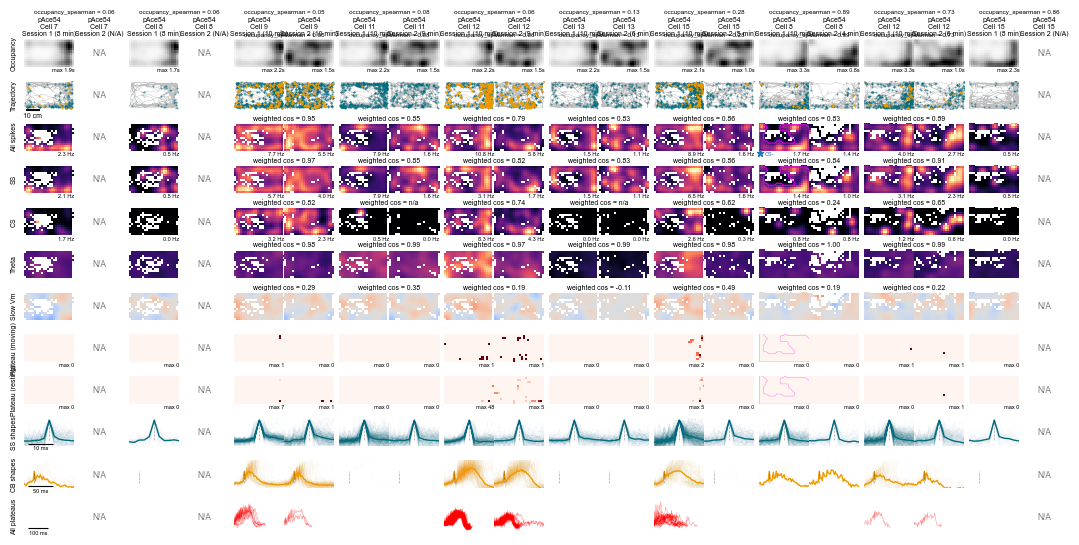

  Rendering Non-PLC part 5/5: n=1 -> spatial_compare_nonplc_s1_s2_part05.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/spatial_compare_nonplc_s1_s2_part05.svg


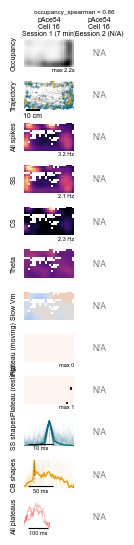

Figure folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled
Panel mode: s1_s2
Saved CS+ figures: 2
Saved CS- figures: 1
Saved Non-PLC figures: 5


In [50]:
session_compare_render = render_session_compare_heatmaps(
    config=config,
    params=session_compare_params,
    groups_payload=session_compare_groups,
    show_occupancy_heatmap=True,
    similarity_metric='cosine',  # 'pearson', 'spearman', or 'cosine'; None uses session_compare_params.heatmap_similarity_metric
)

print(f"Figure folder: {session_compare_render['figure_save_folder']}")
print(f"Panel mode: {session_compare_render['panel_mode']}")
print(f"Saved CS+ figures: {len(session_compare_render['saved_csplus'])}")
print(f"Saved CS- figures: {len(session_compare_render['saved_csminus'])}")
print(f"Saved Non-PLC figures: {len(session_compare_render['saved_nonplc'])}")


## Stats

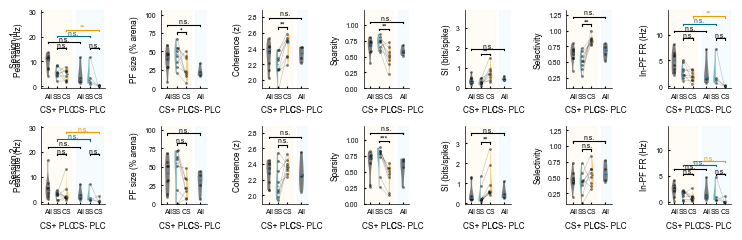

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/combined_cs_plus_minus_4panels_2sessions.svg
Rows plotted: S1 CS+=8, S1 CS-=4, S2 CS+=8, S2 CS-=4


In [51]:
session_split_4panel_out_path = os.path.join(figure_save_folder, 'combined_cs_plus_minus_4panels_2sessions.svg')
fig = plot_combined_cs_plus_minus_4panels_2sessions(
    session_tables=session_split_4panel_tables,
    save_path=session_split_4panel_out_path,
    plot_cs_minus_ss=False,
    fig_width=7.5,
    fig_height=2.4,
)
plt.show()
print(f'Saved: {session_split_4panel_out_path}')
print(
    "Rows plotted: "
    f"S1 CS+={len(session_split_4panel_tables['session1']['df_cs_plc'])}, "
    f"S1 CS-={len(session_split_4panel_tables['session1']['df_non_cs_plc'])}, "
    f"S2 CS+={len(session_split_4panel_tables['session2']['df_cs_plc'])}, "
    f"S2 CS-={len(session_split_4panel_tables['session2']['df_non_cs_plc'])}"
)


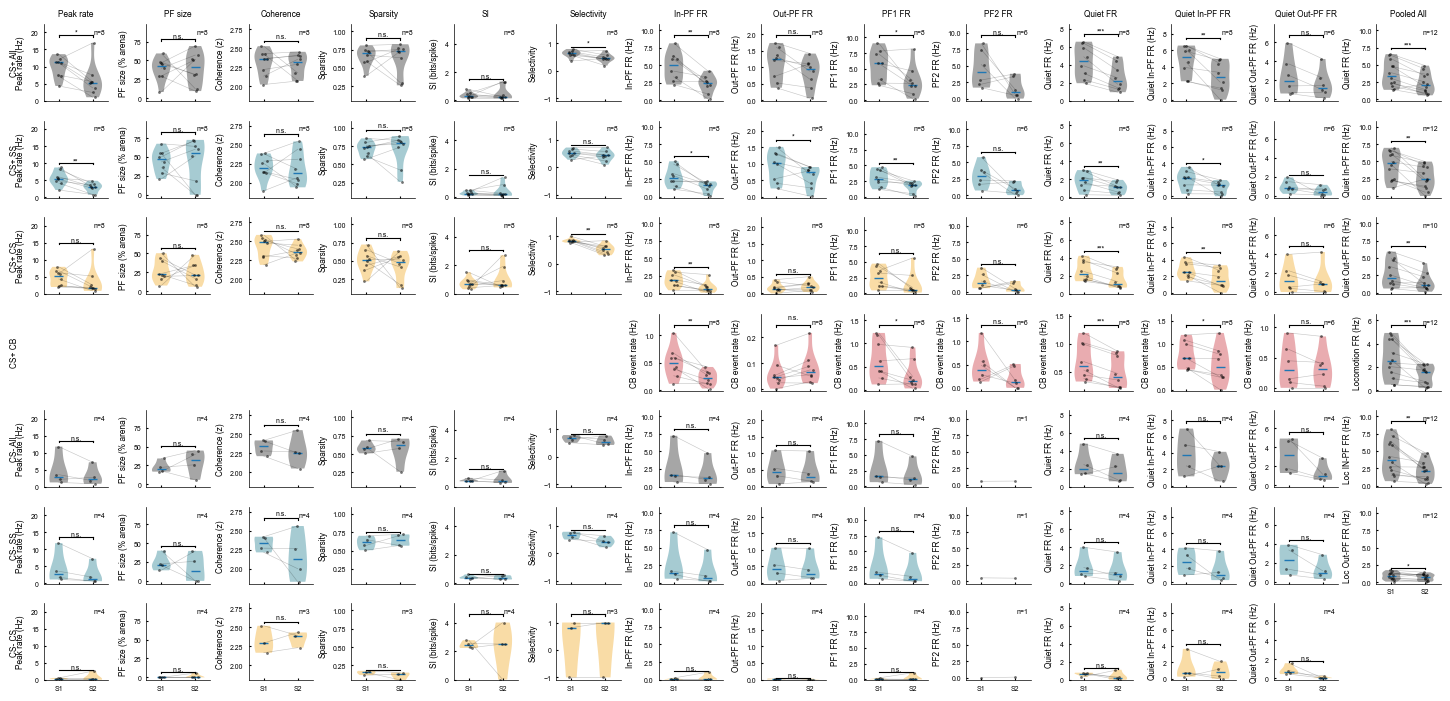

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/combined_cs_plus_minus_session1_vs_session2_metrics_14cols.svg


In [52]:
session_pair_metrics_out_path = os.path.join(figure_save_folder, 'combined_cs_plus_minus_session1_vs_session2_metrics_14cols.svg')
fig = plot_combined_cs_plus_minus_session_pair_metrics_14cols(
    session_tables=session_split_4panel_tables,
    save_path=session_pair_metrics_out_path,
    fig_width=14.5,
    fig_height=7.0,
    min_included_minutes_per_session=session_compare_params.stats_min_included_minutes_per_session,
)
plt.show()
print(f'Saved: {session_pair_metrics_out_path}')


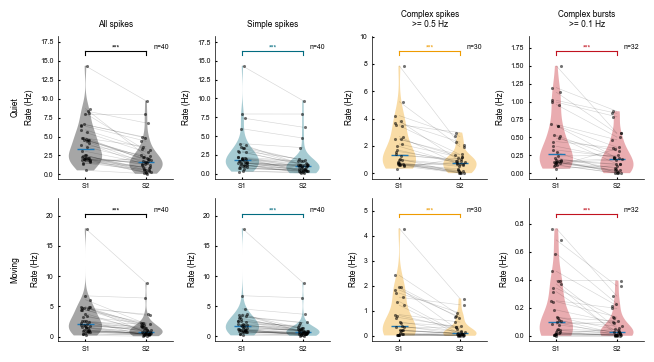

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/all_cells_session1_vs_session2_quiet_moving_rates_4cols.svg


In [53]:
all_cells_state_rates_out_path = os.path.join(
    figure_save_folder,
    'all_cells_session1_vs_session2_quiet_moving_rates_4cols.svg',
)
fig = plot_all_cells_session_state_rate_comparison_4cols(
    session_compare_groups=session_compare_groups,
    save_path=all_cells_state_rates_out_path,
    fig_width=6.5,
    fig_height=3.6,
    cs_min_rate_hz=0.5,
    cb_min_event_rate_hz=0.1,
    min_included_minutes_per_session=session_compare_params.stats_min_included_minutes_per_session,
)
plt.show()
print(f'Saved: {all_cells_state_rates_out_path}')


### Compare CB metrics between sessions

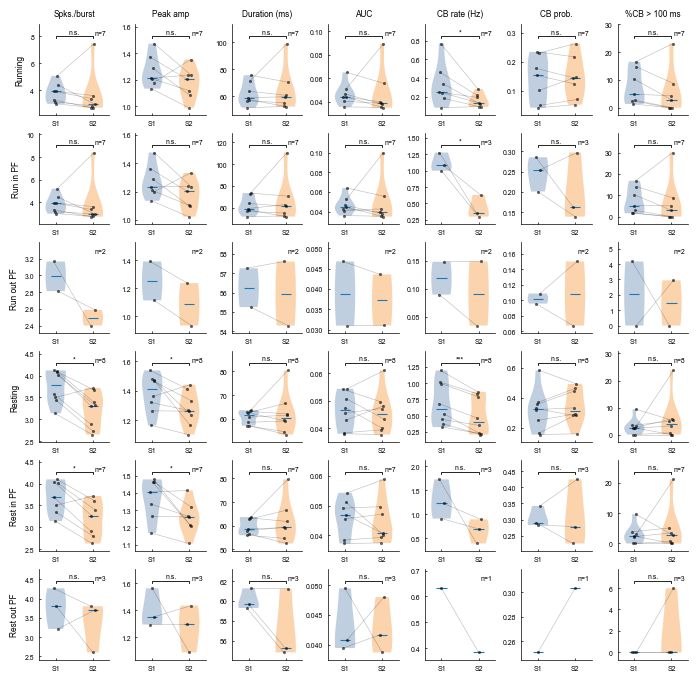

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SessionCompare_CSplus_ComplexBurstMetrics.svg
Values CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SessionCompare_CSplus_ComplexBurstMetrics_values.csv
Summary CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SessionCompare_CSplus_ComplexBurstMetrics_summary.csv
Stats CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SessionCompare_CSplus_ComplexBurstMetrics_stats.csv


,condition,condition_label,metric,metric_label,session_phase,n,mean,sem,sd,median,min,max
0,running,Running,n_spikes,Spks./burst,session1,7,3.812790,0.282344,0.747011,3.912752,2.982143,5.057851
1,running,Running,n_spikes,Spks./burst,session2,7,3.663812,0.646039,1.709258,2.956522,2.700000,7.461538
2,running,Running,peak_amp,Peak amp,session1,7,1.266089,0.045032,0.119142,1.212640,1.133387,1.472505
3,running,Running,peak_amp,Peak amp,session2,7,1.173825,0.044983,0.119013,1.203540,0.990388,1.352618
4,running,Running,duration_ms,Duration (ms),session1,7,62.151744,3.256049,8.614697,58.825911,51.476510,75.558824
...,...,...,...,...,...,...,...,...,...,...,...,...
79,rest_out,Rest out PF,burst_rate_hz,CB rate (Hz),session2,1,0.383054,NaN,NaN,0.383054,0.383054,0.383054
80,rest_out,Rest out PF,burst_prob,CB prob.,session1,1,0.250814,NaN,NaN,0.250814,0.250814,0.250814
81,rest_out,Rest out PF,burst_prob,CB prob.,session2,1,0.303030,NaN,NaN,0.303030,0.303030,0.303030
82,rest_out,Rest out PF,plateau_pct,%CB > 100 ms,session1,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,condition,condition_label,metric,metric_label,comparison,test,statistic,p_value,significance,n_pairs,shapiro_p_diff,reason
0,running,Running,n_spikes,Spks./burst,Session 1 vs Session 2,Wilcoxon signed-rank,7.000000,0.296875,n.s.,7,0.010650,
1,running,Running,peak_amp,Peak amp,Session 1 vs Session 2,Paired t-test,1.690985,0.141793,n.s.,7,0.323652,
2,running,Running,duration_ms,Duration (ms),Session 1 vs Session 2,Wilcoxon signed-rank,10.000000,0.578125,n.s.,7,0.001021,
3,running,Running,auc,AUC,Session 1 vs Session 2,Wilcoxon signed-rank,7.000000,0.296875,n.s.,7,0.000879,
4,running,Running,burst_rate_hz,CB rate (Hz),Session 1 vs Session 2,Paired t-test,2.736556,0.033890,*,7,0.394115,
5,running,Running,burst_prob,CB prob.,Session 1 vs Session 2,Paired t-test,-0.386407,0.712527,n.s.,7,0.479681,
6,running,Running,plateau_pct,%CB > 100 ms,Session 1 vs Session 2,Paired t-test,1.173185,0.285182,n.s.,7,0.412948,
7,run_in,Run in PF,n_spikes,Spks./burst,Session 1 vs Session 2,Wilcoxon signed-rank,7.000000,0.296875,n.s.,7,0.006657,
8,run_in,Run in PF,peak_amp,Peak amp,Session 1 vs Session 2,Paired t-test,1.985559,0.094295,n.s.,7,0.512887,
9,run_in,Run in PF,duration_ms,Duration (ms),Session 1 vs Session 2,Wilcoxon signed-rank,13.000000,0.937500,n.s.,7,0.000834,


Skipped cells:


,reason,animal_id,session,cell_idx,included_minutes_s1,included_minutes_s2
0,missing valid S1 or S2 panel,NaN,NaN,NaN,NaN,NaN
1,missing valid S1 or S2 panel,NaN,NaN,NaN,NaN,NaN
2,below stats_min_included_minutes_per_session,CKII_pAce47_PX_20260128,CKII_pAce47_PX_20260128,3.0,9.972267,3.993200
3,below stats_min_included_minutes_per_session,CKII_pAce50_PRL_20260317,CKII_pAce50_PRL_20260317,8.0,9.961600,2.602700
4,below stats_min_included_minutes_per_session,CKII_pAce54_PR_20260506,CKII_pAce54_PR_20260506,3.0,9.888667,1.974133
5,below stats_min_included_minutes_per_session,CKII_pAce54_PR_20260506,CKII_pAce54_PR_20260506,9.0,9.849833,3.938200
6,missing valid S1 or S2 panel,NaN,NaN,NaN,NaN,NaN
7,below stats_min_included_minutes_per_session,CKII_pAce54_PX_20260514,CKII_pAce54_PX_20260514,4.0,9.761300,0.470600


In [54]:
session_compare_cb_out_path = os.path.join(figure_save_folder, 'SessionCompare_CSplus_ComplexBurstMetrics.svg')
session_compare_cb_metrics = plot_session_compare_complex_burst_metrics(
    session_compare_groups=session_compare_groups,
    session_compare_params=session_compare_params,
    save_path=session_compare_cb_out_path,
    conditions=("running", "run_in", "run_out", "resting", "rest_in", "rest_out"),
    min_bursts_per_condition=5,
    plateau_threshold_ms=100.0,
    fig_width=7.0,
    fig_height=6.8,
    save_csv=True,
)
plt.show()
print(f"Saved: {session_compare_cb_metrics['figure_path']}")
print(f"Values CSV: {session_compare_cb_metrics['values_csv']}")
print(f"Summary CSV: {session_compare_cb_metrics['summary_csv']}")
print(f"Stats CSV: {session_compare_cb_metrics['stats_csv']}")
display(session_compare_cb_metrics["summary_df"])
display(session_compare_cb_metrics["stats_df"])
if len(session_compare_cb_metrics["skipped_df"]) > 0:
    print("Skipped cells:")
    display(session_compare_cb_metrics["skipped_df"])


### S1/S2 Correlation Statistics


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SessionCompare_S1S2_CorrelationStats.svg


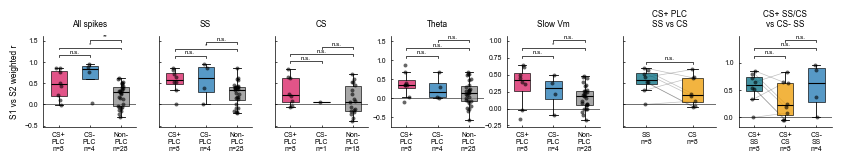

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SessionCompare_S1S2_CorrelationStats.svg


,metric,metric_label,group,n,mean,sem,sd,median,min,max,similarity_metric,similarity_label,weighted,baseline_subtraction_cosine,s1s2_min_occupancy_per_bin_s
0,all_spike,All spikes,CS+ PLC,8,0.470710,0.120302,0.340266,0.474413,-0.004535,0.866503,pearson,weighted r,True,False,0.2
1,all_spike,All spikes,CS- PLC,4,0.663929,0.214334,0.428668,0.828605,0.031672,0.966836,pearson,weighted r,True,False,0.2
2,all_spike,All spikes,Non-PLC,28,0.214491,0.050513,0.267290,0.282623,-0.306411,0.630572,pearson,weighted r,True,False,0.2
3,ss,SS,CS+ PLC,8,0.553401,0.098312,0.278067,0.585993,0.002699,0.855121,pearson,weighted r,True,False,0.2
4,ss,SS,CS- PLC,4,0.558113,0.222081,0.444161,0.624610,0.016449,0.966782,pearson,weighted r,True,False,0.2
5,ss,SS,Non-PLC,28,0.262940,0.051637,0.273237,0.350396,-0.199254,0.850338,pearson,weighted r,True,False,0.2
6,cs,CS,CS+ PLC,8,0.316076,0.120100,0.339694,0.221008,-0.054094,0.826572,pearson,weighted r,True,False,0.2
7,cs,CS,CS- PLC,1,0.047921,NaN,NaN,0.047921,0.047921,0.047921,pearson,weighted r,True,False,0.2
8,cs,CS,Non-PLC,18,0.115899,0.080370,0.340982,0.062057,-0.389805,0.713080,pearson,weighted r,True,False,0.2
9,theta,Theta,CS+ PLC,8,0.371827,0.110818,0.313441,0.358284,-0.087041,0.884602,pearson,weighted r,True,False,0.2


,metric,metric_label,comparison,group1,group2,group1_index,group2_index,test,statistic,p_value,...,n_group1,n_group2,shapiro_p_group1,shapiro_p_group2,reason,similarity_metric,similarity_label,weighted,baseline_subtraction_cosine,s1s2_min_occupancy_per_bin_s
0,all_spike,All spikes,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,Unpaired t-test,-0.855045,0.412543,...,8,4,0.407091,0.086491,,pearson,weighted r,True,False,0.2
1,all_spike,All spikes,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,0,2,Unpaired t-test,2.251602,0.030920,...,8,28,0.407091,0.229114,,pearson,weighted r,True,False,0.2
2,all_spike,All spikes,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,2,Unpaired t-test,2.924263,0.006515,...,4,28,0.086491,0.229114,,pearson,weighted r,True,False,0.2
3,ss,SS,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,Unpaired t-test,-0.022859,0.982212,...,8,4,0.389541,0.503910,,pearson,weighted r,True,False,0.2
4,ss,SS,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,0,2,Unpaired t-test,2.641998,0.012367,...,8,28,0.389541,0.122985,,pearson,weighted r,True,False,0.2
5,ss,SS,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,2,Unpaired t-test,1.873051,0.070835,...,4,28,0.503910,0.122985,,pearson,weighted r,True,False,0.2
6,cs,CS,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,n/a,NaN,NaN,...,8,1,NaN,NaN,fewer than three finite values in one or both ...,pearson,weighted r,True,False,0.2
7,cs,CS,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,0,2,Unpaired t-test,1.383108,0.179365,...,8,18,0.252628,0.291726,,pearson,weighted r,True,False,0.2
8,cs,CS,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,2,n/a,NaN,NaN,...,1,18,NaN,NaN,fewer than three finite values in one or both ...,pearson,weighted r,True,False,0.2
9,theta,Theta,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,Unpaired t-test,0.607830,0.556852,...,8,4,0.645531,0.318309,,pearson,weighted r,True,False,0.2


,comparison,group,metric1,metric2,test,statistic,p_value,significance,n_pairs,shapiro_p,shapiro_p_diff,reason,similarity_metric,similarity_label,weighted,baseline_subtraction_cosine,s1s2_min_occupancy_per_bin_s
0,CS+ PLC SS vs CS,CS+ PLC,ss,cs,Paired t-test,1.789707,0.116628,n.s.,8,0.052459,0.052459,,pearson,weighted r,True,False,0.2


In [55]:
session_compare_corr_stats_figsize = (8.4, 1.6)
session_compare_final_subplot_csminus_metric = 'ss'  # 'ss' or 'all_spike'

_s1s2_similarity_stats = session_compare_analysis.get(
    's1s2_similarity_stats_by_metric',
    session_compare_groups.get('s1s2_similarity_stats_by_metric', {}),
)

session_compare_corr_stats = plot_session_compare_correlation_stats(
    session_compare_groups,
    session_compare_params,
    figure_save_folder=figure_save_folder,
    show_plot=True,
    save_csv=True,
    figsize=session_compare_corr_stats_figsize,
    final_subplot_csminus_metric=session_compare_final_subplot_csminus_metric,
    precomputed_stats=_s1s2_similarity_stats.get('pearson', _s1s2_similarity_stats.get('weighted_pearson')),
)

print(f"Saved: {session_compare_corr_stats['figure_path']}")
display(session_compare_corr_stats['summary_df'])
display(session_compare_corr_stats['pairwise_df'])
display(session_compare_corr_stats['paired_stats_df'])


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SessionCompare_S1S2_CorrelationStats_spearman.svg


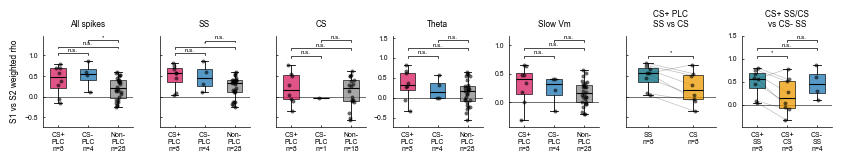

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SessionCompare_S1S2_CorrelationStats_spearman.svg


,metric,metric_label,group,n,mean,sem,sd,median,min,max,similarity_metric,similarity_label,weighted,baseline_subtraction_cosine,s1s2_min_occupancy_per_bin_s
0,all_spike,All spikes,CS+ PLC,8,0.399169,0.124993,0.353535,0.471416,-0.152179,0.794026,spearman,weighted rho,True,False,0.2
1,all_spike,All spikes,CS- PLC,4,0.529093,0.156799,0.313597,0.560146,0.119274,0.876807,spearman,weighted rho,True,False,0.2
2,all_spike,All spikes,Non-PLC,28,0.199253,0.049804,0.263536,0.208309,-0.252473,0.602149,spearman,weighted rho,True,False,0.2
3,ss,SS,CS+ PLC,8,0.490820,0.101732,0.287742,0.566910,0.044116,0.806142,spearman,weighted rho,True,False,0.2
4,ss,SS,CS- PLC,4,0.469328,0.169984,0.339968,0.450527,0.100294,0.875962,spearman,weighted rho,True,False,0.2
5,ss,SS,Non-PLC,28,0.235416,0.047741,0.252620,0.328324,-0.241292,0.600907,spearman,weighted rho,True,False,0.2
6,cs,CS,CS+ PLC,8,0.206650,0.136514,0.386121,0.153094,-0.344935,0.779540,spearman,weighted rho,True,False,0.2
7,cs,CS,CS- PLC,1,-0.041877,NaN,NaN,-0.041877,-0.041877,-0.041877,spearman,weighted rho,True,False,0.2
8,cs,CS,Non-PLC,18,0.112068,0.087201,0.369963,0.205497,-0.579947,0.632369,spearman,weighted rho,True,False,0.2
9,theta,Theta,CS+ PLC,8,0.333172,0.136486,0.386042,0.325492,-0.334356,0.835618,spearman,weighted rho,True,False,0.2


,metric,metric_label,comparison,group1,group2,group1_index,group2_index,test,statistic,p_value,...,n_group1,n_group2,shapiro_p_group1,shapiro_p_group2,reason,similarity_metric,similarity_label,weighted,baseline_subtraction_cosine,s1s2_min_occupancy_per_bin_s
0,all_spike,All spikes,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,Unpaired t-test,-0.620288,0.548942,...,8,4,0.315781,0.863691,,spearman,weighted rho,True,False,0.2
1,all_spike,All spikes,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,0,2,Unpaired t-test,1.753422,0.088542,...,8,28,0.315781,0.124225,,spearman,weighted rho,True,False,0.2
2,all_spike,All spikes,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,2,Unpaired t-test,2.294284,0.028948,...,4,28,0.863691,0.124225,,spearman,weighted rho,True,False,0.2
3,ss,SS,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,Unpaired t-test,0.115319,0.910475,...,8,4,0.168760,0.897722,,spearman,weighted rho,True,False,0.2
4,ss,SS,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,0,2,Mann-Whitney U,172.000000,0.021378,...,8,28,0.168760,0.016250,,spearman,weighted rho,True,False,0.2
5,ss,SS,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,2,Mann-Whitney U,73.000000,0.361402,...,4,28,0.897722,0.016250,,spearman,weighted rho,True,False,0.2
6,cs,CS,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,n/a,NaN,NaN,...,8,1,NaN,NaN,fewer than three finite values in one or both ...,spearman,weighted rho,True,False,0.2
7,cs,CS,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,0,2,Unpaired t-test,0.593970,0.558090,...,8,18,0.819202,0.249117,,spearman,weighted rho,True,False,0.2
8,cs,CS,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,2,n/a,NaN,NaN,...,1,18,NaN,NaN,fewer than three finite values in one or both ...,spearman,weighted rho,True,False,0.2
9,theta,Theta,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,Unpaired t-test,0.516641,0.616639,...,8,4,0.762324,0.310785,,spearman,weighted rho,True,False,0.2


,comparison,group,metric1,metric2,test,statistic,p_value,significance,n_pairs,shapiro_p,shapiro_p_diff,reason,similarity_metric,similarity_label,weighted,baseline_subtraction_cosine,s1s2_min_occupancy_per_bin_s
0,CS+ PLC SS vs CS,CS+ PLC,ss,cs,Paired t-test,3.295684,0.013199,*,8,0.29762,0.29762,,spearman,weighted rho,True,False,0.2


In [56]:
session_compare_corr_stats_figsize = (8.4, 1.6)
session_compare_final_subplot_csminus_metric = 'ss'  # 'ss' or 'all_spike'

_s1s2_similarity_stats = session_compare_analysis.get(
    's1s2_similarity_stats_by_metric',
    session_compare_groups.get('s1s2_similarity_stats_by_metric', {}),
)

session_compare_spearman_stats = plot_session_compare_correlation_stats(
    session_compare_groups,
    session_compare_params,
    figure_save_folder=figure_save_folder,
    save_name='SessionCompare_S1S2_CorrelationStats_spearman.svg',
    show_plot=True,
    save_csv=True,
    figsize=session_compare_corr_stats_figsize,
    final_subplot_csminus_metric=session_compare_final_subplot_csminus_metric,
    similarity_metric='spearman',
    precomputed_stats=_s1s2_similarity_stats.get('spearman'),
)

print(f"Saved: {session_compare_spearman_stats['figure_path']}")
display(session_compare_spearman_stats['summary_df'])
display(session_compare_spearman_stats['pairwise_df'])
display(session_compare_spearman_stats['paired_stats_df'])


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SessionCompare_S1S2_CorrelationStats_cosine.svg


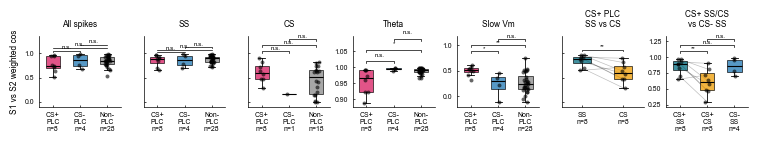

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SessionCompare_S1S2_CorrelationStats_cosine.svg


,metric,metric_label,group,n,mean,sem,sd,median,min,max,similarity_metric,similarity_label,weighted,baseline_subtraction_cosine,s1s2_min_occupancy_per_bin_s
0,all_spike,All spikes,CS+ PLC,8,0.778805,0.058458,0.165345,0.746230,0.516683,0.961599,cosine,weighted cos,True,False,0.2
1,all_spike,All spikes,CS- PLC,4,0.844523,0.072235,0.144471,0.856881,0.682492,0.981839,cosine,weighted cos,True,False,0.2
2,all_spike,All spikes,Non-PLC,28,0.846339,0.020403,0.107960,0.854335,0.532857,0.978920,cosine,weighted cos,True,False,0.2
3,ss,SS,CS+ PLC,8,0.853443,0.042199,0.119356,0.895276,0.652149,0.968752,cosine,weighted cos,True,False,0.2
4,ss,SS,CS- PLC,4,0.852607,0.066746,0.133491,0.863687,0.701309,0.981745,cosine,weighted cos,True,False,0.2
5,ss,SS,Non-PLC,28,0.876945,0.014214,0.075213,0.899126,0.730273,0.979356,cosine,weighted cos,True,False,0.2
6,cs,CS,CS+ PLC,8,0.609441,0.070645,0.199814,0.605001,0.291200,0.901349,cosine,weighted cos,True,False,0.2
7,cs,CS,CS- PLC,1,0.171166,NaN,NaN,0.171166,0.171166,0.171166,cosine,weighted cos,True,False,0.2
8,cs,CS,Non-PLC,18,0.439276,0.069299,0.294010,0.522409,0.000004,0.820567,cosine,weighted cos,True,False,0.2
9,theta,Theta,CS+ PLC,8,0.954732,0.013953,0.039464,0.965784,0.888215,0.992780,cosine,weighted cos,True,False,0.2


,metric,metric_label,comparison,group1,group2,group1_index,group2_index,test,statistic,p_value,...,n_group1,n_group2,shapiro_p_group1,shapiro_p_group2,reason,similarity_metric,similarity_label,weighted,baseline_subtraction_cosine,s1s2_min_occupancy_per_bin_s
0,all_spike,All spikes,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,Unpaired t-test,-0.673380,0.515966,...,8,4,0.248519,0.401323,,cosine,weighted cos,True,False,0.2
1,all_spike,All spikes,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,0,2,Mann-Whitney U,81.000000,0.251306,...,8,28,0.248519,0.032864,,cosine,weighted cos,True,False,0.2
2,all_spike,All spikes,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,2,Mann-Whitney U,56.000000,1.000000,...,4,28,0.401323,0.032864,,cosine,weighted cos,True,False,0.2
3,ss,SS,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,Unpaired t-test,0.011021,0.991424,...,8,4,0.114043,0.467229,,cosine,weighted cos,True,False,0.2
4,ss,SS,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,0,2,Unpaired t-test,-0.680351,0.500889,...,8,28,0.114043,0.058606,,cosine,weighted cos,True,False,0.2
5,ss,SS,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,2,Unpaired t-test,-0.549206,0.586929,...,4,28,0.467229,0.058606,,cosine,weighted cos,True,False,0.2
6,cs,CS,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,n/a,NaN,NaN,...,8,1,NaN,NaN,fewer than three finite values in one or both ...,cosine,weighted cos,True,False,0.2
7,cs,CS,CS+ PLC vs Non-PLC,CS+ PLC,Non-PLC,0,2,Mann-Whitney U,93.000000,0.260831,...,8,18,0.976066,0.035686,,cosine,weighted cos,True,False,0.2
8,cs,CS,CS- PLC vs Non-PLC,CS- PLC,Non-PLC,1,2,n/a,NaN,NaN,...,1,18,NaN,NaN,fewer than three finite values in one or both ...,cosine,weighted cos,True,False,0.2
9,theta,Theta,CS+ PLC vs CS- PLC,CS+ PLC,CS- PLC,0,1,Unpaired t-test,-1.957571,0.078753,...,8,4,0.181172,0.188040,,cosine,weighted cos,True,False,0.2


,comparison,group,metric1,metric2,test,statistic,p_value,significance,n_pairs,shapiro_p,shapiro_p_diff,reason,similarity_metric,similarity_label,weighted,baseline_subtraction_cosine,s1s2_min_occupancy_per_bin_s
0,CS+ PLC SS vs CS,CS+ PLC,ss,cs,Paired t-test,3.61941,0.008517,**,8,0.19749,0.19749,,cosine,weighted cos,True,False,0.2


In [57]:
session_compare_corr_stats_figsize = (7.6, 1.4)
session_compare_final_subplot_csminus_metric = 'ss'  # 'ss' or 'all_spike'

_s1s2_similarity_stats = session_compare_analysis.get(
    's1s2_similarity_stats_by_metric',
    session_compare_groups.get('s1s2_similarity_stats_by_metric', {}),
)

session_compare_cosine_stats = plot_session_compare_correlation_stats(
    session_compare_groups,
    session_compare_params,
    figure_save_folder=figure_save_folder,
    save_name='SessionCompare_S1S2_CorrelationStats_cosine.svg',
    show_plot=True,
    save_csv=True,
    figsize=session_compare_corr_stats_figsize,
    final_subplot_csminus_metric=session_compare_final_subplot_csminus_metric,
    similarity_metric='cosine',
    precomputed_stats=_s1s2_similarity_stats.get('cosine'),
)

print(f"Saved: {session_compare_cosine_stats['figure_path']}")
display(session_compare_cosine_stats['summary_df'])
display(session_compare_cosine_stats['pairwise_df'])
display(session_compare_cosine_stats['paired_stats_df'])


# Trial by Trial Analysis, time based

## Trial by trial plots with time windowing

In [58]:
## Trial by Trial plots + unified time-centered dataset

# Traversals are discovered with the same distance-defined closest-PF workflow used above.
# Trial stacks are fixed frame-sampled windows on seconds relative to closest PF frame.
time_centered_params = distance_centered_params if 'distance_centered_params' in globals() else PFDistanceCenteredParams(
    distance_window_cm=15.0,
    detection_window_cm=10.0,
    distance_bin_cm=1.5,
    distance_mode='euclidean_to_peak',
    center_by_pf_position=True,
    min_traversals=10,
    min_traversals_per_type=5,
    require_full_span=False,
    subtract_pre_traversal_baseline=traversal_params.subtract_pre_traversal_baseline,
    pf_component_selection=traversal_params.pf_component_selection,
    max_pf_distance_cm=traversal_params.max_pf_distance_cm,
    smooth_window=5.0,
    exclude_trials_with_bad_frames=True,
    require_movement=True,
    include_long_cb_as_plateau=True,
    cb_plateau_min_duration_ms=100.0,
)

time_defined_time_window_sec = 4.0
time_centered_display_xlim = (-4.0, 4.0)
time_defined_categories = ('CSplus', 'CSminus', 'non-PLC')

time_defined_unified_result = generate_time_defined_trials_and_dataset(
    config=config,
    spatial_data=spatial_data,
    distance_params=time_centered_params,
    figure_save_folder=figure_save_folder,
    time_window_sec=time_defined_time_window_sec,
    distance_window_cm=globals().get('distance_defined_distance_window_cm', 15.0),
    detection_window_cm=globals().get('distance_defined_detection_window_cm', 8.0),
    distance_bin_cm=globals().get('distance_defined_distance_bin_cm', 1.5),
    distance_mode=globals().get('distance_defined_distance_mode', 'euclidean_to_peak'),
    center_vicinity_min_cm=globals().get('distance_defined_center_vicinity_min_cm', 1),
    center_vicinity_max_cm=globals().get('distance_defined_center_vicinity_max_cm', 5),
    moving_speed_threshold=float(config.analysis.speed_threshold),
    resting_speed_threshold=globals().get('distance_defined_resting_speed_threshold', 0.5),
    pf_ranks=(1, 2),
    categories=time_defined_categories,
    clear_output=True,
    save_summary_csv=True,
    show_plots=False,
    show_rest_patches=True,
    pf_reliability_dilation_bins=globals().get('trial_plot_dilation_bins', 0),
    pf_reliability_dilation_shape=place_cell_params.pf_reliability_dilation_shape,
    trace_slow_gap=1.0,
    theta_slow_pad_factor=0.05,
    sharey=True,
    max_plot_trial_duration_s=20.0,
    include_long_cb_as_plateau=globals().get('distance_defined_include_long_cb_as_plateau', False),
    cb_plateau_min_duration_ms=globals().get('distance_defined_cb_plateau_min_duration_ms', 100.0),
    include_resting_plateaus=globals().get('distance_defined_include_resting_plateaus', True),
    align_all_pf_components_to_session_compare=True,
    session_compare_cache_version=globals().get('distance_defined_session_compare_cache_version', 'v2'),
)

time_defined_trial_summary = time_defined_unified_result['plot_summary']
time_centered_dataset = time_defined_unified_result['dataset']

print('Output folders:')
for cat, out_dir in time_defined_trial_summary['output_dirs'].items():
    print(f"  {cat}: {out_dir}")
print(f"Summary CSV: {time_defined_trial_summary['summary_csv']}")
print(time_defined_trial_summary['counters'])

for cat in time_centered_dataset.get('metadata', {}).get('categories', time_defined_categories):
    cat_data = time_centered_dataset.get(cat, {})
    print(f"{cat} PF1: {cat_data.get(1, {}).get('n_entries', 0)} entries (skipped={cat_data.get(1, {}).get('n_skipped', 0)})")
    print(f"{cat} PF2: {cat_data.get(2, {}).get('n_entries', 0)} entries (skipped={cat_data.get(2, {}).get('n_skipped', 0)})")
print('Time-centered metadata:')
print(time_centered_dataset.get('metadata', {}))

CKII_pAce21_PR_20250806: SNR filter kept 7/9 cells (threshold=5, min_good_minutes=5.0).


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8449: RuntimeWarning: Mean of empty slice
  "ss_pct_mean": np.nanmean(ss_pct_arr, axis=0) if np.any(np.isfinite(ss_pct_arr)) else np.full(len(distance_rel), np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8450: RuntimeWarning: Mean of empty slice
  "cs_pct_mean": np.nanmean(cs_pct_arr, axis=0) if np.any(np.isfinite(cs_pct_arr)) else np.full(len(distance_rel), np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_core.py:12035: RuntimeWarning: invalid value encountered in divide
  ss_pct = np.where(valid, 100.0 * ss_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_core.py:12036: RuntimeWarning: invalid value encountered in divide
  cs_pct = np.where(valid, 100.0 * cs_s

Plotted 10 traversal trials (10 with spikes in PF, used for average)
Plotted 12 traversal trials (11 with spikes in PF, used for average)
Plotted 12 traversal trials (11 with spikes in PF, used for average)
CKII_pAce38_PX_20251126: SNR filter kept 7/9 cells (threshold=5, min_good_minutes=5.0).
Plotted 29 traversal trials (29 with spikes in PF, used for average)
Plotted 42 traversal trials (42 with spikes in PF, used for average)
Plotted 41 traversal trials (41 with spikes in PF, used for average)
Plotted 43 traversal trials (43 with spikes in PF, used for average)
Plotted 26 traversal trials (26 with spikes in PF, used for average)
Plotted 50 traversal trials (50 with spikes in PF, used for average)
CKII_pAce45_PX_20260118: SNR filter kept 9/16 cells (threshold=5, min_good_minutes=5.0).
Plotted 39 traversal trials (39 with spikes in PF, used for average)
Plotted 39 traversal trials (39 with spikes in PF, used for average)


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8444: RuntimeWarning: Mean of empty slice
  "theta_mean": np.nanmean(theta_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8445: RuntimeWarning: Mean of empty slice
  "slow_mean": np.nanmean(slow_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8446: RuntimeWarning: Mean of empty slice
  "rate_mean": np.nanmean(rate_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8447: RuntimeWarning: Mean of empty slice
  "ss_rate_mean": np.nanmean(ss_rate_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8448: RuntimeWarning: Mean of empty slice
  "cs_rate_mean": np.nanmea

Plotted 29 traversal trials (28 with spikes in PF, used for average)
CKII_pAce47_PX_20260128: SNR filter kept 4/5 cells (threshold=5, min_good_minutes=5.0).
Plotted 30 traversal trials (28 with spikes in PF, used for average)
Plotted 25 traversal trials (24 with spikes in PF, used for average)
Plotted 27 traversal trials (22 with spikes in PF, used for average)
Plotted 25 traversal trials (25 with spikes in PF, used for average)
Plotted 21 traversal trials (18 with spikes in PF, used for average)
CKII_pAce50_PRL_20260317: SNR filter kept 9/9 cells (threshold=5, min_good_minutes=5.0).
Plotted 8 traversal trials (8 with spikes in PF, used for average)
CKII_pAce54_PR_20260506: SNR filter kept 16/16 cells (threshold=5, min_good_minutes=5.0).
Plotted 17 traversal trials (16 with spikes in PF, used for average)
Plotted 10 traversal trials (10 with spikes in PF, used for average)
Plotted 10 traversal trials (10 with spikes in PF, used for average)
CKII_pAce54_PX_20260514: SNR filter kept 6/16

In [59]:
if 'time_centered_dataset' not in globals() or time_centered_dataset is None:
    print('time_centered_dataset is missing. Run the time-defined trial generation cell first.')
else:
    print('Time-centered trial counts by category and PF rank (per cell):')
    for cat in ['CSplus', 'CSminus']:
        cat_block = time_centered_dataset.get(cat, {})
        pf1 = {(str(e.get('session', '')), int(e.get('cell_idx', -1))): int(e.get('data', {}).get('all', {}).get('n_trials', 0) or 0) for e in cat_block.get(1, {}).get('entries', [])}
        pf2 = {(str(e.get('session', '')), int(e.get('cell_idx', -1))): int(e.get('data', {}).get('all', {}).get('n_trials', 0) or 0) for e in cat_block.get(2, {}).get('entries', [])}
        keys = sorted(set(pf1) | set(pf2), key=lambda x: (x[0], x[1]))
        print(f"{cat}:")
        for session_name, cell_idx in keys:
            print(f"  {session_name} Cell{cell_idx + 1}: PF1 trials={pf1.get((session_name, cell_idx), 0)}, PF2 trials={pf2.get((session_name, cell_idx), 0)}")
        print(f"  Total: PF1 trials={sum(pf1.values())}, PF2 trials={sum(pf2.values())}; n_cells listed={len(keys)}")

Time-centered trial counts by category and PF rank (per cell):
CSplus:
  CKII_pAce21_PR_20250806 Cell2: PF1 trials=10, PF2 trials=0
  CKII_pAce21_PR_20250806 Cell3: PF1 trials=12, PF2 trials=12
  CKII_pAce38_PX_20251126 Cell4: PF1 trials=29, PF2 trials=42
  CKII_pAce38_PX_20251126 Cell6: PF1 trials=41, PF2 trials=43
  CKII_pAce38_PX_20251126 Cell7: PF1 trials=26, PF2 trials=50
  CKII_pAce45_PX_20260118 Cell5: PF1 trials=39, PF2 trials=0
  CKII_pAce45_PX_20260118 Cell12: PF1 trials=39, PF2 trials=29
  CKII_pAce47_PX_20260128 Cell1: PF1 trials=30, PF2 trials=25
  CKII_pAce47_PX_20260128 Cell3: PF1 trials=27, PF2 trials=0
  CKII_pAce47_PX_20260128 Cell4: PF1 trials=25, PF2 trials=21
  CKII_pAce50_PRL_20260317 Cell9: PF1 trials=8, PF2 trials=0
  CKII_pAce54_PR_20260506 Cell4: PF1 trials=17, PF2 trials=0
  CKII_pAce54_PR_20260506 Cell10: PF1 trials=10, PF2 trials=0
  CKII_pAce54_PR_20260506 Cell14: PF1 trials=10, PF2 trials=0
  CKII_pAce54_PX_20260514 Cell5: PF1 trials=26, PF2 trials=0
  CK

## Individual heatmaps

In [60]:
time_heatmap_smooth_window_sec = 0.5
time_avg_smooth_window_sec = 0.5

if 'time_centered_dataset' not in globals() or time_centered_dataset is None:
    print('time_centered_dataset is missing. Run the time-defined trial generation cell first.')
else:
    time_heatmap_summary = generate_pf_time_centered_component_heatmaps(
        dataset=time_centered_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        smooth_window=time_heatmap_smooth_window_sec,
        fr_vmax_scale=0.6,
        theta_vlim=(0, 0.5),
        slow_vlim=(-0.5, 0.5),
        fig_width=3.8,
        trial_height=0.02,
        xlim=time_centered_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        plateau_vlim=0.01,
        avg_smooth_window=time_avg_smooth_window_sec,
        align_all_peak_to_zero=False,
        show_plot=False,
    )
    for cat, info in time_heatmap_summary.items():
        print(f"{cat} folder: {info['output_dir']}")

PF-centered heatmaps root folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled
[CSplus] output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_time_centered_CSplus_heatmaps


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:14318: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  tight_fn()


[CSplus] 1/16 saved: CKII_pAce21_PR_20250806_Cell2_heatmap.svg
[CSplus] 2/16 saved: CKII_pAce21_PR_20250806_Cell3_heatmap.svg
[CSplus] 3/16 saved: CKII_pAce38_PX_20251126_Cell4_heatmap.svg
[CSplus] 4/16 saved: CKII_pAce38_PX_20251126_Cell6_heatmap.svg
[CSplus] 5/16 saved: CKII_pAce38_PX_20251126_Cell7_heatmap.svg
[CSplus] 6/16 saved: CKII_pAce45_PX_20260118_Cell5_heatmap.svg
[CSplus] 7/16 saved: CKII_pAce45_PX_20260118_Cell12_heatmap.svg
[CSplus] 8/16 saved: CKII_pAce47_PX_20260128_Cell1_heatmap.svg
[CSplus] 9/16 saved: CKII_pAce47_PX_20260128_Cell3_heatmap.svg
[CSplus] 10/16 saved: CKII_pAce47_PX_20260128_Cell4_heatmap.svg
[CSplus] 11/16 saved: CKII_pAce50_PRL_20260317_Cell9_heatmap.svg
[CSplus] 12/16 saved: CKII_pAce54_PR_20260506_Cell4_heatmap.svg
[CSplus] 13/16 saved: CKII_pAce54_PR_20260506_Cell10_heatmap.svg
[CSplus] 14/16 saved: CKII_pAce54_PR_20260506_Cell14_heatmap.svg
[CSplus] 15/16 saved: CKII_pAce54_PX_20260514_Cell5_heatmap.svg
[CSplus] 16/16 saved: CKII_pAce54_PX_20260514

## Compare Sessions

In [61]:
time_two_session_split_mode = globals().get('two_session_split_mode', 'time_windows')
time_two_session_split_window_minutes = globals().get('two_session_split_window_minutes', 10.0)
time_align_all_peak_to_zero = False  # x=0 remains closest PF frame
time_max_peak_adjust_sec_pf1 = None
time_max_peak_adjust_sec_pf2 = None

### Heatmaps comparing two sessions

In [62]:
if 'time_centered_dataset' not in globals() or time_centered_dataset is None:
    print('time_centered_dataset is missing. Run the time-defined trial generation cell first.')
else:
    time_heatmap_summary_2sessions = generate_pf_time_centered_component_heatmaps_2sessions(
        dataset=time_centered_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        interpolate_nan=True,
        smooth_window=time_heatmap_smooth_window_sec,
        fr_vmax_scale=0.1,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=1,
        subplot_width=0.4,
        heatmap_height=0.36,
        avg_height=0.1,
        xlim=time_centered_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=time_avg_smooth_window_sec,
        align_all_peak_to_zero=time_align_all_peak_to_zero,
        max_peak_adjust_sec_pf1=time_max_peak_adjust_sec_pf1,
        max_peak_adjust_sec_pf2=time_max_peak_adjust_sec_pf2,
        avg_ylim_focus_window=(-1.0, 1.0),
        disable_pf2_avg_ylim_sync=True,
        split_mode=time_two_session_split_mode,
        split_window_minutes=time_two_session_split_window_minutes,
        print_peak_shift_bins=False,
        show_plot=False,
        rate_colorbar_vmax=10,
    )
    for cat, info in time_heatmap_summary_2sessions.items():
        print(f"{cat} folder (2 sessions): {info['output_dir']}")

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:16206: RuntimeWarning: Mean of empty slice
  np.asarray(np.nanmean(ss_pct_stack, axis=0), dtype=float)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:16212: RuntimeWarning: Mean of empty slice
  np.asarray(np.nanmean(cs_pct_stack, axis=0), dtype=float)


PF-centered (2 sessions) heatmaps root folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled
[CSplus] output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_time_centered_2sessions_CSplus_heatmaps
[CSplus] 1/16 saved: CKII_pAce21_PR_20250806_Cell2_heatmap_2sessions.svg
[CSplus] 2/16 saved: CKII_pAce21_PR_20250806_Cell3_heatmap_2sessions.svg
[CSplus] 3/16 saved: CKII_pAce38_PX_20251126_Cell4_heatmap_2sessions.svg
[CSplus] 4/16 saved: CKII_pAce38_PX_20251126_Cell6_heatmap_2sessions.svg
[CSplus] 5/16 saved: CKII_pAce38_PX_20251126_Cell7_heatmap_2sessions.svg
[CSplus] 6/16 saved: CKII_pAce45_PX_20260118_Cell5_heatmap_2sessions.svg
[CSplus] 7/16 saved: CKII_pAce45_PX_20260118_Cell12_heatmap_2sessions.svg
[CSplus] 8/16 saved: CKII_pAce47_PX_20260128_Cell1_heatmap_2sessions.svg
[CSplus] 9/16 saved: CKII_pAce47_PX_20260128_Cell3_heatmap_2sessions.svg
[CSplus] 10/16

### Average Plot, comparing two sessions

PF FR norm denominator mode=zero_then_peak: zero=8, peak fallback=0, invalid=0
PF FR norm denominator mode=zero_then_peak: zero=7, peak fallback=0, invalid=0
[CS+ PLCs] n (PF1): combined=8, S1=8, S2=8
[CS+ PLCs] n (PF2): combined=7, S1=7, S2=7


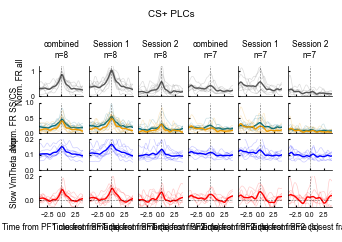

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_time_centered_CSplus_average_primary_secondary_2sessions.svg


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:20463: RuntimeWarning: Mean of empty slice
  return np.nanmean(stack, axis=0)


PF FR norm denominator mode=zero_then_peak: zero=4, peak fallback=0, invalid=0
PF FR norm denominator mode=zero_then_peak: zero=1, peak fallback=0, invalid=0
[CS- PLCs] n (PF1): combined=4, S1=4, S2=4
[CS- PLCs] n (PF2): combined=1, S1=1, S2=1


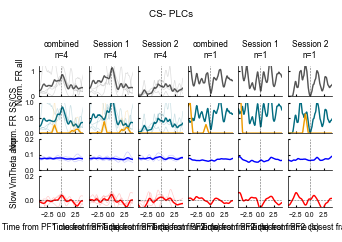

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_time_centered_CSminus_average_primary_secondary_2sessions.svg


In [63]:
if 'time_centered_dataset' not in globals() or time_centered_dataset is None:
    print('time_centered_dataset is missing. Run the time-defined trial generation cell first.')
else:
    time_min_trials_per_column_2sessions = globals().get('min_trials_per_column_2sessions', 4)
    time_session_average_export_stage = globals().get('distance_session_average_export_stage', 'post')
    time_session_enforce_min_traversals_on_saved_exports = globals().get('distance_session_enforce_min_traversals_on_saved_exports', False)
    time_session_fr_norm_reference_col = globals().get('distance_session_fr_norm_reference_col', 'session1')
    time_fr_norm_denominator_mode = 'zero_then_peak'
    time_average_export_dir_2sessions = os.path.join(figure_save_folder, 'pf_time_centered_2sessions_average_exports')
    time_common_plot_kwargs = dict(
        smooth_window=time_heatmap_smooth_window_sec,
        avg_smooth_window=time_avg_smooth_window_sec,
        plot_trials=True,
        trial_alpha=0.2,
        trial_linewidth=0.5,
        theta_ylim=(0, 0.2),
        slow_ylim=(-0.05, 0.2),
        fr_ylim_scale=1.2,
        ss_cs_ylim_scale=1.2,
        figsize_per_block=(3.4, 1.8),
        xlim=time_centered_display_xlim,
        fr_row_ylim_max=1.2,
        show_plot=True,
        align_all_peak_to_zero=time_align_all_peak_to_zero,
        max_peak_adjust_sec_pf1=time_max_peak_adjust_sec_pf1,
        max_peak_adjust_sec_pf2=time_max_peak_adjust_sec_pf2,
        min_traversals_per_type=distance_centered_params.min_traversals_per_type,
        min_trials_per_column=time_min_trials_per_column_2sessions,
        use_saved_average_exports=True,
        average_export_dir=time_average_export_dir_2sessions,
        average_export_stage=time_session_average_export_stage,
        enforce_min_traversals_on_saved_exports=time_session_enforce_min_traversals_on_saved_exports,
        merge_ss_cs_subplots=True,
        require_both_sessions_for_pf=True,
        fr_norm_reference_col=time_session_fr_norm_reference_col,
        fr_norm_denominator_mode=time_fr_norm_denominator_mode,
        show_sem_shading=False,
        split_mode=time_two_session_split_mode,
        split_window_minutes=time_two_session_split_window_minutes,
    )
    for category_name, title_text, filename in [
        ('CSplus', 'CS+ PLCs', 'pf_time_centered_CSplus_average_primary_secondary_2sessions.svg'),
        ('CSminus', 'CS- PLCs', 'pf_time_centered_CSminus_average_primary_secondary_2sessions.svg'),
    ]:
        out_path = os.path.join(figure_save_folder, filename)
        plot_pf_time_centered_category_primary_secondary_from_dataset_2sessions(
            dataset=time_centered_dataset,
            category=category_name,
            title=title_text,
            out_path=out_path,
            **time_common_plot_kwargs,
        )
        print(f'Generated: {out_path}')


In [64]:
# Time-vs-distance 2-session inclusion diagnostics
import csv
from pathlib import Path
import numpy as np

def _diag_to_int(value, default=0):
    try:
        if value is None or value == '':
            return int(default)
        return int(float(value))
    except Exception:
        return int(default)

def _diag_trace(npz, key):
    if key not in npz:
        return np.array([], dtype=float)
    return np.asarray(npz[key], dtype=float).reshape(-1)

def _diag_fr_denom(trace, zero_idx, mode):
    arr = np.asarray(trace, dtype=float).reshape(-1)
    if arr.size == 0:
        return np.nan, 'invalid trace'
    zero = arr[int(zero_idx)] if 0 <= int(zero_idx) < arr.size else np.nan
    if np.isfinite(zero) and not np.isclose(zero, 0.0):
        return float(zero), 'zero'
    if str(mode).lower() == 'zero_then_peak':
        finite = arr[np.isfinite(arr)]
        if finite.size:
            peak = float(np.nanmax(finite))
            if np.isfinite(peak) and not np.isclose(peak, 0.0):
                return peak, 'peak fallback'
    return np.nan, 'normalization denominator unavailable'

def _session_export_inclusion(export_dir, category, pf_rank, *, min_trials_per_column, fr_norm_reference_col, fr_norm_denominator_mode, stage='post'):
    export_dir = Path(export_dir)
    index_csv = export_dir / category / 'session_averages_pre_post_index.csv'
    eligible = set()
    reasons = {}
    if not index_csv.exists():
        return eligible, {('*', int(pf_rank)): f'missing export index: {index_csv}'}
    min_req = 0 if min_trials_per_column is None else int(min_trials_per_column)
    with index_csv.open(newline='') as f:
        rows = list(csv.DictReader(f))
    for row in rows:
        animal = str(row.get('animal_id', ''))
        cell_idx = _diag_to_int(row.get('cell_idx', -1), -1)
        key = (animal, cell_idx, int(pf_rank))
        npz_path = Path(str(row.get('npz_path', '')))
        if not npz_path.exists():
            reasons[key] = 'missing export npz'
            continue
        n1 = _diag_to_int(row.get(f'n_trials_pf{pf_rank}_s1', 0), 0)
        n2 = _diag_to_int(row.get(f'n_trials_pf{pf_rank}_s2', 0), 0)
        if min(n1, n2) < min_req:
            reasons[key] = f'low trial count: S1={n1}, S2={n2}, required>={min_req}'
            continue
        try:
            with np.load(npz_path, allow_pickle=True) as npz:
                rel = _diag_trace(npz, f'distance_rel_pf{pf_rank}')
                if rel.size == 0:
                    reasons[key] = 'invalid trace: missing axis'
                    continue
                zero_idx = int(np.nanargmin(np.abs(rel)))
                ref_col = str(fr_norm_reference_col).lower()
                if ref_col == 'session2':
                    ref_trace = _diag_trace(npz, f'{stage}_pf{pf_rank}_s2_all_spike')
                elif ref_col == 'all':
                    t1 = _diag_trace(npz, f'{stage}_pf{pf_rank}_s1_all_spike')
                    t2 = _diag_trace(npz, f'{stage}_pf{pf_rank}_s2_all_spike')
                    ref_trace = np.nanmean(np.vstack([t for t in (t1, t2) if t.size == rel.size]), axis=0) if (t1.size == rel.size or t2.size == rel.size) else np.array([], dtype=float)
                else:
                    ref_trace = _diag_trace(npz, f'{stage}_pf{pf_rank}_s1_all_spike')
                if ref_trace.size != rel.size or not np.any(np.isfinite(ref_trace)):
                    reasons[key] = 'invalid trace: reference all-spike trace unavailable'
                    continue
                denom, denom_reason = _diag_fr_denom(ref_trace, zero_idx, fr_norm_denominator_mode)
                if not np.isfinite(denom):
                    reasons[key] = denom_reason
                    continue
        except Exception as exc:
            reasons[key] = f'invalid trace: {exc}'
            continue
        eligible.add(key)
    return eligible, reasons

if 'time_centered_dataset' not in globals() or time_centered_dataset is None:
    print('time_centered_dataset is missing. Run the time-defined trial generation cell first.')
else:
    _distance_session_export_dir = globals().get('average_export_dir_2sessions', os.path.join(figure_save_folder, 'pf_distance_centered_2sessions_average_exports'))
    _time_session_export_dir = globals().get('time_average_export_dir_2sessions', os.path.join(figure_save_folder, 'pf_time_centered_2sessions_average_exports'))
    print('2-session inclusion diagnostic: distance vs time')
    for _cat in ('CSplus', 'CSminus'):
        for _pf in (1, 2):
            _dist_keys, _dist_reasons = _session_export_inclusion(
                _distance_session_export_dir,
                _cat,
                _pf,
                min_trials_per_column=globals().get('min_trials_per_column_2sessions', 4),
                fr_norm_reference_col=globals().get('distance_session_fr_norm_reference_col', 'session1'),
                fr_norm_denominator_mode=globals().get('distance_session_fr_norm_denominator_mode', 'zero'),
                stage=globals().get('distance_session_average_export_stage', 'post'),
            )
            _time_keys, _time_reasons = _session_export_inclusion(
                _time_session_export_dir,
                _cat,
                _pf,
                min_trials_per_column=globals().get('time_min_trials_per_column_2sessions', 4),
                fr_norm_reference_col=globals().get('time_session_fr_norm_reference_col', 'session1'),
                fr_norm_denominator_mode=globals().get('time_fr_norm_denominator_mode', 'zero_then_peak'),
                stage=globals().get('time_session_average_export_stage', 'post'),
            )
            print(f'  {_cat} PF{_pf}: distance n={len(_dist_keys)}, time n={len(_time_keys)}')
            _missing = sorted(_dist_keys - _time_keys)
            _extra = sorted(_time_keys - _dist_keys)
            if _missing:
                print('    Missing from time:')
                for _key in _missing:
                    print(f'      {_key[0]} Cell{_key[1] + 1} PF{_key[2]}: {_time_reasons.get(_key, "not present in time export")}')
            if _extra:
                print('    Extra in time:')
                for _key in _extra:
                    print(f'      {_key[0]} Cell{_key[1] + 1} PF{_key[2]}: distance reason={_dist_reasons.get(_key, "not present in distance export")}')


2-session inclusion diagnostic: distance vs time
  CSplus PF1: distance n=8, time n=8
  CSplus PF2: distance n=4, time n=7
    Extra in time:
      CKII_pAce38_PX_20251126 Cell4 PF2: distance reason=low trial count: S1=0, S2=0, required>=4
      CKII_pAce45_PX_20260118 Cell12 PF2: distance reason=low trial count: S1=0, S2=0, required>=4
      CKII_pAce54_PX_20260514 Cell10 PF2: distance reason=low trial count: S1=0, S2=0, required>=4
  CSminus PF1: distance n=4, time n=4
  CSminus PF2: distance n=1, time n=1


### Statistics

In [65]:
time_stability_min_traversals_per_session = 0
time_stability_smooth_window_sec = 0.0
time_stability_auc_window_sec = None
time_stability_slow_auc_window_sec = (-4.0, 4.0)
time_stability_peak_window_sec = (-4.0, 4.0)
time_stability_figsize = (3.2, 2.3)

if 'time_centered_dataset' not in globals() or time_centered_dataset is None:
    print('time_centered_dataset is missing. Run the time-defined trial generation cell first.')
else:
    time_stability_results = compute_pf_time_centered_session_stability(
        time_centered_dataset,
        min_traversals_per_session=time_stability_min_traversals_per_session,
        smooth_window_sec=time_stability_smooth_window_sec,
        auc_window_sec=time_stability_auc_window_sec,
        slow_auc_window_sec=time_stability_slow_auc_window_sec,
        peak_window_sec=time_stability_peak_window_sec,
        min_trials_per_column_2sessions=time_min_trials_per_column_2sessions,
        average_export_dir=time_average_export_dir_2sessions,
        split_mode=time_two_session_split_mode,
        split_window_minutes=time_two_session_split_window_minutes,
        strict_follow_plot_inclusion=True,
        print_nan_diagnostics=True,
    )
    print(f"Skipped counts: {time_stability_results.get('skipped_counts', {})}")
    time_stability_plot_summary = plot_pf_time_centered_session_stability(
        time_stability_results,
        figure_save_folder=figure_save_folder,
        figsize=time_stability_figsize,
        row_height=1.2,
        show_plot=False,
        save_csv=True,
    )
    print('Time-centered stability outputs:')
    print(f"  Per-cell CSV: {time_stability_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {time_stability_plot_summary.get('stats_csv')}")
    for metric_name, fig_path in time_stability_plot_summary.get('figure_paths', {}).items():
        print(f"  {metric_name}: {fig_path}")

[session_stability] Cells/metrics with NaN values (flat/invalid traces):
  group=CSplus_PF1, metric=cs, cell=CKII_pAce47_PX_20260128_Cell3, n_s1=20, n_s2=7, overlap_bins=4001, cosine_bins=4001, auc_bins=4001, peak_bins=4001, reasons=r:flat_trace_session2; r_set_to_zero
  group=CSplus_PF2, metric=cs, cell=CKII_pAce47_PX_20260128_Cell4, n_s1=16, n_s2=5, overlap_bins=4001, cosine_bins=4001, auc_bins=4001, peak_bins=4001, reasons=r:flat_trace_session2; r_set_to_zero
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell5, n_s1=19, n_s2=24, overlap_bins=4001, cosine_bins=4001, auc_bins=4001, peak_bins=4001, reasons=r:flat_trace_session2; r_set_to_zero
  group=CSminus_PF1, metric=cs, cell=CKII_pAce45_PX_20260118_Cell3, n_s1=24, n_s2=26, overlap_bins=4001, cosine_bins=4001, auc_bins=4001, peak_bins=4001, reasons=r:flat_trace_session2; r_set_to_zero
  group=CSminus_PF1, metric=cs, cell=CKII_pAce54_PR_20260506_Cell2, n_s1=10, n_s2=4, overlap_bins=4001, cosine_bins=4001, auc_bins=4001

## Compare directions

In [66]:
time_direction_avg_mode = globals().get('direction_avg_mode', 'combined')  # combined, S1, or S2
time_direction_smooth_window_sec = time_heatmap_smooth_window_sec
time_direction_avg_smooth_window_sec = time_avg_smooth_window_sec
time_direction_min_traversals_per_type = globals().get('direction_min_traversals_per_type', distance_centered_params.min_traversals_per_type)
time_direction_min_trials_per_column = globals().get('direction_min_trials_per_column', None)
time_direction_average_export_stage = globals().get('direction_average_export_stage', 'post')
time_direction_enforce_min_traversals_on_saved_exports = globals().get('direction_enforce_min_traversals_on_saved_exports', False)
time_direction_fr_norm_reference_col = globals().get('direction_fr_norm_reference_col', 'all')
time_direction_fr_norm_denominator_mode = globals().get('direction_fr_norm_denominator_mode', 'zero')
time_direction_show_column_counts_in_titles = globals().get('direction_show_column_counts_in_titles', True)
time_direction_average_export_subdir = 'pf_time_centered_2directions_average_exports'



### Heatmaps comparing CW and CCW

In [67]:
if 'time_centered_dataset' not in globals() or time_centered_dataset is None:
    print('time_centered_dataset is missing. Run the time-defined trial generation cell first.')
else:
    time_heatmap_summary_2directions = generate_pf_time_centered_component_heatmaps_2directions(
        dataset=time_centered_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        smooth_window=time_direction_smooth_window_sec,
        fr_vmax_scale=0.1,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=1,
        subplot_width=0.4,
        heatmap_height=0.36,
        avg_height=0.1,
        xlim=time_centered_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=time_direction_avg_smooth_window_sec,
        align_all_peak_to_zero=time_align_all_peak_to_zero,
        max_peak_adjust_sec_pf1=time_max_peak_adjust_sec_pf1,
        max_peak_adjust_sec_pf2=time_max_peak_adjust_sec_pf2,
        avg_theta_ylim=None,
        avg_slow_ylim=None,
        disable_pf2_avg_ylim_sync=True,
        avg_mode=time_direction_avg_mode,
        save_average_exports=True,
        average_export_subdir=time_direction_average_export_subdir,
        print_peak_shift_bins=False,
        show_plot=False,
        rate_colorbar_vmax=10,
    )
    for cat, info in time_heatmap_summary_2directions.items():
        print(f"{cat} folder (2 directions): {info['output_dir']}")


[CSplus] output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_time_centered_2directions_CSplus_heatmaps
[CSplus] 1/16 saved: CKII_pAce21_PR_20250806_Cell2_heatmap_2directions.svg
[CSplus] 2/16 saved: CKII_pAce21_PR_20250806_Cell3_heatmap_2directions.svg
[CSplus] 3/16 saved: CKII_pAce38_PX_20251126_Cell4_heatmap_2directions.svg
[CSplus] 4/16 saved: CKII_pAce38_PX_20251126_Cell6_heatmap_2directions.svg
[CSplus] 5/16 saved: CKII_pAce38_PX_20251126_Cell7_heatmap_2directions.svg
[CSplus] 6/16 saved: CKII_pAce45_PX_20260118_Cell5_heatmap_2directions.svg
[CSplus] 7/16 saved: CKII_pAce45_PX_20260118_Cell12_heatmap_2directions.svg
[CSplus] 8/16 saved: CKII_pAce47_PX_20260128_Cell1_heatmap_2directions.svg
[CSplus] 9/16 saved: CKII_pAce47_PX_20260128_Cell3_heatmap_2directions.svg
[CSplus] 10/16 saved: CKII_pAce47_PX_20260128_Cell4_heatmap_2directions.svg
[CSplus] 11/16 saved: CKII_pAce50_PRL_20260317_Cell9_heatmap_2directions

### Grand Average, comparing directions

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:20976: RuntimeWarning: Mean of empty slice
  dir_data["ss_pct_mean"] = np.nanmean(ss_pct, axis=0) if ss_pct.size > 0 else np.full(n_time, np.nan, dtype=float)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:20977: RuntimeWarning: Mean of empty slice
  dir_data["cs_pct_mean"] = np.nanmean(cs_pct, axis=0) if cs_pct.size > 0 else np.full(n_time, np.nan, dtype=float)


PF1 counts: All (n=16), Pref (n=16), Non-pref (n=16)
PF1 FR norm denominator mode=zero: zero=16, peak fallback=0, external=0, invalid/skipped=0
PF2 counts: All (n=8), Pref (n=8), Non-pref (n=8)
PF2 FR norm denominator mode=zero: zero=0, peak fallback=0, external=8, invalid/skipped=0


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:14886: RuntimeWarning: Mean of empty slice
  trace = np.nanmean(stack, axis=0)


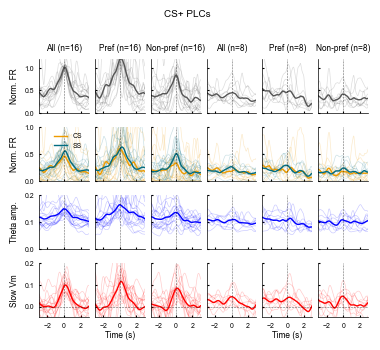

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_time_centered_CSplus_average_primary_secondary_2directions.svg
PF1 counts: All (n=8), Pref (n=8), Non-pref (n=8)
PF1 FR norm denominator mode=zero: zero=8, peak fallback=0, external=0, invalid/skipped=0
PF2 counts: All (n=2), Pref (n=2), Non-pref (n=2)
PF2 FR norm denominator mode=zero: zero=0, peak fallback=0, external=2, invalid/skipped=0


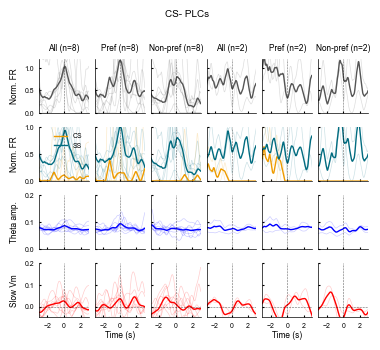

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_time_centered_CSminus_average_primary_secondary_2directions.svg


In [68]:
if 'time_centered_dataset' not in globals() or time_centered_dataset is None:
    print('time_centered_dataset is missing. Run the time-defined trial generation cell first.')
else:
    time_direction_average_export_dir = os.path.join(figure_save_folder, time_direction_average_export_subdir)
    time_direction_common_plot_kwargs = dict(
        smooth_window=time_direction_smooth_window_sec,
        avg_smooth_window=time_direction_avg_smooth_window_sec,
        plot_trials=True,
        trial_alpha=0.2,
        trial_linewidth=0.5,
        theta_ylim=(0, 0.2),
        slow_ylim=(-0.05, 0.2),
        fr_ylim_scale=1.2,
        ss_cs_ylim_scale=1.2,
        figsize_per_block=(3.8, 3.5),
        xlim=(-3.0, 3.0),
        x_ticks=[ -2,  0, 2],
        fr_row_ylim_max=1.2,
        ss_cs_row_ylim_max=1.0,
        align_all_peak_to_zero=time_align_all_peak_to_zero,
        max_peak_adjust_sec_pf1=time_max_peak_adjust_sec_pf1,
        max_peak_adjust_sec_pf2=time_max_peak_adjust_sec_pf2,
        min_traversals_per_type=time_direction_min_traversals_per_type,
        min_trials_per_column=time_direction_min_trials_per_column,
        use_saved_average_exports=True,
        average_export_dir=time_direction_average_export_dir,
        average_export_stage=time_direction_average_export_stage,
        avg_mode=time_direction_avg_mode,
        enforce_min_traversals_on_saved_exports=time_direction_enforce_min_traversals_on_saved_exports,
        fr_norm_reference_col=time_direction_fr_norm_reference_col,
        fr_norm_denominator_mode=time_direction_fr_norm_denominator_mode,
        show_sem_shading=False,
        show_column_counts_in_titles=time_direction_show_column_counts_in_titles,
        show_plot=True,
    )
    for category_name, title_text, filename in [
        ('CSplus', 'CS+ PLCs', 'pf_time_centered_CSplus_average_primary_secondary_2directions.svg'),
        ('CSminus', 'CS- PLCs', 'pf_time_centered_CSminus_average_primary_secondary_2directions.svg'),
    ]:
        out_path = os.path.join(figure_save_folder, filename)
        plot_pf_time_centered_category_primary_secondary_from_dataset_2directions(
            dataset=time_centered_dataset,
            category=category_name,
            title=title_text,
            out_path=out_path,
            **time_direction_common_plot_kwargs,
        )
        print(f'Generated: {out_path}')


In [69]:
# Time-vs-distance direction-grand-average inclusion diagnostics
import csv
from pathlib import Path
import numpy as np

def _diag_to_int(value, default=0):
    try:
        if value is None or value == '':
            return int(default)
        return int(float(value))
    except Exception:
        return int(default)

def _diag_trace(npz, key):
    if key not in npz:
        return np.array([], dtype=float)
    return np.asarray(npz[key], dtype=float).reshape(-1)

def _diag_fr_denom(trace, zero_idx, mode):
    arr = np.asarray(trace, dtype=float).reshape(-1)
    if arr.size == 0:
        return np.nan, 'invalid trace'
    zero = arr[int(zero_idx)] if 0 <= int(zero_idx) < arr.size else np.nan
    if np.isfinite(zero) and not np.isclose(zero, 0.0):
        return float(zero), 'zero'
    if str(mode).lower() == 'zero_then_peak':
        finite = arr[np.isfinite(arr)]
        if finite.size:
            peak = float(np.nanmax(finite))
            if np.isfinite(peak) and not np.isclose(peak, 0.0):
                return peak, 'peak fallback'
    return np.nan, 'normalization denominator unavailable'

def _diag_pref_nonpref_from_traces(cw_trace, ccw_trace):
    cw = np.asarray(cw_trace, dtype=float).reshape(-1)
    ccw = np.asarray(ccw_trace, dtype=float).reshape(-1)
    cw_peak = float(np.nanmax(cw)) if cw.size and np.any(np.isfinite(cw)) else np.nan
    ccw_peak = float(np.nanmax(ccw)) if ccw.size and np.any(np.isfinite(ccw)) else np.nan
    if not np.isfinite(cw_peak) and not np.isfinite(ccw_peak):
        return None, None
    if np.isfinite(cw_peak) and (not np.isfinite(ccw_peak) or cw_peak >= ccw_peak):
        return 'cw', 'ccw'
    return 'ccw', 'cw'

def _direction_export_inclusion(export_dir, category, pf_rank, *, min_traversals_per_type, min_trials_per_column, avg_mode, fr_norm_reference_col, fr_norm_denominator_mode, stage='post'):
    export_dir = Path(export_dir)
    index_csv = export_dir / category / 'session_averages_pre_post_index.csv'
    eligible = set()
    reasons = {}
    if not index_csv.exists():
        return eligible, {('*', int(pf_rank)): f'missing export index: {index_csv}'}
    min_req = int(min_trials_per_column) if min_trials_per_column is not None else int(min_traversals_per_type)
    with index_csv.open(newline='') as f:
        rows = list(csv.DictReader(f))
    for row in rows:
        animal = str(row.get('animal_id', ''))
        cell_idx = _diag_to_int(row.get('cell_idx', -1), -1)
        key = (animal, cell_idx, int(pf_rank))
        npz_path = Path(str(row.get('npz_path', '')))
        if not npz_path.exists():
            reasons[key] = 'missing export npz'
            continue
        try:
            with np.load(npz_path, allow_pickle=True) as npz:
                rel = _diag_trace(npz, f'distance_rel_pf{pf_rank}')
                if rel.size == 0:
                    reasons[key] = 'invalid trace: missing axis'
                    continue
                cw_trace = _diag_trace(npz, f'{stage}_pf{pf_rank}_cw_{avg_mode}_all_spike')
                ccw_trace = _diag_trace(npz, f'{stage}_pf{pf_rank}_ccw_{avg_mode}_all_spike')
                pref, nonpref = _diag_pref_nonpref_from_traces(cw_trace, ccw_trace)
                if pref is None or nonpref is None:
                    reasons[key] = 'invalid trace: cannot infer preferred direction'
                    continue
                low_counts = []
                for direction in ('all', pref, nonpref):
                    n = _diag_to_int(row.get(f'n_trials_pf{pf_rank}_{direction}_{avg_mode}', 0), 0)
                    if n < min_req:
                        low_counts.append(f'{direction}={n}')
                if low_counts:
                    reasons[key] = f'low trial count: {", ".join(low_counts)}, required>={min_req}'
                    continue
                ref_col = str(fr_norm_reference_col).lower()
                ref_dir = {'all': 'all', 'preferred': pref, 'pref': pref, 'nonpreferred': nonpref, 'non-pref': nonpref}.get(ref_col, pref)
                ref_trace = _diag_trace(npz, f'{stage}_pf{pf_rank}_{ref_dir}_{avg_mode}_all_spike')
                if ref_trace.size != rel.size or not np.any(np.isfinite(ref_trace)):
                    reasons[key] = 'invalid trace: reference all-spike trace unavailable'
                    continue
                zero_idx = int(np.nanargmin(np.abs(rel)))
                denom, denom_reason = _diag_fr_denom(ref_trace, zero_idx, fr_norm_denominator_mode)
                if not np.isfinite(denom):
                    reasons[key] = denom_reason
                    continue
        except Exception as exc:
            reasons[key] = f'invalid trace: {exc}'
            continue
        eligible.add(key)
    return eligible, reasons

if 'time_centered_dataset' not in globals() or time_centered_dataset is None:
    print('time_centered_dataset is missing. Run the time-defined trial generation cell first.')
else:
    _distance_direction_export_dir = globals().get('direction_average_export_dir', os.path.join(figure_save_folder, 'pf_distance_centered_2directions_average_exports'))
    _time_direction_export_dir = globals().get('time_direction_average_export_dir', os.path.join(figure_save_folder, 'pf_time_centered_2directions_average_exports'))
    _distance_direction_min_trav = 0 if not globals().get('direction_enforce_min_traversals_on_saved_exports', False) else distance_centered_params.min_traversals_per_type
    _time_direction_min_trav = 0 if not globals().get('time_direction_enforce_min_traversals_on_saved_exports', False) else time_direction_min_traversals_per_type
    print('Direction grand-average inclusion diagnostic: distance vs time')
    for _cat in ('CSplus', 'CSminus'):
        for _pf in (1, 2):
            _dist_keys, _dist_reasons = _direction_export_inclusion(
                _distance_direction_export_dir,
                _cat,
                _pf,
                min_traversals_per_type=_distance_direction_min_trav,
                min_trials_per_column=globals().get('direction_min_trials_per_column', None),
                avg_mode=globals().get('direction_avg_mode', 'combined'),
                fr_norm_reference_col=globals().get('direction_fr_norm_reference_col', 'all'),
                fr_norm_denominator_mode=globals().get('direction_fr_norm_denominator_mode', 'zero'),
                stage=globals().get('direction_average_export_stage', 'post'),
            )
            _time_keys, _time_reasons = _direction_export_inclusion(
                _time_direction_export_dir,
                _cat,
                _pf,
                min_traversals_per_type=_time_direction_min_trav,
                min_trials_per_column=globals().get('time_direction_min_trials_per_column', None),
                avg_mode=globals().get('time_direction_avg_mode', 'combined'),
                fr_norm_reference_col=globals().get('time_direction_fr_norm_reference_col', 'all'),
                fr_norm_denominator_mode=globals().get('time_direction_fr_norm_denominator_mode', 'zero'),
                stage=globals().get('time_direction_average_export_stage', 'post'),
            )
            print(f'  {_cat} PF{_pf}: distance n={len(_dist_keys)}, time n={len(_time_keys)}')
            _missing = sorted(_dist_keys - _time_keys)
            _extra = sorted(_time_keys - _dist_keys)
            if _missing:
                print('    Missing from time:')
                for _key in _missing:
                    print(f'      {_key[0]} Cell{_key[1] + 1} PF{_key[2]}: {_time_reasons.get(_key, "not present in time export")}')
            if _extra:
                print('    Extra in time:')
                for _key in _extra:
                    print(f'      {_key[0]} Cell{_key[1] + 1} PF{_key[2]}: distance reason={_dist_reasons.get(_key, "not present in distance export")}')


Direction grand-average inclusion diagnostic: distance vs time
  CSplus PF1: distance n=16, time n=16
  CSplus PF2: distance n=5, time n=8
    Missing from time:
      CKII_pAce54_PR_20260506 Cell14 PF2: invalid trace: cannot infer preferred direction
    Extra in time:
      CKII_pAce21_PR_20250806 Cell3 PF2: distance reason=invalid trace: cannot infer preferred direction
      CKII_pAce38_PX_20251126 Cell4 PF2: distance reason=invalid trace: cannot infer preferred direction
      CKII_pAce45_PX_20260118 Cell12 PF2: distance reason=invalid trace: cannot infer preferred direction
      CKII_pAce54_PX_20260514 Cell10 PF2: distance reason=invalid trace: cannot infer preferred direction
  CSminus PF1: distance n=8, time n=8
  CSminus PF2: distance n=2, time n=2


### Statistics, Pref vs Non-pref

In [70]:
time_directionality_min_traversals_per_type = time_centered_params.min_traversals_per_type
time_directionality_smooth_window_sec = 0.0
time_directionality_auc_window_sec = None
time_directionality_slow_auc_window_sec = (-4.0, 4.0)
time_directionality_peak_window_sec = (-4.0, 4.0)
time_directionality_average_export_dir_2directions = os.path.join(figure_save_folder, time_direction_average_export_subdir)

if 'time_centered_dataset' not in globals() or time_centered_dataset is None:
    print('time_centered_dataset is missing. Run the time-defined trial generation cell first.')
else:
    time_directionality_results = compute_pf_time_centered_pref_nonpref_stats(
        time_centered_dataset,
        min_traversals_per_type=time_directionality_min_traversals_per_type,
        smooth_window_sec=time_directionality_smooth_window_sec,
        auc_window_sec=time_directionality_auc_window_sec,
        slow_auc_window_sec=time_directionality_slow_auc_window_sec,
        peak_window_sec=time_directionality_peak_window_sec,
        use_saved_average_exports=True,
        average_export_dir=time_directionality_average_export_dir_2directions,
        average_export_stage='post',
        avg_mode=time_direction_avg_mode,
        print_nan_diagnostics=True,
        set_nan_r_to_zero=True,
    )
    print(f"Skipped counts: {time_directionality_results.get('skipped_counts', {})}")
    time_directionality_plot_summary = plot_pf_time_centered_pref_nonpref_stats(
        time_directionality_results,
        figure_save_folder=figure_save_folder,
        five_panel_figsize=(2.7, 2.3),
        two_subplot_figsize=(1, 2.3),
        show_plot=False,
        save_csv=True,
    )
    print('Time-centered directionality outputs:')
    print(f"  Figure (5 columns): {time_directionality_plot_summary.get('figure')}")
    print(f"  Figure (SS/CS 2 subplots): {time_directionality_plot_summary.get('figure_2subplots')}")
    print(f"  Per-cell CSV: {time_directionality_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {time_directionality_plot_summary.get('stats_csv')}")
    print(f"  SS/CS 2-subplot stats CSV: {time_directionality_plot_summary.get('stats_csv_2subplots')}")

[pref_nonpref_stability] Cells/metrics with NaN values (flat/invalid traces):
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell5, n_pref=16, n_nonpref=27, overlap_bins=4001, auc_bins=4001, peak_bins=4001, reasons=r:flat_trace_nonpreferred; r_set_to_zero
Skipped counts: {'missing': 0, 'low_traversals': 17, 'no_preferred': 8}
Time-centered directionality outputs:
  Figure (5 columns): /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_time_centered_pref_nonpref_summary_5panels.svg
  Figure (SS/CS 2 subplots): /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_time_centered_pref_nonpref_summary_ss_cs_2subplots.svg
  Per-cell CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_time_centered_pref_nonpref_per_cell.csv
  Stats CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_Pla

# Trial by Trial Analysis, DRZ based (Diretional rate zone)

## Trial by trial plots with DRZ windowing

In [ ]:
import importlib
import utils.placecell_core as _pcc
import utils.placecell_pipeline as _pcp
importlib.reload(_pcc)
importlib.reload(_pcp)

PFDRZParams = _pcp.PFDRZParams
generate_drz_trials_and_dataset = _pcp.generate_drz_trials_and_dataset
generate_pf_drz_component_heatmaps_2sessions = _pcp.generate_pf_drz_component_heatmaps_2sessions
plot_pf_drz_category_primary_secondary_from_dataset_2sessions = _pcp.plot_pf_drz_category_primary_secondary_from_dataset_2sessions
compute_pf_drz_session_stability = _pcp.compute_pf_drz_session_stability
plot_pf_drz_session_stability = _pcp.plot_pf_drz_session_stability
plot_pf_drz_abs_norm_fr_change_ss_cs = _pcp.plot_pf_drz_abs_norm_fr_change_ss_cs
generate_pf_drz_component_heatmaps_2directions = _pcp.generate_pf_drz_component_heatmaps_2directions
plot_pf_drz_category_primary_secondary_from_dataset_2directions = _pcp.plot_pf_drz_category_primary_secondary_from_dataset_2directions
compute_pf_drz_pref_nonpref_stats = _pcp.compute_pf_drz_pref_nonpref_stats
plot_pf_drz_pref_nonpref_stats = _pcp.plot_pf_drz_pref_nonpref_stats
import os

drz_trial_clip_mode = 'pf_entry_exit'  # 'pf_entry_exit' | 'distance_window'

drz_params = PFDRZParams(
    trial_distance_window_cm=20.0,
    trial_detection_window_cm=6.0,
    trial_clip_mode=drz_trial_clip_mode,
    drz_window=1.0,
    drz_bin=0.1,
    distance_mode='euclidean_to_peak',
    min_traversals=10,
    min_traversals_per_type=5,
    subtract_pre_traversal_baseline=traversal_params.subtract_pre_traversal_baseline,
    exclude_trials_with_bad_frames=True,
    pf_component_selection=traversal_params.pf_component_selection,
    max_pf_distance_cm=traversal_params.max_pf_distance_cm,
    smooth_window=0.0,
    center_vicinity_min_cm=1,
    center_vicinity_max_cm=5,
    moving_speed_threshold=float(config.analysis.speed_threshold),
    resting_speed_threshold=0.5,
    include_long_cb_as_plateau=True,
    include_resting_plateaus=True,
    cb_plateau_min_duration_ms=150.0,
)

drz_categories = ('CSplus', 'CSminus', 'non-PLC')
drz_plot_figures = True  # False -> build DRZ dataset/summary only, skip traversal SVG generation
drz_trial_plot_dilation_bins = 4  # set 0 for no PF dilation in DRZ trial plots/dataset
drz_trial_plot_dilation_shape = place_cell_params.pf_reliability_dilation_shape  # 'disk' | 'square' | 'manhattan'
drz_debug_mode = False  # True -> only plot CKII_pAce38_PX_20251126 Cell6 PF1


In [ ]:
## Trial by Trial plots + unified DRZ dataset

drz_result = generate_drz_trials_and_dataset(
    config=config,
    spatial_data=spatial_data,
    drz_params=drz_params,
    figure_save_folder=figure_save_folder,
    categories=drz_categories,
    plot_figures=drz_plot_figures,
    pf_reliability_dilation_bins=drz_trial_plot_dilation_bins,
    pf_reliability_dilation_shape=drz_trial_plot_dilation_shape,
    debug_mode=drz_debug_mode,
)
drz_dataset = drz_result['dataset']

print('DRZ dataset metadata:')
print(drz_dataset.get('metadata', {}))


In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    print("DRZ trial counts by category and PF rank (per cell):")
    for cat in drz_dataset.get('metadata', {}).get('categories', ()):
        cat_block = drz_dataset.get(cat, {})
        for pf_rank in (1, 2):
            entries = list(cat_block.get(pf_rank, {}).get('entries', []))
            counts = [int(e.get('data', {}).get('all', {}).get('n_trials', 0)) for e in entries]
            print(f'  {cat} PF{pf_rank}: n_cells={len(entries)}, n_trials={counts}')


## Compare Sessions

### Heatmaps comparing two sessions

In [ ]:
drz_two_session_split_mode = 'time_windows'
drz_two_session_split_window_minutes = 10.0
drz_min_trials_per_column_2sessions = 4
drz_average_export_subdir_2sessions = 'pf_drz_2sessions_average_exports'

drz_display_xlim = (-1, 1)
drz_smooth_window = 0.3
drz_avg_smooth_window = 0.0


In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_heatmap_summary_2sessions = generate_pf_drz_component_heatmaps_2sessions(
        dataset=drz_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        smooth_window=drz_smooth_window,
        fr_vmax_scale=0.2,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=1,
        trial_height=0.025,
        xlim=drz_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=drz_avg_smooth_window,
        avg_ylim_focus_window=(-0.25, 0.25),
        disable_pf2_avg_ylim_sync=True,
        average_export_subdir=drz_average_export_subdir_2sessions,
        split_mode=drz_two_session_split_mode,
        split_window_minutes=drz_two_session_split_window_minutes,
        show_plot=False,
    )
    for cat, info in drz_heatmap_summary_2sessions.items():
        print(f'{cat} summary (2 sessions): {info}')


### Average Plot, comparing two sessisons

In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_average_export_dir_2sessions = os.path.join(figure_save_folder, drz_average_export_subdir_2sessions)
    for cat, title, filename in [
        ('CSplus', 'CS+ PLCs', 'pf_drz_CSplus_average_primary_secondary_2sessions.svg'),
        ('CSminus', 'CS- PLCs', 'pf_drz_CSminus_average_primary_secondary_2sessions.svg'),
    ]:
        out_path = os.path.join(figure_save_folder, filename)
        plot_pf_drz_category_primary_secondary_from_dataset_2sessions(
            dataset=drz_dataset,
            category=cat,
            title=title,
            out_path=out_path,
            smooth_window=drz_smooth_window,
            avg_smooth_window=drz_avg_smooth_window,
            plot_trials=True,
            trial_alpha=0.2,
            trial_linewidth=0.5,
            theta_ylim=(0, 0.2),
            slow_ylim=(-0.05, 0.2),
            fr_ylim_scale=1.2,
            ss_cs_ylim_scale=1.2,
            figsize_per_block=(3.4, 1.8),
            xlim=drz_display_xlim,
            fr_row_ylim_max=1.2,
            min_traversals_per_type=drz_params.min_traversals_per_type,
            min_trials_per_column=drz_min_trials_per_column_2sessions,
            use_saved_average_exports=True,
            average_export_dir=drz_average_export_dir_2sessions,
            enforce_min_traversals_on_saved_exports=False,
            merge_ss_cs_subplots=True,
            require_both_sessions_for_pf=True,
            fr_norm_reference_col='session1',
            split_mode=drz_two_session_split_mode,
            split_window_minutes=drz_two_session_split_window_minutes,
            show_plot=True,
        )
        print(f'Generated: {out_path}')


### Statistics

In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_average_export_dir_2sessions = os.path.join(figure_save_folder, drz_average_export_subdir_2sessions)
    drz_stability_results = compute_pf_drz_session_stability(
        drz_dataset,
        min_traversals_per_session=0,
        smooth_window_cm=0.0,
        auc_window_cm=None,
        slow_auc_window_cm=(-0.5, 0.5),
        min_trials_per_column_2sessions=drz_min_trials_per_column_2sessions,
        average_export_dir=drz_average_export_dir_2sessions,
        split_mode=drz_two_session_split_mode,
        split_window_minutes=drz_two_session_split_window_minutes,
        strict_follow_plot_inclusion=True,
        print_nan_diagnostics=True,
        set_nan_r_to_zero=True,
    )
    print(f"Skipped counts: {drz_stability_results.get('skipped_counts', {})}")
    per_cell_stability = drz_stability_results.get('per_cell_stability', None)
    if per_cell_stability is not None:
        print(f'Per-cell stability rows: {len(per_cell_stability)}')
        display(per_cell_stability.head())

    drz_stability_plot_summary = plot_pf_drz_session_stability(
        drz_stability_results,
        figure_save_folder=figure_save_folder,
        figsize=(2.7, 2.3),
        row_height=1.2,
        show_plot=True,
        save_csv=True,
    )
    print('DRZ stability outputs:')
    print(f"  Per-cell CSV: {drz_stability_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {drz_stability_plot_summary.get('stats_csv')}")
    for metric_name, fig_path in drz_stability_plot_summary.get('figure_paths', {}).items():
        print(f"  {metric_name}: {fig_path}")

    drz_ss_cs_peak_change_summary = plot_pf_drz_abs_norm_fr_change_ss_cs(
        drz_stability_results,
        figure_save_folder=figure_save_folder,
        out_name='pf_drz_abs_norm_fr_change_ss_cs.svg',
        figsize=(0.9, 2.0),
        show_plot=False,
        save_csv=True,
    )
    print('Generated figure:', drz_ss_cs_peak_change_summary.get('figure'))
    print('Stats CSV:', drz_ss_cs_peak_change_summary.get('stats_csv'))
    print('n (SS PF1 vs CS PF1):', drz_ss_cs_peak_change_summary.get('n_ss_pf1_vs_cs_pf1'))
    print('n (SS PF2 vs CS PF2):', drz_ss_cs_peak_change_summary.get('n_ss_pf2_vs_cs_pf2'))
    print('n (SS PF1 vs SS PF2):', drz_ss_cs_peak_change_summary.get('n_ss_pf1_vs_ss_pf2'))
    print('n (CS PF1 vs CS PF2):', drz_ss_cs_peak_change_summary.get('n_cs_pf1_vs_cs_pf2'))
    print('n (ratio SS PF1 vs CS PF1):', drz_ss_cs_peak_change_summary.get('n_ratio_ss_pf1_vs_cs_pf1'))
    print('n (ratio SS PF2 vs CS PF2):', drz_ss_cs_peak_change_summary.get('n_ratio_ss_pf2_vs_cs_pf2'))
    print('n (ratio SS PF1 vs SS PF2):', drz_ss_cs_peak_change_summary.get('n_ratio_ss_pf1_vs_ss_pf2'))
    print('n (ratio CS PF1 vs CS PF2):', drz_ss_cs_peak_change_summary.get('n_ratio_cs_pf1_vs_cs_pf2'))


## Compare directions

In [ ]:
drz_direction_avg_mode = 'S1'
drz_direction_average_export_subdir = 'pf_drz_2directions_average_exports'


### Heatmaps comparing CW and CCW

In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_heatmap_summary_2directions = generate_pf_drz_component_heatmaps_2directions(
        dataset=drz_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        smooth_window=drz_smooth_window,
        fr_vmax_scale=0.2,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=3,
        trial_height=0.01,
        xlim=drz_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=drz_avg_smooth_window,
        avg_mode=drz_direction_avg_mode,
        average_export_subdir=drz_direction_average_export_subdir,
        show_plot=False,
    )
    for cat, info in drz_heatmap_summary_2directions.items():
        print(f'{cat} summary (2 directions): {info}')


### Grand Average, comparing directions

In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_direction_average_export_dir = os.path.join(figure_save_folder, drz_direction_average_export_subdir)
    for cat, title, filename in [
        ('CSplus', 'CS+ PLCs', 'pf_drz_CSplus_average_primary_secondary_2directions.svg'),
        ('CSminus', 'CS- PLCs', 'pf_drz_CSminus_average_primary_secondary_2directions.svg'),
    ]:
        out_path = os.path.join(figure_save_folder, filename)
        plot_pf_drz_category_primary_secondary_from_dataset_2directions(
            dataset=drz_dataset,
            category=cat,
            title=title,
            out_path=out_path,
            smooth_window=drz_smooth_window,
            avg_smooth_window=drz_avg_smooth_window,
            plot_trials=True,
            trial_alpha=0.2,
            trial_linewidth=0.5,
            theta_ylim=(0, 0.2),
            slow_ylim=(-0.05, 0.2),
            fr_ylim_scale=1.2,
            ss_cs_ylim_scale=1.2,
            figsize_per_block=(3.4, 2.4),
            xlim=drz_display_xlim,
            fr_row_ylim_max=1.5,
            ss_cs_row_ylim_max=1.1,
            min_traversals_per_type=drz_params.min_traversals_per_type,
            use_saved_average_exports=True,
            average_export_dir=drz_direction_average_export_dir,
            avg_mode=drz_direction_avg_mode,
            enforce_min_traversals_on_saved_exports=False,
            show_plot=True,
        )
        print(f'Generated: {out_path}')


### Statistics, Pref vs Non-pref

In [ ]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_direction_average_export_dir = os.path.join(figure_save_folder, drz_direction_average_export_subdir)
    drz_directionality_results = compute_pf_drz_pref_nonpref_stats(
        drz_dataset,
        timepoint_cm=0.0,
        min_traversals_per_type=drz_params.min_traversals_per_type,
        smooth_window_cm=0.0,
        auc_window_cm=None,
        slow_auc_window_cm=(-0.5, 0.5),
        peak_window_cm=(-0.5, 0.5),
        average_export_dir=drz_direction_average_export_dir,
        avg_mode=drz_direction_avg_mode,
    )
    print(f"Skipped counts: {drz_directionality_results.get('skipped_counts', {})}")
    per_cell_directionality = drz_directionality_results.get('per_cell_stability', None)
    if per_cell_directionality is not None:
        print(f'Per-cell directionality rows: {len(per_cell_directionality)}')
        display(per_cell_directionality.head())

    drz_directionality_plot_summary = plot_pf_drz_pref_nonpref_stats(
        drz_directionality_results,
        figure_save_folder=figure_save_folder,
        show_plot=True,
        save_csv=True,
    )
    print('DRZ directionality outputs:')
    for key, value in drz_directionality_plot_summary.items():
        print(f'  {key}: {value}')


# Directionality

In [ ]:
# Directionality (bin-by-bin vector + polar), category-based
directionality_categories = ('CSplus', 'CSminus', 'non-PLC')
directionality_mode = 'head'  # 'head' or 'travel'
directionality_clear_output = True
directionality_first_n_minutes = 10.0  # set to None to use the full session

# Spatial/vector settings
directionality_width_real = 35.5
directionality_height_real = 20.0
directionality_vector_bin_size = 4.0 
directionality_hd_bin_size_deg = 15

# Movement epoch settings
directionality_speed_threshold = float(config.analysis.speed_threshold)
directionality_min_duration_s = float(config.analysis.min_duration_s)
directionality_merge_gap_s = float(config.analysis.merge_gap_s)
directionality_kernel_size = int(config.analysis.kernel_size)

# Bin-level inclusion thresholds
directionality_min_spikes_per_bin = 10
directionality_min_visited_angle_bins = 2
directionality_min_visited_angle_separation_deg = 45.0
directionality_min_occ_frames_per_angle = 100
directionality_hd_count_smooth_sigma = 0.0
directionality_min_pref_vector_strength = 0.0
directionality_preferred_angle_mode = 'peak_cluster_mean'
directionality_pref_angle_std_threshold = 0.0

# Shuffle significance settings
directionality_hd_info_null_mode = 'multinomial'  # 'timeshift' or 'multinomial'; timeshift is moving-only
directionality_hd_time_shift_min_s = 10.0
directionality_hd_time_shift_sessionwise = True

# Display settings
directionality_show_trajectory = True
directionality_use_normalized_rate = False
directionality_max_arrow_length = 'pf_peak'
directionality_max_arrow_std_factor = None
directionality_polar_smooth_sigma = 1.0
directionality_pf_bg_alpha = 0.05
directionality_tuning_curve_color = 'red'
directionality_mini_pref_arrow_length_mode = 'vector_strength'
directionality_mini_pref_arrow_length_min = 0.15
directionality_mini_pref_arrow_length_max = 0.95
directionality_occupancy_style = 'fan'
directionality_tuning_style = 'fan'
directionality_right_panel_width_mode = 'auto'
directionality_figsize_base = (6.5, 5.0)

# Travel-direction parameters (used only when directionality_mode='travel')
directionality_travel_smooth_window = 5
directionality_travel_min_step = 0.0

# Save/export controls
directionality_save_ext = 'svg'
directionality_close_figures = True
directionality_return_data = False



In [ ]:
if spatial_data is None:
    print('spatial_data is None. Run the spatial classification cell first.')
else:
    directionality_batch_summary = generate_bin_by_bin_directionality_plots(
        config=config,
        spatial_data=spatial_data,
        figure_save_folder=figure_save_folder,
        categories=directionality_categories,
        first_n_minutes=directionality_first_n_minutes,
        direction_mode=directionality_mode,
        clear_output=directionality_clear_output,
        width_real=directionality_width_real,
        height_real=directionality_height_real,
        bin_size=directionality_vector_bin_size,
        kernel_size=directionality_kernel_size,
        filter_type='boxcar',
        speed_threshold=directionality_speed_threshold,
        min_duration_s=directionality_min_duration_s,
        merge_gap_s=directionality_merge_gap_s,
        min_spikes_per_bin=directionality_min_spikes_per_bin,
        min_visited_angle_bins=directionality_min_visited_angle_bins,
        min_visited_angle_separation_deg=directionality_min_visited_angle_separation_deg,
        min_occ_frames_per_angle=directionality_min_occ_frames_per_angle,
        hd_count_smooth_sigma=directionality_hd_count_smooth_sigma,
        min_pref_vector_strength=directionality_min_pref_vector_strength,
        preferred_angle_mode=directionality_preferred_angle_mode,
        pref_angle_std_threshold=directionality_pref_angle_std_threshold,
        hd_bin_size_deg=directionality_hd_bin_size_deg,
        travel_smooth_window=directionality_travel_smooth_window,
        travel_min_step=directionality_travel_min_step,
        show_trajectory=directionality_show_trajectory,
        use_normalized_rate=directionality_use_normalized_rate,
        max_arrow_length=directionality_max_arrow_length,
        max_arrow_std_factor=directionality_max_arrow_std_factor,
        polar_smooth_sigma=directionality_polar_smooth_sigma,
        pf_bg_alpha=directionality_pf_bg_alpha,
        tuning_curve_color=directionality_tuning_curve_color,
        mini_pref_arrow_length_mode=directionality_mini_pref_arrow_length_mode,
        mini_pref_arrow_length_min=directionality_mini_pref_arrow_length_min,
        mini_pref_arrow_length_max=directionality_mini_pref_arrow_length_max,
        occupancy_style=directionality_occupancy_style,
        tuning_style=directionality_tuning_style,
        hd_info_null_mode=directionality_hd_info_null_mode,
        hd_time_shift_min_s=directionality_hd_time_shift_min_s,
        hd_time_shift_sessionwise=directionality_hd_time_shift_sessionwise,
        right_panel_width_mode=directionality_right_panel_width_mode,
        figsize_base=directionality_figsize_base,
        save_ext=directionality_save_ext,
        close_figures=directionality_close_figures,
        return_data=directionality_return_data,
    )

    print(f"Directionality root output: {directionality_batch_summary.get('root_output_dir')}")
    print(f"Directionality mode: {directionality_batch_summary.get('direction_mode')}")
    print(f"Directionality null mode: {directionality_batch_summary.get('hd_info_null_mode')}")
    print(f"Directionality time-shift min (s): {directionality_batch_summary.get('hd_time_shift_min_s')}")
    print("Directionality time-shift scope: moving-only within each session")

    cat_summary = directionality_batch_summary.get('categories', {})
    for cat, info in cat_summary.items():
        print(f"\n[{cat}] output: {info.get('output_dir')}")
        print(
            f"  attempted={int(info.get('attempted', 0))}, "
            f"saved={int(info.get('saved', 0))}, "
            f"skipped={int(info.get('skipped', 0))}"
        )
        skip_reasons = info.get('skip_reasons', {}) or {}
        if len(skip_reasons) > 0:
            print(f"  skip_reasons: {skip_reasons}")

        animals = info.get('animals', {}) or {}
        for animal_id in sorted(animals.keys()):
            a = animals[animal_id]
            print(
                f"    {animal_id}: attempted={int(a.get('attempted', 0))}, "
                f"saved={int(a.get('saved', 0))}, skipped={int(a.get('skipped', 0))}"
            )
            if a.get('skip_reasons'):
                print(f"      reasons: {a.get('skip_reasons')}")
            print(f"      folder: {a.get('output_dir')}")



# Egocentric Tuning (Carpenter et al.)

In [ ]:
directionality_categories = ('CSplus', 'CSminus') #,'all-nonPLC')
egocentric_n_jobs = max(1, (os.cpu_count() or 2) - 1)
egocentric_surrogate_chunk_size = 20
egocentric_params = EgocentricTuningParams(
    categories=tuple(directionality_categories),
    first_n_minutes=10.0,
    direction_mode='head',  # 'head' | 'travel'
    time_bin_s=0.1,
    arena_size_cm=(35.5, 20.0),
    local_spatial_bin_cm=5.0, 
    coarse_spatial_bin_cm=2.0, # used for generating SPCUs spatial firing maps 
    n_angle_bins=10,
    speed_min_cm_s=3.0,
    speed_max_cm_s=60.0,
    occupancy_threshold_s=0.2,
    min_occupied_angle_bins=3, 
    min_mean_rate_hz=0.5,
    min_valid_spatial_bins_for_fit=5,
    n_restarts=100,
    optimizer_method='Nelder-Mead',
    n_surrogates=1000,
    n_jobs=egocentric_n_jobs,
    surrogate_chunk_size=egocentric_surrogate_chunk_size,
    random_seed=42,
    clear_output=True,
    save_null_distributions=True,
)

In [ ]:
# Diagnostic plots for valid spatial bins (before RH fitting)
egocentric_diagnostic_summary = generate_egocentric_valid_spatial_bin_diagnostic_plots(
    config=config,
    spatial_data=spatial_data,
    egocentric_params=egocentric_params,
    figure_save_folder=figure_save_folder,
    clear_output=True,
    dpi=180,
    save_formats=("svg",),
)

print(f"Diagnostic folder: {egocentric_diagnostic_summary['diagnostic_root']}")
print('Attempted cells by category:')
for category, n_cells in egocentric_diagnostic_summary['attempted_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Analyzed cells by category:')
for category, n_cells in egocentric_diagnostic_summary['analyzed_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Plotted cells by category:')
for category, n_cells in egocentric_diagnostic_summary['plotted_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Will-fit cells by category:')
for category, n_cells in egocentric_diagnostic_summary['would_fit_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Skipped cells by category:')
for category, n_cells in egocentric_diagnostic_summary['skipped_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Saved files:')
for key, out_path in egocentric_diagnostic_summary['saved_files'].items():
    print(f"  {key}: {out_path}")

diag_manifest_df = egocentric_diagnostic_summary.get('manifest_df')
if diag_manifest_df is None or len(diag_manifest_df) == 0:
    print('No diagnostic plots generated.')
else:
    display(diag_manifest_df.head(20))


In [ ]:
egocentric_summary = run_pooled_egocentric_tuning_analysis(
    config=config,
    spatial_data=spatial_data,
    egocentric_params=egocentric_params,
    figure_save_folder=figure_save_folder,
)

print(f"Egocentric output folder: {egocentric_summary['figure_root']}")
print(f"Direction mode: {egocentric_summary['direction_mode']}")
print(f"Time bin (s): {egocentric_summary['time_bin_s']}")
print(f"First N minutes: {egocentric_summary['first_n_minutes']}")
print(f"Parallel jobs: {egocentric_summary['n_jobs']}")
print(f"Surrogate chunk size: {egocentric_summary['surrogate_chunk_size']}")
print('Attempted cells by category:')
for category, n_cells in egocentric_summary['attempted_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Successful cells by category:')
for category, n_cells in egocentric_summary['successful_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Skipped cells by category:')
for category, n_cells in egocentric_summary['skipped_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Saved files:')
for key, out_path in egocentric_summary['saved_files'].items():
    print(f"  {key}: {out_path}")

egocentric_df = egocentric_summary.get('summary_df')
if egocentric_df is None or len(egocentric_df) == 0:
    print('No successful egocentric fits.')
else:
    display(egocentric_df.head(20))



## Plot results

In [ ]:
# Ensure latest plotting dataclass/function are bound in this kernel
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)
EgocentricSummaryPlotParams = _pcp.EgocentricSummaryPlotParams
generate_egocentric_per_cell_summary_plots = _pcp.generate_egocentric_per_cell_summary_plots

# Per-cell trajectory summary figures
plot_spikes_only_in_valid_spatial_bins = False
show_empirical_fit_curve = True
show_spatial_map_with_fitted_arrows = True

# New col5/6 split-map mode (default=True):
# True  -> place-cell-style map pipeline (moving filter + smoothing + occupancy mask)
# False -> legacy egocentric split implementation
split_maps_placecell_style = True

# Place-cell-style split-map settings (used when split_maps_placecell_style=True)
# split_map_bin_size_cm controls col5/6 preferred vs non-preferred maps only.
# Set to None to use cached place-cell bin size; set a float (e.g., 2.5 or 3.0) to override.
split_map_bin_size_cm = None
pc_bin_size_cm = 3.0 # default 1.5cm
pc_smooth_sigma = float(config.place_cell.smooth_sigma)
pc_occ_smooth_sigma = float(config.place_cell.occ_smooth_sigma)
pc_min_occupancy_s = float(config.place_cell.min_occupancy_s)
pc_use_smoothed_occ_mask = False
pc_kernel_size = int(config.analysis.kernel_size)
pc_filter_type = "boxcar"
pc_speed_threshold_cm_s = float(config.analysis.speed_threshold)
pc_min_duration_s = float(config.analysis.min_duration_s)
pc_merge_gap_s = float(config.analysis.merge_gap_s)

plot_params = EgocentricSummaryPlotParams(
    categories=tuple(egocentric_params.categories),
    first_n_minutes=egocentric_params.first_n_minutes,
    direction_mode=egocentric_params.direction_mode,
    time_bin_s=egocentric_params.time_bin_s,
    local_spatial_bin_cm=egocentric_params.local_spatial_bin_cm,
    n_angle_bins=egocentric_params.n_angle_bins,
    occupancy_threshold_s=egocentric_params.occupancy_threshold_s,
    min_occupied_angle_bins=egocentric_params.min_occupied_angle_bins,
    min_mean_rate_hz=egocentric_params.min_mean_rate_hz,
    only_plot_spikes_in_valid_spatial_bins=plot_spikes_only_in_valid_spatial_bins,
    show_empirical_fit_curve=show_empirical_fit_curve,
    show_spatial_map_with_fitted_arrows=show_spatial_map_with_fitted_arrows,
    arena_size_cm=egocentric_params.arena_size_cm,
    speed_min_cm_s=egocentric_params.speed_min_cm_s,
    speed_max_cm_s=egocentric_params.speed_max_cm_s,
    split_maps_placecell_style=split_maps_placecell_style,
    split_map_bin_size_cm=split_map_bin_size_cm,
    pc_bin_size_cm=pc_bin_size_cm,
    pc_smooth_sigma=pc_smooth_sigma,
    pc_occ_smooth_sigma=pc_occ_smooth_sigma,
    pc_min_occupancy_s=pc_min_occupancy_s,
    pc_use_smoothed_occ_mask=pc_use_smoothed_occ_mask,
    pc_kernel_size=pc_kernel_size,
    pc_filter_type=pc_filter_type,
    pc_speed_threshold_cm_s=pc_speed_threshold_cm_s,
    pc_min_duration_s=pc_min_duration_s,
    pc_merge_gap_s=pc_merge_gap_s,
    clear_output=True,
    save_formats=("svg",),
    summary_df=egocentric_df,
)

egocentric_plot_summary = generate_egocentric_per_cell_summary_plots(
    config=config,
    spatial_data=spatial_data,
    egocentric_params=egocentric_params,
    figure_save_folder=figure_save_folder,
    plot_params=plot_params,
)

print(f"Per-cell summary folder: {egocentric_plot_summary['per_cell_root']}")
print('Analyzed cells by category:')
for category, n_cells in egocentric_plot_summary['analyzed_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Two-panel cells by category:')
for category, n_cells in egocentric_plot_summary['two_panel_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('One-panel cells by category:')
for category, n_cells in egocentric_plot_summary['one_panel_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Skipped plot cells by category:')
for category, n_cells in egocentric_plot_summary['skipped_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Saved files:')
for key, out_path in egocentric_plot_summary['saved_files'].items():
    print(f"  {key}: {out_path}")

plot_skip_df = egocentric_plot_summary.get('skip_df')
if plot_skip_df is not None and len(plot_skip_df) > 0:
    print('Plot skip reasons:')
    print(plot_skip_df['reason'].value_counts())

plot_manifest_df = egocentric_plot_summary.get('manifest_df')
if plot_manifest_df is None or len(plot_manifest_df) == 0:
    print('No per-cell summary plots generated.')
else:
    display(plot_manifest_df.head(20))


In [ ]:
# Egocentric summary statistics (CS+ vs CS- PLCs)
import importlib
import numpy as np
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)
summarize_egocentric_csplus_csminus_stats = _pcp.summarize_egocentric_csplus_csminus_stats

# Style/size controls (match pooled style; tune as needed)
stats_fig_pass_size = (3.0, 2.0)
stats_fig_mrl_size = (2.8, 2.0)
stats_font_family = 'Arial'
stats_font_size = 6.0
stats_axes_labelsize = 6.0
stats_axes_titlesize = 6.0
stats_tick_labelsize = 5.0
stats_legend_fontsize = 5.0
stats_axes_linewidth = 0.5
stats_remove_top_right_spines = True
stats_csplus_color = '#EE9B00'
stats_csminus_color = '#026C80'

egocentric_stats = summarize_egocentric_csplus_csminus_stats(
    egocentric_summary,
    categories=('CSplus', 'CSminus'),
    make_plots=True,
    random_seed=42,
    save_formats=('svg',),
    fig_pass_size=stats_fig_pass_size,
    fig_mrl_size=stats_fig_mrl_size,
    font_family=stats_font_family,
    font_size=stats_font_size,
    axes_labelsize=stats_axes_labelsize,
    axes_titlesize=stats_axes_titlesize,
    tick_labelsize=stats_tick_labelsize,
    legend_fontsize=stats_legend_fontsize,
    axes_linewidth=stats_axes_linewidth,
    remove_top_right_spines=stats_remove_top_right_spines,
    category_colors={'CSplus': stats_csplus_color, 'CSminus': stats_csminus_color},
)

if not bool(egocentric_stats.get('ok', False)):
    print(f"Summary stats unavailable: {egocentric_stats.get('reason', 'unknown')}")
else:
    display(egocentric_stats['pass_counts'])
    mrl_stats_df = egocentric_stats.get('mrl_stats', None)
    if mrl_stats_df is not None and len(mrl_stats_df) > 0:
        display(mrl_stats_df)
    u = egocentric_stats.get('mannwhitney_u', np.nan)
    p = egocentric_stats.get('mannwhitney_p', np.nan)
    if np.isfinite(u) and np.isfinite(p):
        print(f"Mann-Whitney U: U={u:.3f}, p={p:.4g}")

if egocentric_stats.get('saved_files'):
    print('Saved files:')
    for key, val in egocentric_stats['saved_files'].items():
        print(f'  {key}: {val}')



# GLM

In [ ]:
glm_session_mode = "session1"  # "session1" | "combined_s1_s2"
glm_direction_predictor = "head"  # "head" | "travel" | "both"
glm_temporal_smooth_bins = 3.0  # set to 0 to disable temporal smoothing
glm_require_full_valid_bin = True  # keep only full-duration bins with no invalid frames
glm_use_regularization = True  # ridge-style regularization when reg_l1_wt = 0
glm_reg_alpha = 0.1  # ridge strength; larger values shrink coefficients more
glm_reg_l1_wt = 0.0  # 0 = pure ridge, 1 = lasso
glm_rbf_sigma_cm = 6.0  # spatial smoothness of the position basis
glm_predicted_map_min_occupancy_bins = 0.0  # hide predicted-map bins visited fewer times than this

glm_params = GLMParams(
    categories=("CSplus", "CSminus"),
    response_kinds=("all_spike", "simple_spike", "complex_spike"),
    time_bin_s=0.3,
    temporal_smooth_bins=glm_temporal_smooth_bins,
    require_full_valid_bin=glm_require_full_valid_bin,
    moving_speed_threshold=float(config.analysis.speed_threshold),
    direction_predictor=glm_direction_predictor,
    session_mode=glm_session_mode,
    min_total_spikes=20,
    standardize=True,
    include_accel=False,
    include_session_covariate=False,
    use_regularization=glm_use_regularization,
    reg_alpha=glm_reg_alpha,
    reg_l1_wt=glm_reg_l1_wt,
    rbf_sigma_cm=glm_rbf_sigma_cm,
    predicted_map_min_occupancy_bins=glm_predicted_map_min_occupancy_bins,
)

glm_summary = run_pooled_placecell_glm_analysis(
    config=config,
    spatial_data=spatial_data,
    glm_params=glm_params,
    figure_save_folder=figure_save_folder,
)

print(f"GLM output folder: {glm_summary['figure_root']}")
print(f"Session mode: {glm_summary['session_mode']}")
print(f"Direction predictor: {glm_summary['direction_predictor']}")
print(f"Temporal smoothing (bins): {glm_temporal_smooth_bins}")
print(f"Require full valid bin: {glm_require_full_valid_bin}")
print(f"Use regularization: {glm_summary['use_regularization']}")
print(f"Ridge alpha: {glm_summary['reg_alpha']}")
print(f"RBF sigma (cm): {glm_summary['rbf_sigma_cm']}")
print(f"Predicted-map min occupancy bins: {glm_summary['predicted_map_min_occupancy_bins']}")

print("Attempted cells by category:")
for category, n_cells in glm_summary["attempted_cells_by_category"].items():
    print(f"  {category}: {n_cells}")

print("Successful models by category/response:")
for category, counts in glm_summary["successful_models_by_category_response"].items():
    print(f"  {category}:")
    for response_kind, count in counts.items():
        print(f"    {response_kind}: {count}")

print("Skipped models by category/response:")
for category, counts in glm_summary["skipped_models_by_category_response"].items():
    print(f"  {category}:")
    for response_kind, count in counts.items():
        print(f"    {response_kind}: {count}")

print("Saved files:")
for key, out_path in glm_summary["saved_files"].items():
    print(f"  {key}: {out_path}")

for category in ("CSplus", "CSminus"):
    cat_df = glm_summary["group_summary_by_category"].get(category)
    print(f"\n{category} group summary:")
    if cat_df is None or len(cat_df) == 0:
        print("  No fitted models.")
    else:
        display(cat_df.head(20))


# LN model

In [ ]:
# Hardcastle-style LN model (P/H/S only; theta omitted for this dataset)
ln_session_mode = "session1"  # "session1" | "combined_s1_s2"
ln_direction_predictor = "head"  # "head" | "travel"
ln_time_bin_s = 0.4
ln_moving_only = False
ln_require_full_valid_bin = True
ln_position_n_bins = (18, 10)
ln_min_position_bin_occupancy_s = ln_time_bin_s   # only keep LN time bins whose position bin was occupied for at least this long
ln_n_direction_bins = 12
ln_n_speed_bins = 10
ln_max_speed_cm_s = 30.0
ln_roughness_position = 8.0
ln_roughness_direction = 50.0
ln_roughness_speed = 50.0
ln_cv_num_folds = 10
ln_cv_section_repeats = 3
ln_selection_alpha = 0.05
ln_baseline_alpha = 0.2  # relax this to reduce the "None" group
ln_smoothing_sigma_bins = 1.0 #1D Gaussian kernel over time bins.
ln_smoothing_radius_bins = 3 # half-width of the temporal Gaussian kernel.
ln_position_smooth_sigma = 1 #2D spatial Gaussian smoothing sigma applied only to the empirical position tuning map.
ln_min_total_spikes = 20
ln_optimizer_maxiter = 400
ln_travel_smooth_window = 5
ln_travel_min_step = 0.0

ln_params = LNModelParams(
    categories=("CSplus", "CSminus"),
    response_kinds=("all_spike", "simple_spike", "complex_spike"),
    session_mode=ln_session_mode,
    time_bin_s=ln_time_bin_s,
    moving_only=ln_moving_only,
    require_full_valid_bin=ln_require_full_valid_bin,
    moving_speed_threshold=float(config.analysis.speed_threshold),
    direction_predictor=ln_direction_predictor,
    min_total_spikes=ln_min_total_spikes,
    position_n_bins=ln_position_n_bins,
    min_position_bin_occupancy_s=ln_min_position_bin_occupancy_s,
    n_direction_bins=ln_n_direction_bins,
    n_speed_bins=ln_n_speed_bins,
    max_speed_cm_s=ln_max_speed_cm_s,
    roughness_position=ln_roughness_position,
    roughness_direction=ln_roughness_direction,
    roughness_speed=ln_roughness_speed,
    cv_num_folds=ln_cv_num_folds,
    cv_section_repeats=ln_cv_section_repeats,
    selection_alpha=ln_selection_alpha,
    baseline_alpha=ln_baseline_alpha,
    smoothing_sigma_bins=ln_smoothing_sigma_bins,
    smoothing_radius_bins=ln_smoothing_radius_bins,
    position_smooth_sigma=ln_position_smooth_sigma,
    travel_smooth_window=ln_travel_smooth_window,
    travel_min_step=ln_travel_min_step,
    optimizer_maxiter=ln_optimizer_maxiter,
)


In [ ]:
ln_summary = run_pooled_placecell_ln_model_analysis(
    config=config,
    spatial_data=spatial_data,
    ln_params=ln_params,
    figure_save_folder=figure_save_folder,
)

print(f"LN output folder: {ln_summary['figure_root']}")
print(f"Session mode: {ln_summary['session_mode']}")
print(f"Direction predictor: {ln_summary['direction_predictor']}")
print(f"Time bin (s): {ln_time_bin_s}")
print(f"Moving only: {ln_moving_only}")
print(f"Require full valid bin: {ln_require_full_valid_bin}")
print(f"CV folds: {ln_cv_num_folds}")
print(f"CV section repeats: {ln_cv_section_repeats}")
print(f"Min position-bin occupancy (s): {ln_summary['min_position_bin_occupancy_s']}")
print(f"Forward alpha: {ln_summary['forward_alpha']}")
print(f"Baseline alpha: {ln_summary['baseline_alpha']}")

print("Attempted cells by category:")
for category, n_cells in ln_summary['attempted_cells_by_category'].items():
    print(f"  {category}: {n_cells}")

print("Successful models by category/response:")
for category, counts in ln_summary['successful_models_by_category_response'].items():
    print(f"  {category}:")
    for response_kind, count in counts.items():
        print(f"    {response_kind}: {count}")

print("Skipped models by category/response:")
for category, counts in ln_summary['skipped_models_by_category_response'].items():
    print(f"  {category}:")
    for response_kind, count in counts.items():
        print(f"    {response_kind}: {count}")

print("Saved files:")
for key, out_path in ln_summary['saved_files'].items():
    print(f"  {key}: {out_path}")

for category in ("CSplus", "CSminus"):
    cat_df = ln_summary['summary_by_category'].get(category)
    print(f"\n{category} LN summary:")
    if cat_df is None or len(cat_df) == 0:
        print("  No fitted models.")
    else:
        display(cat_df.head(20))
